<div style="border:solid Chocolate 2px; padding: 40px">

<b> Валерия, привет!👋</b>

Меня зовут Алексей Гриб, и я буду ревьюером твоего проекта. 

Сразу хочу предложить в дальнейшем общаться на "ты" - надеюсь, так будет комфортнее:) Но если это неудобно, обязательно дай знать, и мы придумаем что-нибудь ещё!
    
Цель ревью - не искать ошибки в твоём проекте, а помочь тебе сделать твою работу ещё лучше, устранив недочёты и приблизив её к реальным задачам специалиста по работе с данными. Поэтому не расстраивайся, если что-то не получилось с первого раза - это нормально, и это поможет тебе вырасти!
    
Ты можешь найти мои комментарии, обозначенные <font color='green'>зеленым</font>, <font color='gold'>желтым</font> и <font color='red'>красным</font> цветами, например:

<br/>

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> похвала, рекомендации «со звёздочкой», полезные лайфхаки, которые сделают и без того красивое решение ещё более элегантным.
</div>

<br/>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации⚠️:</b> некритичные ошибки или развивающие рекомендации на будущее. 
</div>


<br/>
<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

    
<b>На доработку❌:</b>
критичные ошибки, которые обязательно нужно исправить.
</div>

    
Пожалуйста, не удаляй мои комментарии, они будут особенно полезны для нашей работы в случае повторной проверки проекта. 
    
Ты также можешь задавать свои вопросы, реагировать на мои комментарии, делать пометки и пояснения - полная творческая свобода! Но маленькая просьба - пускай они будут отличаться от моих комментариев, это поможет избежать путаницы в нашем общении:)
Например, вот так:
    
<div class="alert alert-info">
<h2> Комментарий студента <a class="tocSkip"> </h2>

*твой текст*
</div>
    
Давай посмотрим на твой проект!

<div class="alert alert-info">
<h2> Комментарий студента <a class="tocSkip"> </h2>

Алексей, привет! Спасибо за комментарии, постаралась всё корректно учесть 🤝🏼
</div>

# Оценка риска ДТП

<font size="3"> В рамках данного исследования необходимо создать систему, которая могла бы оценить риск ДТП по выбранному маршруту движения для каршеринговой компании. 

Для проведения исследования доступна база данных заказчика с информацией о зафиксированных происшествиях.

Текущая задача — понять, возможно ли предсказывать ДТП, опираясь на исторические данные одного из регионов.

**План проведения исследования от заказчика:**
1. Создать модель предсказания ДТП;
2. На основе модели исследовать основные факторы ДТП;
3. Понять, помогут ли результаты моделирования и анализ важности факторов ответить на вопросы: <br>
   * Возможно ли создать адекватную системы оценки водительского риска при выдаче авто?
   * Какие ещё факторы нужно учесть?
   * Нужно ли оборудовать автомобиль какими-либо датчиками или камерой?
    
Метрика оценки качества полученной в ходе исследования системы будет выбрана исходя из поставленной бизнесом задачи.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Хорошее вступление!
    
В нём есть всё, что необходимо, чтобы понять суть проекта с первых строк отчёта!

## Загрузка данных и библиотек

###  Импорт библиотек

<font size="3"> Импортируем необходимые библиотеки:

In [1]:
pip install missingno phik catboost optuna==3.6 optuna-integration matplotlib==3.8.3 scikit-learn==1.3.0 shap==0.42.0 -q

Note: you may need to restart the kernel to use updated packages.


<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера v.2 <a class="tocSkip"></h2>

    
<b>На доработку❌:</b>

Я вижу, исполнение твоего кода начинается в ячейке с номером, который отличается от единицы. Перед отправкой проекта (особенно в случае работы локально или в другом окружении) стоит проверять работоспособность кода __на платформе__ — это можно сделать, нажав на панели Jupiter Hub ``Kernel`` и ``Restart & Run All`` (см скриншот ниже).

![](https://i.postimg.cc/yd19rYf6/Screenshot-428.png)
        
Важно также убедиться, что все ячейки проекта исполнились - можно просто пролистать работу до конца и убедиться, что последняя ячейка исполнена. Такая проверка поможет тебе убедиться, что твоё решение будет должным образом воспроизведено во время ревью или во время передачи его заказчику - это очень важный этап, пренебрегать которым не стоит:)

<div class="alert alert-info">
<h2> Комментарий студента <a class="tocSkip"> </h2>

Перезапустила код в тетрадке  
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера v.3 <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Учтено.

In [2]:
import math
import random
import re
import time
import warnings
from typing import Optional

import lightgbm as lgbm
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import scipy.stats as st
import seaborn as sns
import shap
import sqlalchemy
from sqlalchemy import create_engine

from catboost import CatBoostClassifier, Pool, cv
from phik import phik
from phik.report import plot_correlation_matrix
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, PrecisionRecallDisplay, roc_curve, roc_auc_score, average_precision_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, RobustScaler, StandardScaler, OneHotEncoder
from warnings import simplefilter

import optuna
from optuna import create_study, Trial, distributions
from optuna.integration import OptunaSearchCV
from optuna.pruners import MedianPruner

# настройки Pandas
pd.options.display.float_format ='{:,.3f}'.format
pd.set_option('display.max_columns', None)

# параметры констант в блокноте
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# настройки графиков
PLOT_DPI = 150
sns.set_theme(style="darkgrid", palette="crest")

# остальные настройки
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore")

### Подключение к базе

In [3]:
# конфигурация подключения
db_config = {
'user': 'praktikum_student', # имя пользователя,
'pwd': 'Sdf4$2;d-d30pp', # пароль,
'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
'port': 6432, # порт подключения,
'db': 'data-science-vehicle-db' # название базы данных,
} 

# строка с параметрами подключения 
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

# подключение к БД
engine = create_engine(connection_string)

<div class="alert alert-success">
<h2> Комментарий ментора <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Библиотеки импортировали, коннектор сделали - отлично!

## Первичное исследование таблиц

<font size="3"> Получим список доступных таблиц в базе данных, исключая системные таблицы.

In [4]:
query = '''
SELECT table_name
  FROM information_schema.tables
 WHERE table_schema NOT IN ('information_schema','pg_catalog');
'''

tables = pd.read_sql_query(query, con=engine)
tables

,table_name
0,case_ids
1,collisions
2,parties
3,vehicles


<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

    
<b>На доработку❌:</b> Перед выполнением запросов к таблице нужно с помощью SQL проверить наличие таблиц в базе данных.

<div class="alert alert-info">
<h2> Комментарий студента <a class="tocSkip"> </h2>

📝 Добавила вывод доступных таблиц перед знакомством с ними
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера v.2 <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Учтено.

<font size="3">
    
В базе данных заказчика 4 таблицы c наборами данных, ознакомимся с общей информацией о таблицах.

In [5]:
# функция получения основной информации о таблице
def get_table_info(table_name, engine):
    
    # Первые 5 строк
    query = f'''
    
    SELECT *
    FROM {table_name}
    limit 5;
    '''
    head = pd.read_sql_query(query, con=engine)
    print(f"Первые 5 строк:")
    display(head)
    
    # Тип данных
    query = f'''
    SELECT column_name, 
           data_type 
    FROM information_schema.columns
    WHERE table_name = '{table_name}';
    '''
    dtypes = pd.read_sql_query(query, con=engine)
    print(f"\n Тип данных")
    display(dtypes)
    
    # Количество записей
    query = f'''
    SELECT COUNT(*) AS count_rows
    FROM {table_name};
    '''
    rows = pd.read_sql_query(query, con=engine)
    print(f"\n Количество записей: {rows.iloc[0]['count_rows']}")

<font size="3">
    
> **Таблица case_ids**

In [6]:
get_table_info('case_ids', engine)

Первые 5 строк:


,case_id,db_year
0,0081715,2021
1,0726202,2021
2,3858022,2021
3,3899441,2021
4,3899442,2021



 Тип данных


,column_name,data_type
0,case_id,text
1,db_year,text



 Количество записей: 1400000


<font size="3">
    
> **Таблица collisions**

In [7]:
get_table_info('collisions', engine)

Первые 5 строк:


,case_id,county_city_location,county_location,distance,direction,intersection,weather_1,location_type,collision_damage,party_count,primary_collision_factor,pcf_violation_category,type_of_collision,motor_vehicle_involved_with,road_surface,road_condition_1,lighting,control_device,collision_date,collision_time
0,4083072,1942,los angeles,528.000,north,0,cloudy,highway,small damage,2,vehicle code violation,unsafe lane change,sideswipe,other motor vehicle,wet,normal,daylight,none,2009-01-22,07:25:00
1,4083075,4313,santa clara,0.000,None,1,clear,None,small damage,1,vehicle code violation,improper passing,hit object,fixed object,dry,normal,dark with street lights,functioning,2009-01-03,02:26:00
2,4083073,0109,alameda,0.000,None,1,clear,None,scratch,2,vehicle code violation,improper turning,broadside,other motor vehicle,dry,normal,dark with street lights,functioning,2009-01-11,03:32:00
3,4083077,0109,alameda,0.000,None,1,clear,None,scratch,2,vehicle code violation,automobile right of way,broadside,other motor vehicle,dry,normal,daylight,functioning,2009-01-11,10:35:00
4,4083087,4313,santa clara,0.000,None,1,clear,None,scratch,2,vehicle code violation,speeding,rear end,other motor vehicle,dry,None,dark with street lights,functioning,2009-01-02,22:43:00



 Тип данных


,column_name,data_type
0,party_count,integer
1,intersection,integer
2,distance,real
3,collision_date,date
4,collision_time,time without time zone
5,location_type,text
6,collision_damage,text
7,case_id,text
8,pcf_violation_category,text
9,type_of_collision,text



 Количество записей: 1400000


<font size="3">
    
> **Таблица parties**

In [8]:
get_table_info('parties', engine)

Первые 5 строк:


,id,case_id,party_number,party_type,at_fault,insurance_premium,party_sobriety,party_drug_physical,cellphone_in_use
0,22,3899454,1,road signs,1,29.000,had not been drinking,None,0
1,23,3899454,2,road signs,0,7.000,had not been drinking,None,0
2,29,3899462,2,car,0,21.000,had not been drinking,None,0
3,31,3899465,2,road signs,0,24.000,had not been drinking,None,0
4,41,3899478,2,road bumper,0,NaN,not applicable,not applicable,0



 Тип данных


,column_name,data_type
0,cellphone_in_use,integer
1,party_number,integer
2,at_fault,integer
3,insurance_premium,integer
4,id,integer
5,case_id,text
6,party_drug_physical,text
7,party_type,text
8,party_sobriety,text



 Количество записей: 2752408


<font size="3">
    
> **Таблица vehicles**

In [9]:
get_table_info('vehicles', engine)

Первые 5 строк:


,id,case_id,party_number,vehicle_type,vehicle_transmission,vehicle_age
0,1175713,5305032,2,sedan,manual,3
1,1,3858022,1,sedan,auto,3
2,1175712,5305030,1,sedan,auto,3
3,1175717,5305033,3,sedan,auto,5
4,1175722,5305034,2,sedan,auto,5



 Тип данных


,column_name,data_type
0,id,integer
1,party_number,integer
2,vehicle_age,integer
3,case_id,text
4,vehicle_type,text
5,vehicle_transmission,text



 Количество записей: 1021234


<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

<font size="3">
    
**Вывод раздела:**
       
В базе данных заказчика 4 таблицы c наборами данных, связанные общим ключом `case_id`. Предварительно можно утверждать, что данных достаточно для проведения исследования.
 
**Таблицы**
    
- `collisions` — информация о происшествиях (ДТП) - имеет уникальный 'case_id' для каждого зарегистрированного происшествия;
- `parties` — описание участников происшествия - ключ 'case_id' не уникален и может совпадать для двух участников одного ДТП;
- `vehicles` — описание автомобиля - ключ 'case_id' не уникален и может совпадать для двух и более авто, участвовавших в одном ДТП. 
    
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Данные в таблице исследованы, найден общий ключ.

## Cтатистический анализ факторов ДТП

<font size="3">
    
Изучим подробнее имеющиеся временные промежутки и полноту данных о зафиксированных происшествиях.

In [10]:
# sql запрос о количестве данных по годам 
query = '''
SELECT EXTRACT(YEAR
               FROM collision_date)::int,
       COUNT(DISTINCT(EXTRACT(MONTH
                              FROM collision_date)))
FROM collisions
GROUP BY EXTRACT(YEAR
                 FROM collision_date)
''' 

years = pd.read_sql_query(query, con=engine)
display(years)

,extract,count
0,2009,12
1,2010,12
2,2011,12
3,2012,12
4,2013,6
5,2020,2


<font size="3">

Данные за каждый месяц представлены в выборке только за период с 2009 по 2012 год, за 2013 и 2020 годы имеются данные только о части месяцев. 
    
Дополнительно изучим полноту данных каждого месяца.

In [11]:
# sql запрос о количестве данных по месяцам 

query = '''
SELECT COUNT(case_id) AS total_collisions,
       DATE_TRUNC('month', collision_date)::date AS MONTH
FROM collisions
GROUP BY DATE_TRUNC('month', collision_date)
ORDER BY DATE_TRUNC('month', collision_date);
'''

months = pd.read_sql_query(query, con=engine)
display(months)

,total_collisions,month
0,35062,2009-01-01
1,34480,2009-02-01
2,36648,2009-03-01
3,35239,2009-04-01
4,36916,2009-05-01
5,34202,2009-06-01
6,35161,2009-07-01
7,34508,2009-08-01
8,35555,2009-09-01
9,37835,2009-10-01


<font size="3">

С апреля 2012 года отмечается спад количества наблюдений в выборке, что может говорить об отсутствии данных за этот период. 
    
Для проведения анализа рассмотрим наиболее полно представленный период c 2009 по 2011 год.

### Зависимость количества аварий от месяца

<font size="3">

Выясним, в какие месяцы происходит наибольшее количество аварий.

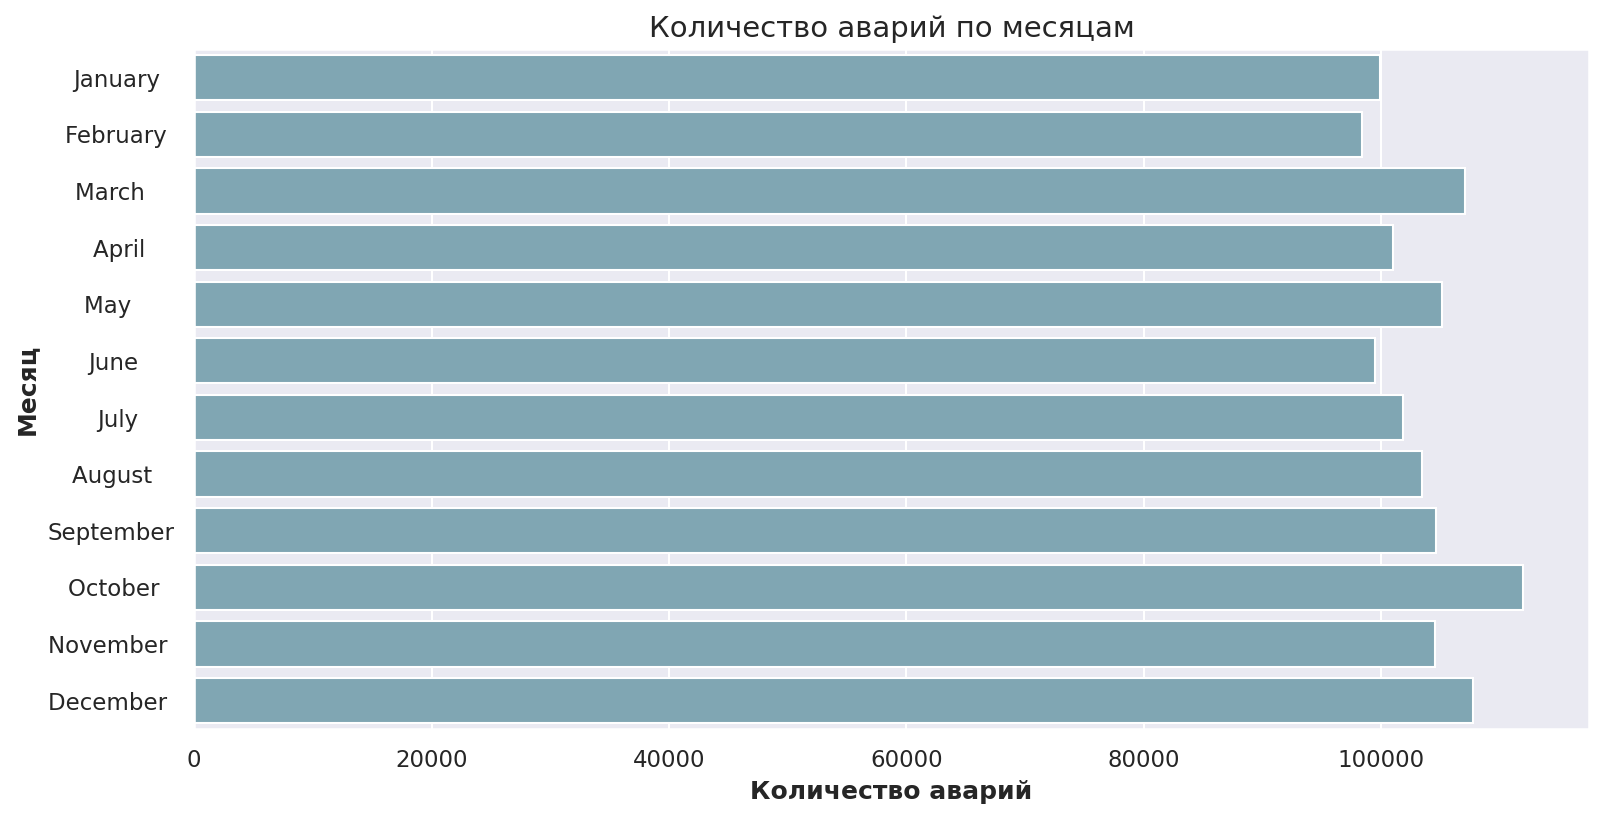

In [12]:
# sql запрос
query = '''
SELECT EXTRACT(MONTH
               FROM COLLISION_DATE)::INTEGER AS month_number,
       TO_CHAR(COLLISION_DATE, 'Month') AS MONTH,
       COUNT(*) AS collision_count
FROM collisions
WHERE EXTRACT(YEAR
              FROM COLLISION_DATE)<2012
GROUP BY MONTH,
         month_number
ORDER BY month_number;
'''

collision_per_month = pd.read_sql_query(query, con=engine)

# построение графика
plt.figure(figsize=(12, 6), dpi=PLOT_DPI)
ax = sns.barplot(data=collision_per_month, x='collision_count', y='month', orient='h', color='#77aabb')
ax.set_title('Количество аварий по месяцам', fontsize=14)
ax.set_xlabel('Количество аварий', fontweight='bold')
ax.set_ylabel('Месяц', fontweight='bold');

<font size="3">

Наибольшее количество происшествий отмечается в следующих месяцах:
    
- **март** - 107 036 ДТП;
- **декабрь** - 107 745 ДТП;
- **октябрь** - 111 933 ДТП.
    
Можно предположить, что увеличение количества ДТП в марте и октябре связано со сменой сезонов и погодных условий.  Высокое количество происшествий в декабре можеть быть связано с тем, что количество пробок в декабре обычно выше, чем в остальные месяцы года. Затруднённое движение заставляет водителей нервничать и торопиться, что приводит к опасному вождению и нарушению ПДД.
    
    
Наименьшее количество происшествий отмечается в следующих месяцах:
- **январь** - 99 880 ДТП;
- **июнь** - 99 531 ДТП;
- **февраль** - 98 373 ДТП.  
    
Снижение количества ДТП в январе и феврале может быть связано с тем, что к этому моменту все автовладельцы подготовились к зимнему сезону. Также в январские праздники снижается само количество поездок, а февраль короче остальных месяцев, что может слегка занижать итоговую статистику.
<br>Низкое количество происшествий в июне может быть следствием благоприятных дорожных условий в этом месяце.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> ДТП по месяцам исследованы.

### Аналитические задачи

<font size="3"> Перед написанием модели предсказания вероятности ДТП необходимо провести анализ имеющихся данных для выявления особенностей и взаимосвязей.
    
Для этого **сформулируем аналитические задачи**: 
   
- провести анализ зависимости вероятности возникновения ДТП от погодных условий `(weather_1, таблица collisions)`;
- провести анализ серьёзности повреждений ТС в зависимости от года выпуска автомобиля `(таблицы collisions + vehicles)`;
- провести анализ влияния возраста автомобиля на тип ДТП `(таблицы collisions + vehicles)`;
- провести анализ серьёзности повреждений ТС в зависимости от состояния дороги в момент ДТП `(collision_damage и road_surface, таблица collisions)`;
- провести анализ частоты возникновения ДТП в зависимости от времени суток и состояния дороги `(таблицы collisions + vehicles)`;
- провести анализ влияния уровня освещённости дорог на вероятность возникновения ДТП `(lighting, таблица collisions)`;
- провести анализ влияния наличия телефона (громкой связи) в автомобиле на количество ДТП `(таблицы collisions + parties)`
    
Реализуем несколько задач из списка. 

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Задачи для аналитиков сформулированы.

<font size="4">

> **Анализ серьёзности повреждений ТС в зависимости от года выпуска автомобиля**

<font size="3">
    
Изучим зависимость серьёзности повреждений ТС в ДТП и возраста авто. 
    
Для удобства поделим автомобили на группы: 
    
- возраст **менее 3 лет**: машина с небольшим пробегом;
- возраст **от 3 до 5 лет**: ТС ещё не так часто требует ремонта;
- возраст **от 5 до 10 лет**: многие детали автомобиля начинают изнашиваться;
- возраст **более 10 лет**: ТС часто требует ремонта и замены деталей, более ранние автомобили могут быть оснащены устаревшими системами безопасности. 
    
Дополнительно убедимся, что полученные результаты не смещены из-за преобладания одной из возрастных категорий ТС в выборке: для построения визуализации рассчитаем процент каждого вида повреждений в каждой категории возраста авто.

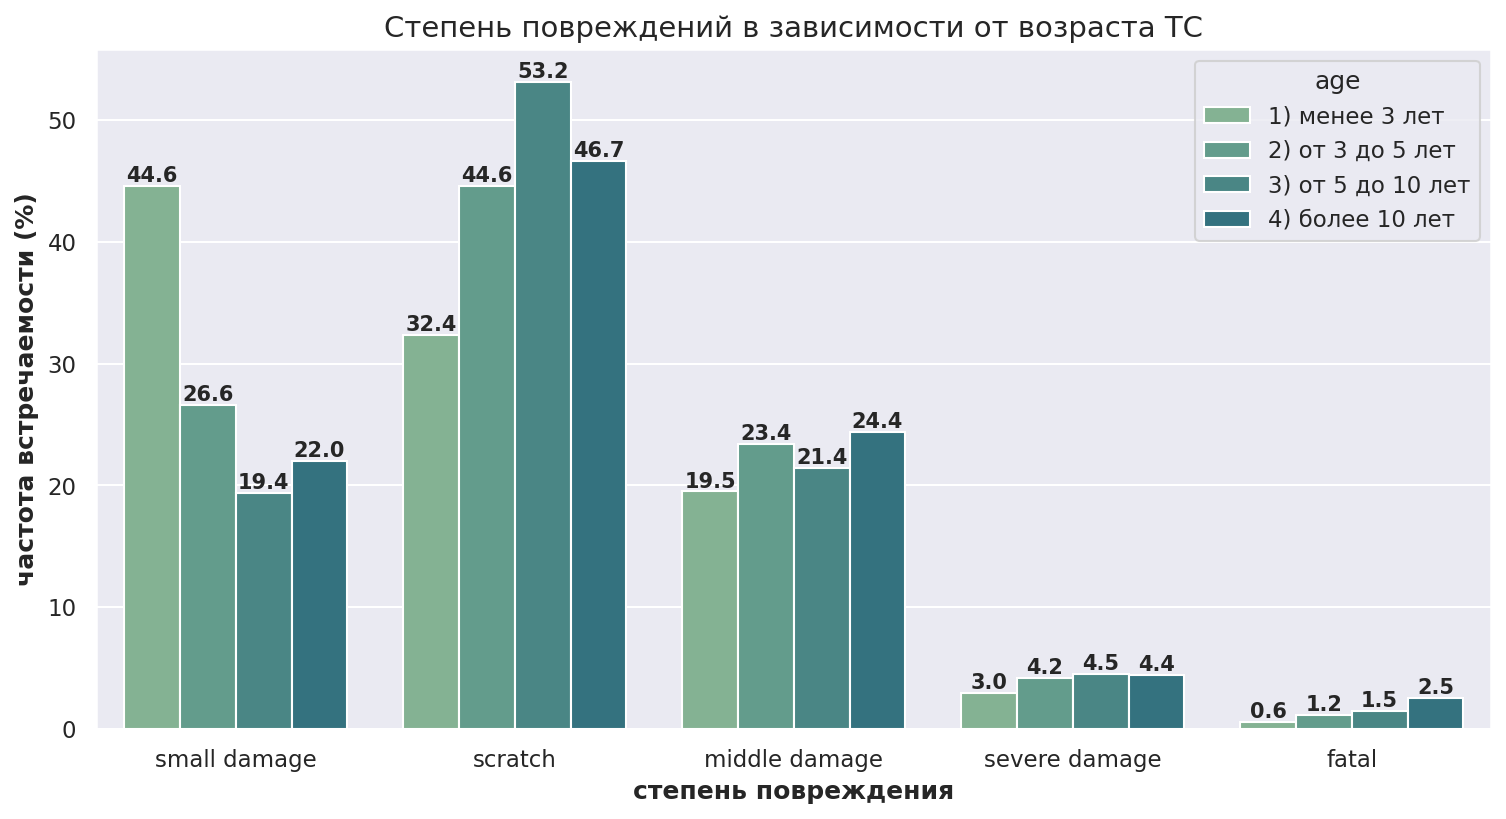

In [13]:
# sql запрос
query = '''
WITH AgeCategories AS
  (SELECT CASE
              WHEN v.vehicle_age <= 2 THEN '1) менее 3 лет'
              WHEN v.vehicle_age > 2
                   AND v.vehicle_age <= 5 THEN '2) от 3 до 5 лет'
              WHEN v.vehicle_age > 5
                   AND v.vehicle_age <= 10 THEN '3) от 5 до 10 лет'
              WHEN v.vehicle_age > 10 THEN '4) более 10 лет'
          END AS age,
          c.collision_damage
   FROM vehicles AS v
   JOIN collisions AS c ON v.case_id = c.case_id
   WHERE EXTRACT(YEAR
                 FROM COLLISION_DATE)<2012),
     TotalCounts AS
  (SELECT age,
          COUNT(*) AS total_count
   FROM AgeCategories
   GROUP BY age)
SELECT ac.age,
       ac.collision_damage,
       COUNT(*) AS damage_count,
       (COUNT(*) * 100.0 / tc.total_count) AS percentage
FROM AgeCategories ac
JOIN TotalCounts tc ON ac.age = tc.age
GROUP BY ac.age,
         ac.collision_damage,
         tc.total_count
ORDER BY ac.age,
         percentage DESC;
'''

vehicles_age = pd.read_sql_query(query, con=engine) 

# построение графика
plt.figure(figsize=(12, 6), dpi=PLOT_DPI)
ax = sns.barplot(x='collision_damage', y='percentage', hue='age', data=vehicles_age)
ax.set_title("Степень повреждений в зависимости от возраста ТС", fontsize=14)
ax.set_xlabel("степень повреждения", fontweight='bold')
ax.set_ylabel("частота встречаемости (%)", fontweight='bold')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontweight='bold', fontsize=10)

<font size="3">
    
Визуализация показывает, что независимо от возрастной категории автомобилей, самым частым типом повреждений является *scratch*, а самым редким — *fatal*.

Тип повреждения *scratch* преобладает в возрастной категории **от 5 до 10 лет**: более 53% ТС получали данное повреждение. Возможно, это связано с тем, что владельцы ТС данной категории не так сильно берегут свой автомобиль, как, например, водители категории “менее 3 лет” .


Тип повреждения *small damage* преобладает в категории **менее 3 лет** (более 44%), что может быть связано с тем, что владельцы новых авто чаще страхуются от ДТП, поэтому более склонны заявить о повреждениях, даже если они незначительны.
    
Тип повреждения *middle damage* представлен во всех категориях практически равномерно: 19% случаев ДТП со средним ущербом в категории **менее 3 лет** против 23% в категории **более 10 лет**. Нельзя сказать, что возраст авто влияет на частоту ДТП со средним ущербом.
    
    
Типы повреждения *severe damage* и *fatal* составляют довольно низкий процент ДТП во всех возрастных группах. Можно отметить, что категория **менее 3 лет** реже попадает в происшествия с серьёзным ущербом, а категория **более 10 лет** заметно лидирует в ДТП с тотальный ущербом, что может быть связано с износом деталей, отсутствием должно обслуживания авто и устаревшими системами безопасности в более ранних автомобилях.
    
Расшифровка обозначений:
    
    
|     |
| --- |
| 1 — FATAL ТС (Не подлежит восстановлению) |
|     |
| 2 — SEVERE DAMAGE (Серьёзный ремонт, большая часть под замену/Серьёзное повреждение капитального строения) |
|     |
| 3 — MIDDLE DAMAGE (Средний ремонт, машина в целом на ходу/Строение в целом устояло) |
|     |
| 4 — SMALL DAMAGE (Отдельный элемент кузова под замену/покраску) |
|     |
| 0 – SCRATCH (Царапина) |

<font size="4">

> **Анализ влияния возраста автомобиля на тип ДТП**

<font size="3">
    
Выясним, влияет ли возраст автомобиля на тип ДТП. 
    
Для удобства поделим автомобили на возрастные группы аналогичным образом и убедимся, что полученные результаты не смещены из-за преобладания одной из категорий ТС в выборке.

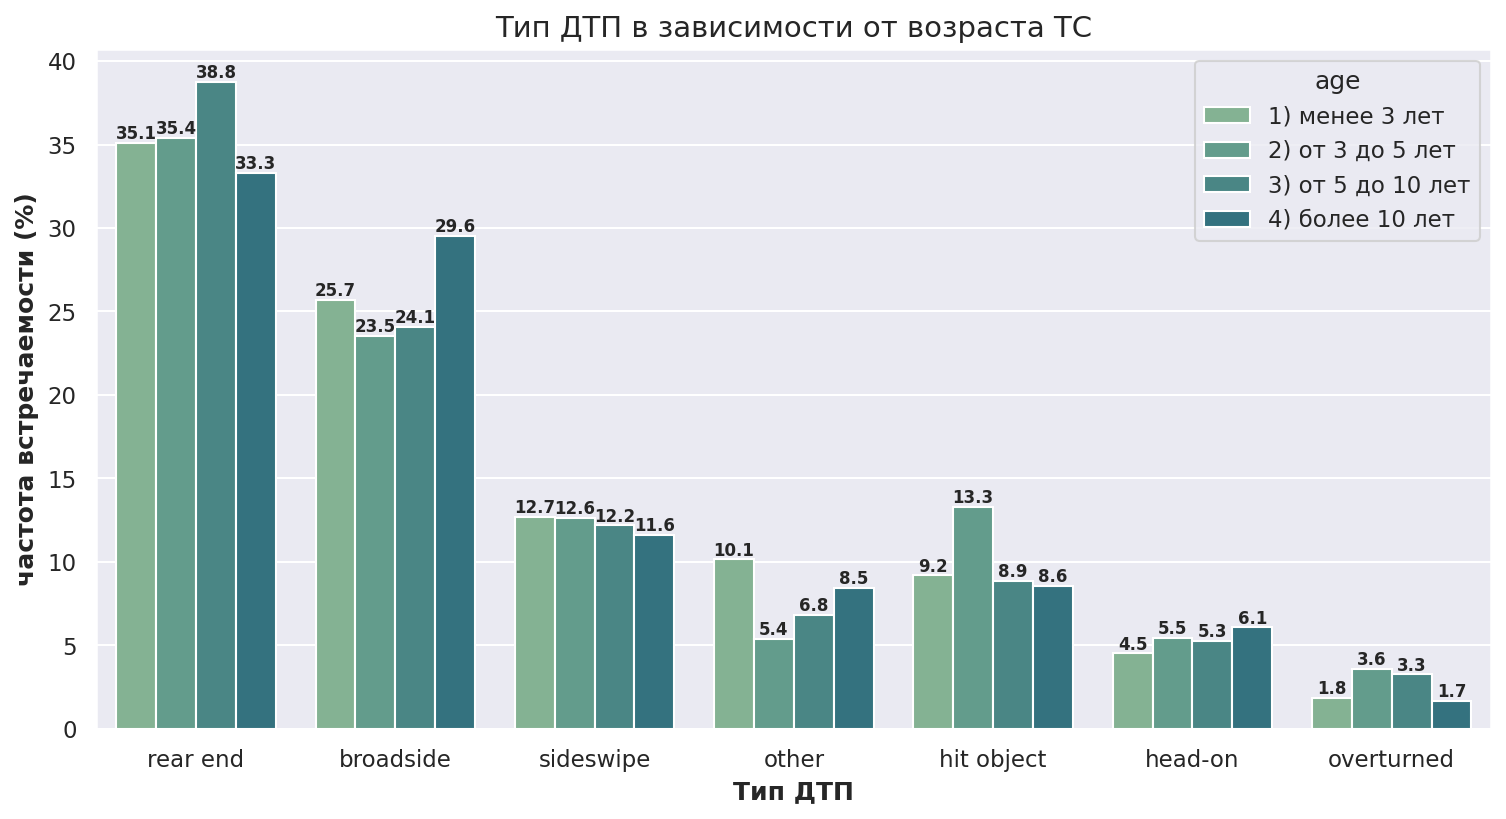

In [14]:
# sql запрос
query = '''
WITH AgeCategories AS
  (SELECT CASE
              WHEN v.vehicle_age <= 2 THEN '1) менее 3 лет'
              WHEN v.vehicle_age > 2
                   AND v.vehicle_age <= 5 THEN '2) от 3 до 5 лет'
              WHEN v.vehicle_age > 5
                   AND v.vehicle_age <= 10 THEN '3) от 5 до 10 лет'
              WHEN v.vehicle_age > 10 THEN '4) более 10 лет'
          END AS age,
          c.type_of_collision
   FROM vehicles AS v
   JOIN collisions AS c ON v.case_id = c.case_id
   WHERE EXTRACT(YEAR
                 FROM COLLISION_DATE)<2012),
     TotalCounts AS
  (SELECT age,
          COUNT(*) AS total_count
   FROM AgeCategories
   GROUP BY age)
SELECT ac.age,
       ac.type_of_collision,
       COUNT(*) AS type_count,
       (COUNT(*) * 100.0 / tc.total_count) AS percentage
FROM AgeCategories ac
JOIN TotalCounts tc ON ac.age = tc.age
GROUP BY ac.age,
         ac.type_of_collision,
         tc.total_count
ORDER BY ac.age,
         percentage DESC;
'''

collision_type = pd.read_sql_query(query, con=engine)

# построение графика
plt.figure(figsize=(12, 6), dpi=PLOT_DPI)
ax = sns.barplot(x='type_of_collision', y='percentage', hue='age', data=collision_type)
ax.set_title("Тип ДТП в зависимости от возраста ТС", fontsize=14)
ax.set_xlabel("Тип ДТП", fontweight='bold')
ax.set_ylabel("частота встречаемости (%)", fontweight='bold')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=8, fontweight='bold')

<font size="3">

Визуализация показывает, что независимо от возрастной категории автомобилей, самым распространённым типом ДТП является *Rear End и Broadside*, а самым редким — *Overturned*.
    
Можно отметить, что доля видов ДТП остаётся относительно стабильной во всех возрастных группах и нельзя заключить, что между двумя признаками есть определённая заметная зависимость.


Расшифровка обозначений:

|     |
| --- |
| A — Head-On (Лоб в лоб) |
|     |
| B — Sideswipe (Сторона) |
|     |
| C — Rear End (Столкновение задней частью) |
|     |
| D — Broadside (Боковой удар) |
|     |
| E — Hit Object (Удар объекта) |
|     |
| F — Overturned (Опрокинутый) |
|     |
| H — Other (Другое) |

<font size="4">

> **Анализ частоты возникновения ДТП в зависимости от времени суток и состояния дороги**

<font size="3">
    
Выясним, влияет ли состояние дороги и время суток на частоту возникновения ДТП. 
    
Для удобства поделим сутки на 4 промежутка: 
- утро: **7:00 - 13:00**; 
- день: **13:00 - 19:00**;
- вечер: **19:00 - 00:00**;
- ночь: **00:00 - 07:00**
    
Для каждого состояния дороги посчитаем количество происшествий для всех временных промежутков и построим визуализацию.

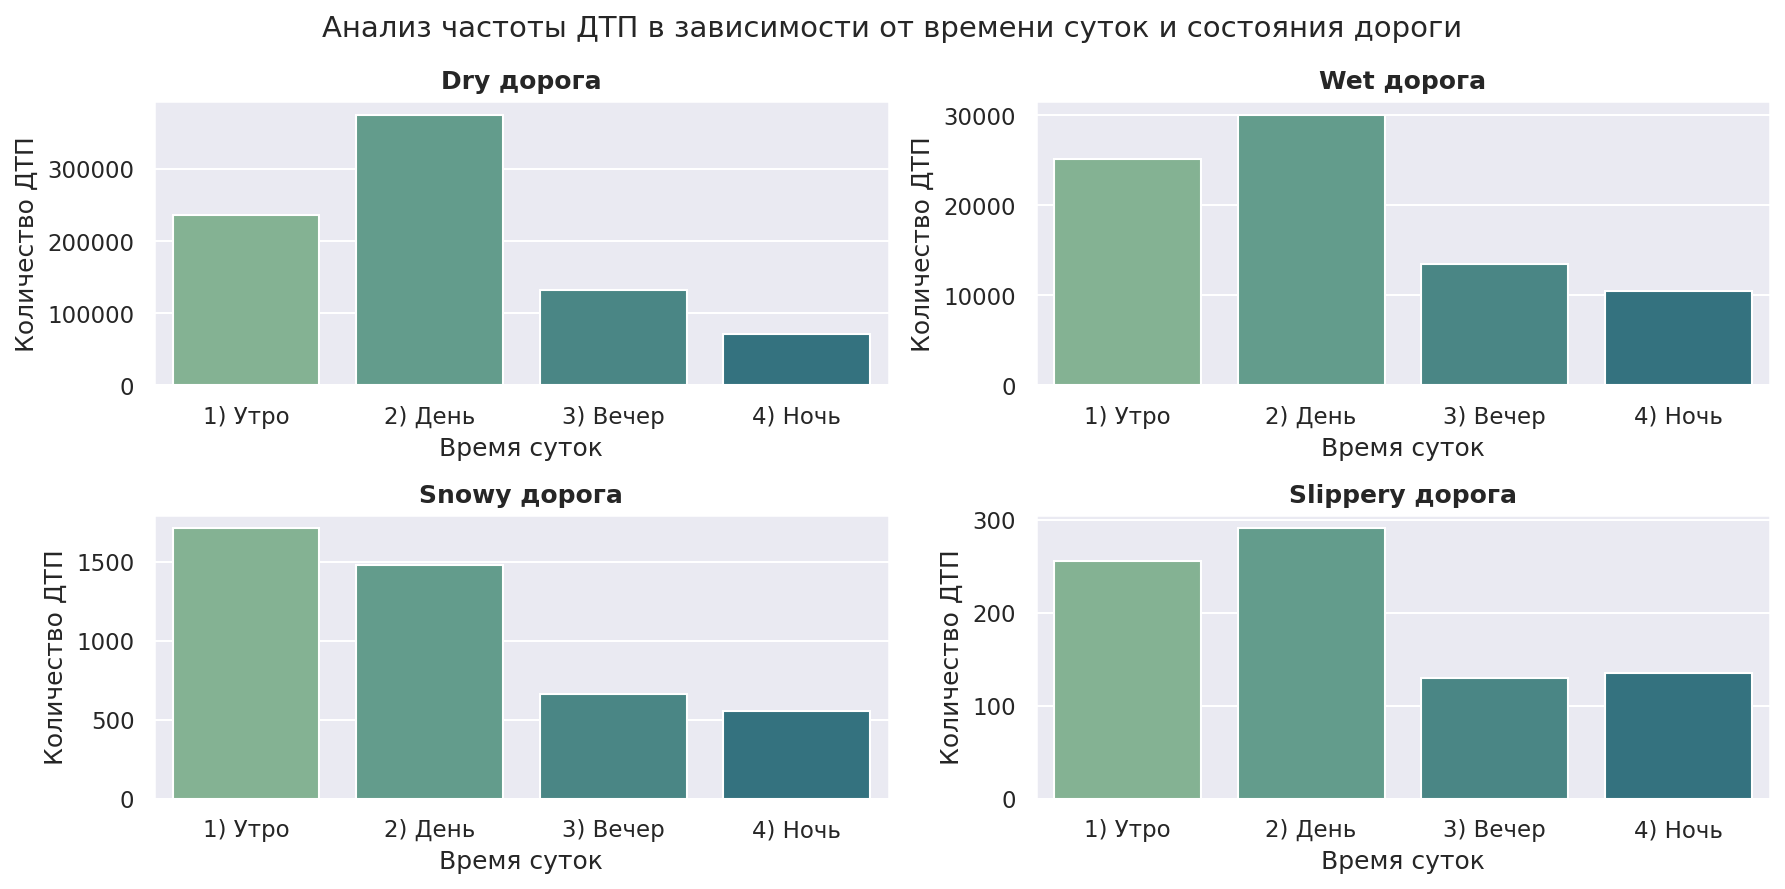

In [15]:
# sql запрос
query = '''
SELECT CASE
           WHEN EXTRACT(HOUR
                        FROM collision_time) >= 7
                AND EXTRACT(HOUR
                            FROM collision_time) < 13 THEN '1) Утро'
           WHEN EXTRACT(HOUR
                        FROM collision_time) >= 13
                AND EXTRACT(HOUR
                            FROM collision_time) < 19 THEN '2) День'
           WHEN EXTRACT(HOUR
                        FROM collision_time) >= 19
                AND EXTRACT(HOUR
                            FROM collision_time) < 24 THEN '3) Вечер'
           WHEN EXTRACT(HOUR
                        FROM collision_time) >= 0
                AND EXTRACT(HOUR
                            FROM collision_time) < 7 THEN '4) Ночь'
       END AS time_of_day,
       road_surface,
       COUNT(*) AS collision_count
FROM collisions c
JOIN vehicles v ON c.case_id = v.case_id
WHERE road_surface IS NOT NULL
  AND collision_time IS NOT NULL
  AND EXTRACT(YEAR
              FROM COLLISION_DATE)<2012
GROUP BY time_of_day,
         road_surface
ORDER BY time_of_day,
         collision_count DESC;
'''

day_road = pd.read_sql_query(query, con=engine)

# построение графика
fig, axes = plt.subplots(2, 2, figsize=(12, 6), dpi=PLOT_DPI)
fig.suptitle('Анализ частоты ДТП в зависимости от времени суток и состояния дороги', fontsize=14)

road_surfaces = ['dry', 'wet', 'snowy', 'slippery']

for i, road_surface in enumerate(road_surfaces):
    row, col = i // 2, i % 2
    sns.barplot(x='time_of_day',
                y='collision_count',
                data=day_road[day_road['road_surface'] == road_surface],
                ax=axes[row, col])
    axes[row, col].set_title(f'{road_surface.capitalize()} дорога', fontweight='bold')
    axes[row, col].set_xlabel('Время суток')
    axes[row, col].set_ylabel('Количество ДТП')

plt.tight_layout()

<font size="3">
    
Визуализация показывает, что независимо от времени суток, наибольшее количество ДТП происходит на сухой дороге. Это может быть связано с тем, что сухих дней в году больше, чем дождливых или снежных. В сухую погоду на дорогах может быть больше транспорта, водители движутся быстрее, чем при худших погодных условиях. При этом, на сухой дороге могут встречаться неровности, ямы или плохое покрытие, что также может привести к ДТП.

Условия вождения на мокрой или заснеженной дороге заставляют водителей ездить более осторожно и уменьшать скорость, а многие предпочитают не пользоваться личным ТС в такую погоду.

На **сухой дороге** большинство аварий происходит днём, что может быть связано с увеличенным движением транспорта в этот период.
    
В случае **заснеженной и скользкой** дороги пик аварий приходится на утреннее и дневное время, вероятно по причине того, что дороги ещё не успели подготовить к движению транспорта (убрать снег, посыпать скользкие участки).
    
На **мокрых дорогах** аварии происходят чаще утром и днём, что может быть связано с увеличенным движением транспорта и плохой видимостью в условиях дождя.
    
Расшифровка обозначений:

|     |
| --- |
| A — Dry (Сухая) |
|     |
| B — Wet (Мокрая) |
|     |
| C — Snowy or Icy (Заснеженная или обледенелая) |
|     |
| D — Slippery (Muddy, Oily, etc.) (Скользкая, грязная, маслянистая и т. д.) |

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

<font size="3">
    
**Вывод раздела:**
       
В данном шаге исследования выполнен статистический анализ факторов ДТП для более подробного ознакомления и понимания имеющихся данных. 
    
Удалось реализовать следующие задачи: 
- анализ серьёзности повреждений ТС в зависимости от года выпуска автомобиля;
- анализ влияния возраста автомобиля на тип ДТП;
- анализ частоты возникновения ДТП в зависимости от времени суток и состояния дороги
    
Полученные результаты будут полезны в дальнейшем исследовании и разработке модели.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Часть задач исследована, отлично!

## Отбор данных к построению модели

<font size="3">
    
При формировании набора данных учтём пожелания заказчика: 
    
- отберём случаи, где виновником происшествия является автомобиль; 
- выберем случаи, когда ДТП привело к любым значимым повреждениям автомобиля любого из участников;
- для моделирования ограничимся данными только за 2012 год.

In [16]:
# sql запрос
query = '''
SELECT *
FROM parties AS p
INNER JOIN vehicles AS v ON p.case_id = v.case_id
AND v.party_number = p.party_number
JOIN collisions AS col ON p.case_id = col.case_id
WHERE p.party_type = 'car'
  AND p.case_id IN
    (SELECT case_id
     FROM collisions
     WHERE collision_damage != 'scratch'
       AND collision_date BETWEEN '2012-01-01' AND '2012-12-31');
'''

collisions = pd.read_sql_query(query, con=engine)

# проверим результат
display(collisions.head())

,id,case_id,party_number,party_type,at_fault,insurance_premium,party_sobriety,party_drug_physical,cellphone_in_use,id,case_id,party_number,vehicle_type,vehicle_transmission,vehicle_age,case_id,county_city_location,county_location,distance,direction,intersection,weather_1,location_type,collision_damage,party_count,primary_collision_factor,pcf_violation_category,type_of_collision,motor_vehicle_involved_with,road_surface,road_condition_1,lighting,control_device,collision_date,collision_time
0,2405070,5454084,1,car,1,29.000,None,None,0.000,1325810,5454084,1,sedan,manual,5.000,5454084,0105,alameda,500.000,south,0.000,cloudy,highway,small damage,2,vehicle code violation,unsafe lane change,sideswipe,other motor vehicle,dry,normal,daylight,none,2012-02-08,08:20:00
1,2312509,5403029,1,car,1,25.000,impairment unknown,G,NaN,1274766,5403029,1,coupe,auto,4.000,5403029,4313,santa clara,0.000,None,1.000,fog,None,fatal,3,vehicle code violation,automobile right of way,broadside,other motor vehicle,wet,normal,daylight,None,2012-01-03,07:29:00
2,2312512,5403030,1,car,1,52.000,had not been drinking,sleepy/fatigued,0.000,1274767,5403030,1,sedan,auto,7.000,5403030,1942,los angeles,72.000,west,0.000,clear,None,fatal,3,other improper driving,other improper driving,rear end,None,dry,normal,dusk or dawn,functioning,2012-01-19,05:45:00
3,2312515,5403031,1,car,1,21.000,"had been drinking, under influence",None,0.000,1274768,5403031,1,sedan,manual,3.000,5403031,1500,kern,550.000,east,0.000,clear,highway,fatal,1,vehicle code violation,dui,hit object,fixed object,dry,normal,dusk or dawn,none,2012-01-13,06:05:00
4,2312518,5403033,1,car,1,63.000,had not been drinking,None,0.000,1274771,5403033,1,coupe,manual,10.000,5403033,3711,san diego,444.000,north,0.000,clear,None,fatal,1,vehicle code violation,improper turning,hit object,fixed object,dry,normal,dark with no street lights,none,2012-01-01,19:32:00


<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Запрос к базе данных сформулирован верно.

<font size="3">
    
Данные успешно выгружены.
    
Определим признаки, которые попадут в финальную выборку: важно понимать, какие признаки могут быть использованы до начала поездки.
    
Необходимо создать систему, которая могла бы оценить риск ДТП по выбранному маршруту движения. Как только водитель забронировал автомобиль, сел за руль и выбрал маршрут, система должна оценить уровень риска. 
    
Рассмотрим каждый из имеющихся признаков и определим, являются ли они воспроизводимыми:

<font size="3">
    
1. **insurance_premium** — сумма страховки (тыс. $): **Не воспроизводимый** признак зависит от множества факторов и не может быть известен заранее.
2. **party_sobriety** — трезвость участника: **Не воспроизводимый** - состояние водителя на момент поездки, и его нельзя знать заранее.
3. **party_drug_physical** — состояние участника (с учётом принятых лекарств): **Не воспроизводимый** - как и в случае с трезвостью, это состояние водителя на момент поездки.
4. **cellphone_in_use** — наличие возможности разговаривать по громкой связи: **Воспроизводимый** - зависит от характеристик автомобиля.
5. **vehicle_type** — тип кузова: **Воспроизводимый** - признак известен заранее, так как он определяется выбранным автомобилем.
6. **vehicle_transmission** — тип КПП: **Воспроизводимый** - признак также известен заранее.
7. **vehicle_age** — возраст автомобиля (в годах): **Воспроизводимый** - признак известен заранее.
8. **county_location** — названия географических районов: **Воспроизводимый** - известно заранее, так как водитель выбирает маршрут.
9. **distance** — расстояние от главной дороги (метры): **Воспроизводимый** - можно рассчитать заранее на основе маршрута.
10. **intersection** — является ли место перекрёстком: **Воспроизводимый** - можно определить заранее на основе карты маршрута.
11. **weather_1** — погода: **Воспроизводимый** - прогноз погоды можно получить заранее.
12. **location_type** — тип дороги: **Воспроизводимый** - можно определить заранее на основе карты маршрута.
13. **road_surface** — состояние дороги в зависимости от погоды: **Воспроизводимый** - можно оценить заранее, основываясь на погодных условиях и информации о дороге.
14. **road_condition_1** — состояние дороги и дорожного покрытия: **Воспроизводимый** - можно оценить заранее, основываясь на данных о состоянии дорог.
15. **lighting** — освещение: **Воспроизводимый** - можно определить заранее, основываясь на времени суток.
16. **control_device** — работоспособность устройств управления: **Не воспроизводимый** - состояние автомобиля на момент поездки.
17. **collision_date** — дата происшествия: **Не воспроизводимый** - относится к прошлым событиям и не может быть известен заранее.
18. **collision_time** — время происшествия: **Не воспроизводимый** - также относится к прошлым событиям.

---

Из перечисленных признаков, **воспроизводимыми** являются:
- `vehicle_type`
- `vehicle_transmission`
- `vehicle_age`
- `county_location`
- `distance`
- `intersection`
- `weather_1`
- `location_type`
- `road_surface`
- `road_condition_1`
- `lighting`
- `cellphone_in_use`
- `collision_date` - в виде времени года;
- `collision_time` - в виде времени суток.


**Не воспроизводимыми** являются:
- `insurance_premium`
- `party_sobriety`
- `party_drug_physical`
- `control_device`

In [17]:
# удалим неинформативные признаки
collisions.drop(
    [
        "id",
        "case_id",
        "party_number",
        "party_type",
        "county_city_location",
        "direction",
        "collision_damage",
        "party_count",
        "primary_collision_factor",
        "pcf_violation_category",
        "type_of_collision",
        "motor_vehicle_involved_with",
        "insurance_premium",
        "party_sobriety",
        "party_drug_physical",
        "control_device"
    ],
    axis=1,
    inplace=True,
)

# проверим результат
collisions.head()

,at_fault,cellphone_in_use,vehicle_type,vehicle_transmission,vehicle_age,county_location,distance,intersection,weather_1,location_type,road_surface,road_condition_1,lighting,collision_date,collision_time
0,1,0.000,sedan,manual,5.000,alameda,500.000,0.000,cloudy,highway,dry,normal,daylight,2012-02-08,08:20:00
1,1,NaN,coupe,auto,4.000,santa clara,0.000,1.000,fog,None,wet,normal,daylight,2012-01-03,07:29:00
2,1,0.000,sedan,auto,7.000,los angeles,72.000,0.000,clear,None,dry,normal,dusk or dawn,2012-01-19,05:45:00
3,1,0.000,sedan,manual,3.000,kern,550.000,0.000,clear,highway,dry,normal,dusk or dawn,2012-01-13,06:05:00
4,1,0.000,coupe,manual,10.000,san diego,444.000,0.000,clear,None,dry,normal,dark with no street lights,2012-01-01,19:32:00


<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Молодец, что подробно описываешь логику отбора признаков.

<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

    
<b>На доработку❌:</b> Не забывай, что для моделирования можно использовать только воспроизводимые признаки, то есть только те, которые мы знаем или можем знать до начала поездки. Все ли признаки отвечают этому требованию?

<div class="alert alert-info">
<h2> Комментарий студента <a class="tocSkip"> </h2>

Однозначно до начала поездки мы знаем только характеристики автомобиля, но теоретически можем получить данные о состоянии водителя и особенностях дороги (алкотестер + ввод маршрута). 
    
Точно нельзя заранее назвать дату и время аварии, но я их использую в виде времени года и времени суток, скорее как поправку на периоды повышенной опасности по историческим данным. 
</div>

<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера v.2 <a class="tocSkip"></h2>

    
<b>На доработку❌:</b> А как тогда начнётся поездка, если мы уже до старта будем знать, что человек пьян или под наркотиками - осознанно будем провоцировать ДТП?:) 
    
Также у нас есть `insurance_premium` - эта сумма становится известна после ДТП, до ДТП узнать нет возможности.

<div class="alert alert-info">
<h2> Комментарий студента <a class="tocSkip"> </h2>

Пересмотрела признаки, оставила воспроизводимые
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера v.3 <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Учтено.

<font size="3">

Для дальнейшего исследования отобраны только информативные признаки.

### Изучение данных

<font size="3"> Изучим структуру и полноту полученных данных.

In [18]:
collisions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56248 entries, 0 to 56247
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   at_fault              56248 non-null  int64  
 1   cellphone_in_use      51777 non-null  float64
 2   vehicle_type          56248 non-null  object 
 3   vehicle_transmission  55389 non-null  object 
 4   vehicle_age           54554 non-null  float64
 5   county_location       56248 non-null  object 
 6   distance              56248 non-null  float64
 7   intersection          56073 non-null  float64
 8   weather_1             56080 non-null  object 
 9   location_type         25932 non-null  object 
 10  road_surface          55900 non-null  object 
 11  road_condition_1      55999 non-null  object 
 12  lighting              56094 non-null  object 
 13  collision_date        56248 non-null  object 
 14  collision_time        56160 non-null  object 
dtypes: float64(4), int6

<Axes: >

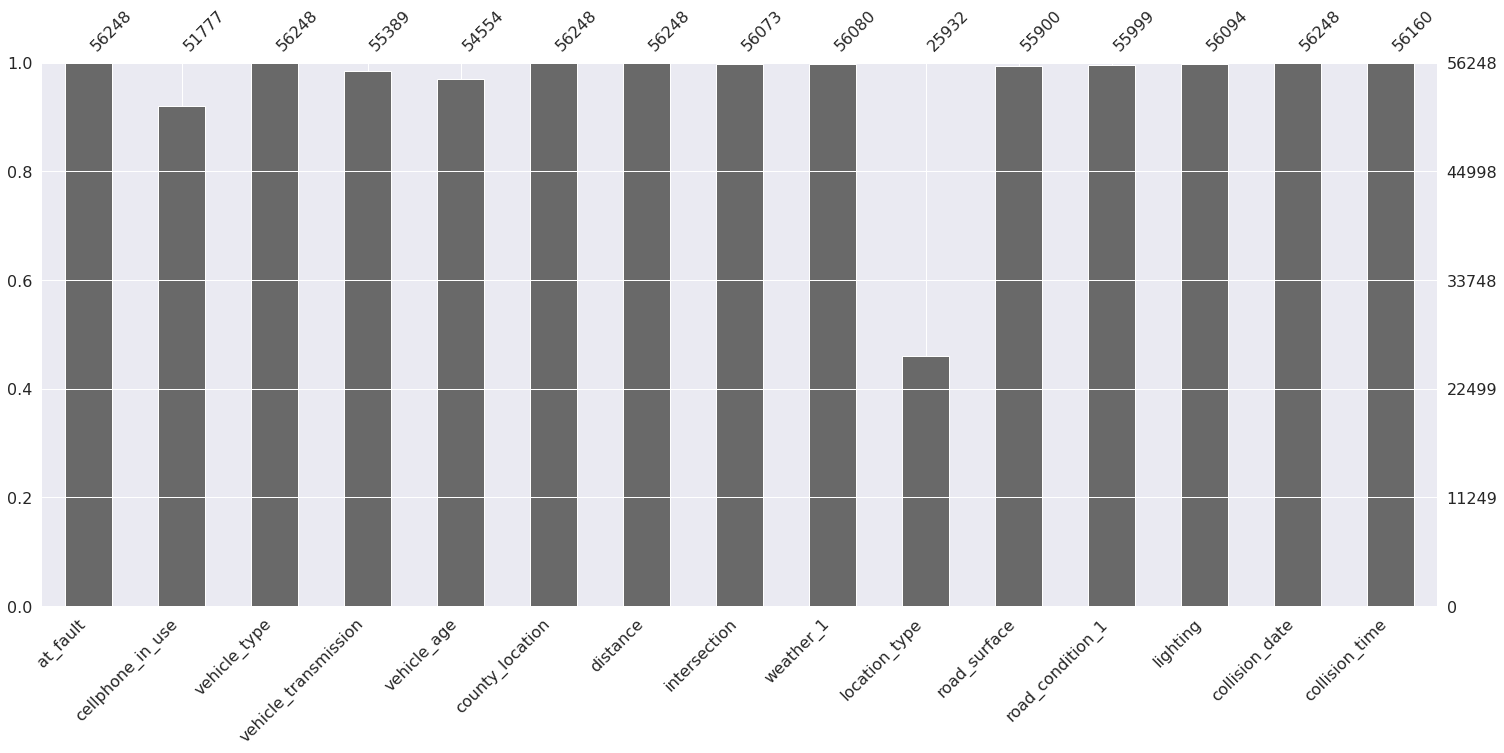

In [19]:
msno.bar(collisions)

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

<font size="3">
    
**Вывод раздела:**

Полученный датафрейм содержит следующие данные:

**Признаки**
* `cellphone_in_use` — наличие возможности разговаривать по громкой связи;
* `vehicle_type` — тип кузова;
* `vehicle_transmission` — тип КПП;
* `vehicle_age` —возраст автомобиля (в годах);
* `county_location` — названия географических районов; 
* `distance` — расстояние от главной дороги (метры);
* `intersection` — является ли место перекрёстком;
* `weather_1` — погода; 
* `location_type` — тип дороги; 
* `road_surface` — состояние дороги в зависимости от погоды; 
* `road_condition_1` — состояние дороги и дорожного покрытия; 
* `lighting` — освещение; 
* `collision_date` — дата происшествия;
* `collision_time` — время происшествия
       
⠀**Целевой признак**
* `at_fault` — виновность участника.


Предварительно можно утверждать, что данных достаточно для проведения исследования. 

##  Предобработка данных

<font size="3"> Проведём предобработку данных.

### Именование столбцов


<font size="3"> Приведём названия столбцов датафрейма к PEP8.

In [20]:
collisions.columns = collisions.columns.str.replace(r'_1$', '', regex=True)

#проверим результат
collisions.columns

Index(['at_fault', 'cellphone_in_use', 'vehicle_type', 'vehicle_transmission',
       'vehicle_age', 'county_location', 'distance', 'intersection', 'weather',
       'location_type', 'road_surface', 'road_condition', 'lighting',
       'collision_date', 'collision_time'],
      dtype='object')

<font size="3"> Столбцы датафрейма именованы корректно.

### Проверка пропусков


<font size="3"> Гистограммы `msno` показали наличие пропущенных значений в датафреймах, изучим их подробнее.

In [21]:
#считаем кол-во пропусков в столбце
display(collisions.isna().sum())

#считаем кол-во пропусков в процентах
for col in collisions.columns:
    pct_missing = np.mean(collisions[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

at_fault                    0
cellphone_in_use         4471
vehicle_type                0
vehicle_transmission      859
vehicle_age              1694
county_location             0
distance                    0
intersection              175
weather                   168
location_type           30316
road_surface              348
road_condition            249
lighting                  154
collision_date              0
collision_time             88
dtype: int64

at_fault - 0%
cellphone_in_use - 8%
vehicle_type - 0%
vehicle_transmission - 2%
vehicle_age - 3%
county_location - 0%
distance - 0%
intersection - 0%
weather - 0%
location_type - 54%
road_surface - 1%
road_condition - 0%
lighting - 0%
collision_date - 0%
collision_time - 0%


<font size="3">
    
Практически все столбцы имеют пропущенные значения.

Признаки в выборке имеют **более 50% пропусков**:     
- признак `location_type` на 58% состоит из пропусков - на данном этапе оставим столбец в выборке и заполним пропуски категорией-заглушкой, на этапе корреляционного анализа изучим важность признака и удалим его при необходимости.
    
**Стратегия заполнения пропусков**:
    
Количественные столбцы: 
- `vehicle_age` - пропуски нельзя восполнить достоверно на основе имеющихся данных, исключим данные объекты из выборки.

Категориальные столбцы: 
  - `cellphone_in_use`,  
  - `vehicle_transmission`, 
  - `road_surface`, 
  - `intersection`, 
  - `weather`, 
  - `road_condition`, 
  - `lighting` - заполним категорией-заглушкой `Unknown`, а для бинарных категорий - `-999`
    
Дата и время: 
- `collision_time` - данные о времени происшествия нельзя восстановить достоверно, исключим объекты с пропусками в столбце из выборки. 

In [22]:
# удалим пропуски в `vehicle_age` и `collision_date`
collisions = collisions.dropna(subset=['vehicle_age', 'collision_time']) 

<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

    
<b>На доработку❌:</b> В случае замены пропусков на расчётные величины (медиана/среднее/мода) оценку этой величины следует делать на `train` - в противном случае в оценку попадают также значения из `test` части, что является неявной утечкой данных из будущего. Соответственно пропуски заполняем после сплитования, оценивая агрегат на `train` и используя его для замены пропусков в `train` и `test`.

<div class="alert alert-info">
<h2> Комментарий студента <a class="tocSkip"> </h2>

📝 Перенесла в шаг формирования выборок и подготовки данных. 
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера v.2 <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Учтено.

In [23]:
#заполним пропуски категорией-заглушкой Unknown
cats_to_fill = [
    "vehicle_transmission",
    "road_surface",
    "location_type",
    "weather",
    "road_condition",
    "lighting",
]

collisions[cats_to_fill] = collisions[cats_to_fill].apply(lambda x: x.fillna('unknown'), axis=1)


#заполним пропуски категорией-заглушкой -999
bin_to_fill = [
    "cellphone_in_use",
    "intersection"
]

collisions[bin_to_fill] = collisions[bin_to_fill].apply(lambda x: x.fillna(-999), axis=1)

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍</b> 
    
Отличное решение по обработке пропусков в категориальных признаках заглушкой - это позволит как сохранить наблюдения вместо их удаления, так и избавит нас от возможных ошибок при эмпирическом импутировании.

In [24]:
# проверим результат
collisions.isna().sum()

at_fault                0
cellphone_in_use        0
vehicle_type            0
vehicle_transmission    0
vehicle_age             0
county_location         0
distance                0
intersection            0
weather                 0
location_type           0
road_surface            0
road_condition          0
lighting                0
collision_date          0
collision_time          0
dtype: int64

<font size="3">
    
Основные пропущенные значения обработаны, определён алгоритм обработки оставшихся пропусков.

### Тип данных


<font size="3"> Проверим тип данных в столбцах.

In [25]:
collisions.dtypes

at_fault                  int64
cellphone_in_use        float64
vehicle_type             object
vehicle_transmission     object
vehicle_age             float64
county_location          object
distance                float64
intersection            float64
weather                  object
location_type            object
road_surface             object
road_condition           object
lighting                 object
collision_date           object
collision_time           object
dtype: object

<font size="3">

**Признаки**
* `cellphone_in_use` — категориальный бинарный признак;
* `vehicle_type` — категориальный строковый признак;
* `vehicle_transmission` — категориальный бинарный признак;
* `vehicle_age` — числовой дискретный признак;
* `county_location` — категориальный строковый признак; 
* `distance` — числовой дискретный признак;
* `intersection` — категориальный бинарный признак;
* `weather_1` — категориальный строковый признак; 
* `location_type` — категориальный строковый признак; 
* `road_surface` — категориальный строковый признак; 
* `road_condition_1` — категориальный строковый признак; 
* `lighting` — категориальный строковый признак; 
* `collision_date` — дата происшествия;
* `collision_time` — время происшествия
       
⠀**Таргет**
* `at_fault` — категориальный бинарный признак.

Извлечём месяц из `collision_date` для привязки к сезону и час из `collision_time` для привязки к времени суток.

In [26]:
# преобразуем 'collision_date' в формат datetime
collisions['collision_date'] = pd.to_datetime(collisions['collision_date'])

# извлечём месяц
collisions['collision_month'] = collisions['collision_date'].dt.month

# удалим полную дату
del collisions['collision_date']

In [27]:
# преобразуем 'collision_time' в формат datetime
collisions['collision_time'] = pd.to_datetime(collisions['collision_time'], format='%H:%M:%S').dt.time

# извлечём часа
collisions['collision_hour'] = collisions['collision_time'].apply(lambda x: int(x.hour))

# удалим полное время
del collisions['collision_time']

In [28]:
# проверим результат
collisions.head()

,at_fault,cellphone_in_use,vehicle_type,vehicle_transmission,vehicle_age,county_location,distance,intersection,weather,location_type,road_surface,road_condition,lighting,collision_month,collision_hour
0,1,0.000,sedan,manual,5.000,alameda,500.000,0.000,cloudy,highway,dry,normal,daylight,2,8
1,1,-999.000,coupe,auto,4.000,santa clara,0.000,1.000,fog,unknown,wet,normal,daylight,1,7
2,1,0.000,sedan,auto,7.000,los angeles,72.000,0.000,clear,unknown,dry,normal,dusk or dawn,1,5
3,1,0.000,sedan,manual,3.000,kern,550.000,0.000,clear,highway,dry,normal,dusk or dawn,1,6
4,1,0.000,coupe,manual,10.000,san diego,444.000,0.000,clear,unknown,dry,normal,dark with no street lights,1,19


### Проверка явных дубликатов

<font size="3"> Проверим наличие явных дубликатов в датафрейме.

In [29]:
collisions.duplicated().sum()

705

<font size="3"> Удалим найденные строки из датафрейма, чтобы модель не переобучалась на одинаковых объектах:

In [30]:
collisions.drop_duplicates(keep="first", ignore_index=True, inplace=True)

# проверим результат
collisions.duplicated().sum()

0

<font size="3"> Явные дубликаты удалены.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍</b> Найдены и удалены неявные дубликаты.

### Проверка неявных дубликатов

<font size="3"> Проверим значения признаков на уникальность.

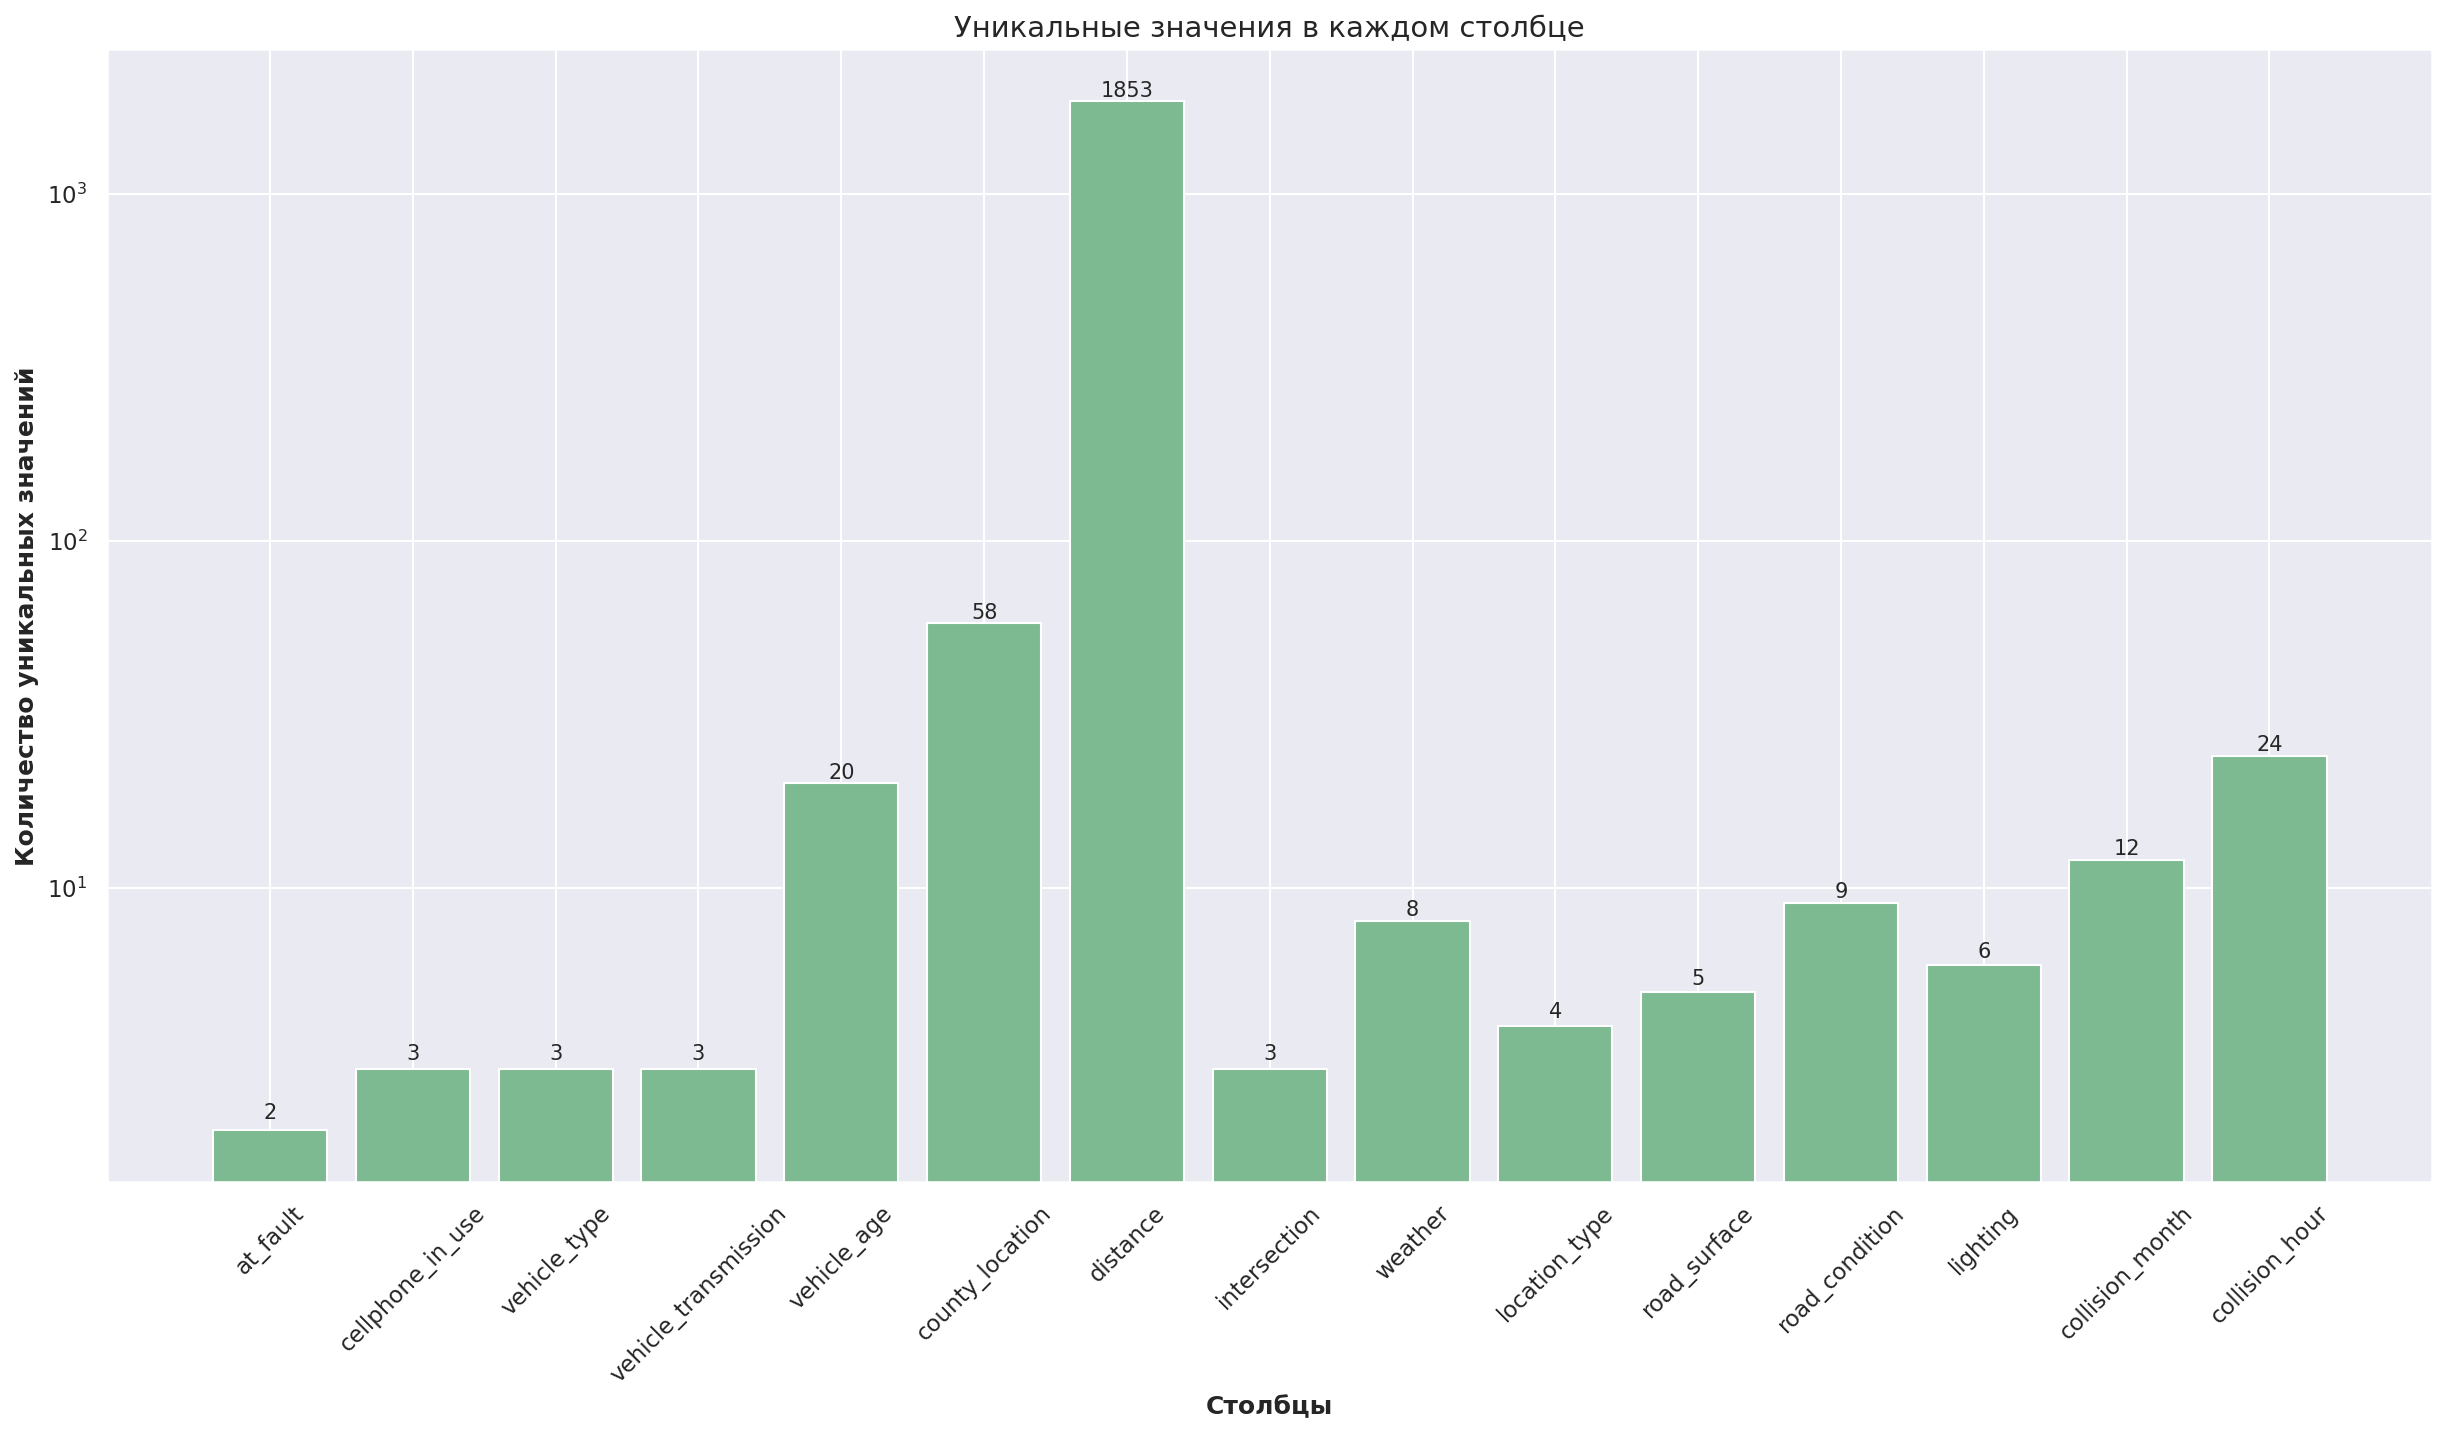

In [31]:
unique_values_count = collisions.nunique()

plt.figure(figsize=(20, 10), dpi=PLOT_DPI)
bars = plt.bar(unique_values_count.index, unique_values_count.values, log=True)
plt.xlabel('Столбцы', fontweight='bold')
plt.ylabel('Количество уникальных значений', fontweight='bold')
plt.title('Уникальные значения в каждом столбце', fontsize=14)
plt.xticks(rotation=45)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, round(yval, 2), ha='center', va='bottom')

<font size="3"> В датафрейме отсутствуют категориальные столбцы с высокой вариативностью, изучим каждый столбец подробнее.

<font size="3"> 
    
> признак **at_fault**

In [32]:
collisions['at_fault'].value_counts()

1    27253
0    26512
Name: at_fault, dtype: int64

<font size="3">  Неявные дубликаты отсутствуют.

<font size="3"> 
    
> признак **cellphone_in_use**

In [33]:
collisions['cellphone_in_use'].value_counts()

0.000       48609
-999.000     4140
1.000        1016
Name: cellphone_in_use, dtype: int64

<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

    
<b>На доработку❌:</b> Кодирование нельзя делать руками:
- при появлении новых значений категориальных признаков, не предусмотренных твоим решением, модель или упадёт, или будет генерировать ошибки;
- такое решение не сделаешь частью `Pipeline`, а все современные решения базируются на них.
    
Поэтому кодирование нужно делать только с применением обучаемых трансформеров. 
    
Понимаю, что тут обратное кодирование, но в целом для моделирования можно использовать исходные значения, как, собственно, и для анализа.

<div class="alert alert-info">
<h2> Комментарий студента <a class="tocSkip"> </h2>

📝 Убрала все подобные ручные исправления
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера v.2 <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Учтено.

<font size="3"> Неявные дубликаты отсутствуют.

<font size="3"> 
    
> признак **vehicle_type**

In [34]:
collisions['vehicle_type'].value_counts()

sedan    35028
coupe    18733
other        4
Name: vehicle_type, dtype: int64

<font size="3"> Неявные дубликаты отсутствуют.

<font size="3"> 
    
> признак **vehicle_transmission**

In [35]:
collisions['vehicle_transmission'].value_counts()

manual     28205
auto       24987
unknown      573
Name: vehicle_transmission, dtype: int64

<font size="3"> Неявные дубликаты отсутствуют.

<font size="3"> 
    
> признак **county_location**

In [36]:
collisions['county_location'].value_counts()

los angeles        15215
orange              5027
san diego           3642
san bernardino      3553
riverside           3178
sacramento          2099
alameda             1831
santa clara         1770
ventura             1428
kern                1381
fresno              1050
contra costa         950
san mateo            912
san joaquin          884
stanislaus           784
santa barbara        699
tulare               697
sonoma               676
placer               554
monterey             545
solano               535
san francisco        478
san luis obispo      428
santa cruz           422
merced               383
marin                357
madera               320
humboldt             318
butte                311
el dorado            284
shasta               272
yolo                 264
kings                244
napa                 207
imperial             204
mendocino            187
nevada               179
tehama               144
sutter               143
tuolumne             122


<font size="3"> Неявные дубликаты отсутствуют.

<font size="3"> 
    
> признак **intersection**

In [37]:
collisions['intersection'].value_counts()

0.000       42195
1.000       11403
-999.000      167
Name: intersection, dtype: int64

<font size="3"> Неявные дубликаты отсутствуют.

<font size="3"> 
    
> признак **weather**

In [38]:
collisions['weather'].value_counts()

clear      42990
cloudy      8136
raining     2108
fog          172
unknown      165
snowing      152
other         31
wind          11
Name: weather, dtype: int64

<font size="3"> Неявные дубликаты отсутствуют.

<font size="3"> 
    
> признак **location_type**

In [39]:
collisions['location_type'].value_counts()

unknown         28461
highway         20829
ramp             3184
intersection     1291
Name: location_type, dtype: int64

<font size="3"> Неявные дубликаты отсутствуют.

<font size="3"> 
    
> признак **road_surface**

In [40]:
collisions['road_surface'].value_counts()

dry         47951
wet          5097
snowy         348
unknown       327
slippery       42
Name: road_surface, dtype: int64

<font size="3"> Неявные дубликаты отсутствуют.

<font size="3"> 
    
> признак **road_condition**

In [41]:
collisions['road_condition'].value_counts()

normal            51661
construction        978
obstruction         241
unknown             235
other               219
holes               213
loose material      124
reduced width        64
flooded              30
Name: road_condition, dtype: int64

<font size="3"> Неявные дубликаты отсутствуют.

<font size="3"> 
    
> признак **lighting**

In [42]:
collisions['lighting'].value_counts()

daylight                                   36353
dark with street lights                    10439
dark with no street lights                  4987
dusk or dawn                                1706
unknown                                      149
dark with street lights not functioning      131
Name: lighting, dtype: int64

<font size="3"> Объединим категории по смыслу: 
    
- **освещено**: в эту категорию входят `daylight` и `dark with street lights`, так как в обоих случаях дорога освещена;
- **не освещено**: сюда войдут `dark with no street lights`, `dusk or dawn`, `dark with street lights not functioning`, так как дорога либо вообще не освещена, либо освещение не работает. В случае “dusk or dawn” нет достаточного естественного освещения, а уличное освещение ещё не работает или уже выключено;
- **неизвестно**: категория `unknown` для пропущенных значений.
    
    
    
    
 | Категория | Описание |
|---|---|
| Освещено | daylight, dark with street lights |
| Не освещено | dark with no street lights, dusk or dawn, dark with street lights not functioning |
| Неизвестно | unknown |  

In [43]:
collisions["lighting"] = (
    collisions["lighting"]
    .replace(
        ["daylight", "dark with street lights"],
        "освещено",
    )
    .replace(
        [
            "dark with no street lights",
            "dusk or dawn",
            "dark with street lights not functioning",
        ],
        "не освещено",
    )
    .replace(
        ["unknown"],
        "неизвестно",
    )
)


#проверим результат
collisions['lighting'].value_counts()

освещено       46792
не освещено     6824
неизвестно       149
Name: lighting, dtype: int64

<font size="3"> Количество уникальных категорий уменьшилось, неявные дубликаты обработаны.

<font size="3"> 
    
> признак **collision_month**

In [44]:
collisions['collision_month'].value_counts()

3     11023
4     10433
1     10279
2      9825
5      9238
6      1260
8       363
9       324
7       318
11      259
10      257
12      186
Name: collision_month, dtype: int64

<font size="3"> Объединим месяцы происшествия в 4 сезона: зима, весна, лето и осень.

In [45]:
# функция для определения категории времени года
def get_season(month):
    if month in [12, 1, 2]:
        return 'зима'
    elif month in [3, 4, 5]:
        return 'весна'
    elif month in [6, 7, 8]:
        return 'лето'
    else:
        return 'осень'

# преобразуем месяцы в сезоны
collisions['collision_month'] = collisions['collision_month'].apply(get_season)
# проверим результат
collisions['collision_month'].value_counts()

весна    30694
зима     20290
лето      1941
осень      840
Name: collision_month, dtype: int64

<font size="3"> Количество уникальных категорий уменьшилось, неявные дубликаты отсутствуют.

<font size="3"> 
    
> признак **collision_hour**

In [46]:
collisions['collision_hour'].value_counts()

15    4629
17    4055
16    3970
14    3893
18    3546
13    3404
12    3181
11    2742
7     2444
19    2437
8     2419
10    2225
20    2063
9     1952
21    1803
22    1486
23    1322
2     1133
1     1099
6     1089
0     1028
3      690
5      668
4      487
Name: collision_hour, dtype: int64

<font size="3"> Объединим часы возникновения ДТП в 4 времени суток: утро, день, вечер и ночь.

In [47]:
# функция для определения категории времени суток
def get_daytime(hour):
    if 0 <= hour < 7:
        return 'ночь'
    elif 7 <= hour < 13:
        return 'утро'
    elif 13 <= hour < 19:
        return 'день'
    else:
        return 'вечер'

# преобразуем часы 
collisions['collision_hour'] = collisions['collision_hour'].apply(get_daytime)
# проверим результат
collisions['collision_hour'].value_counts()

день     23497
утро     14963
вечер     9111
ночь      6194
Name: collision_hour, dtype: int64

<font size="3"> Количество уникальных категорий уменьшилось, неявные дубликаты отсутствуют.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

<font size="3">
    
**Вывод раздела:**

Для корректного проведения исследования выполнена предобработка данных:

- Отобраны информативные признаки;
- Столбцы именованы корректно;
- Проверены типы данных;
- Изучены и обработаны пропуски в датафреймах;
- Проверены и обработаны дубликаты в датафреймах, в том числе и неявные.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Предобработка выполнена - здорово, что также создаёшь новые признаки.

## Исследовательский анализ данных

<font size="3"> Проведём исследовательский анализ всех признаков датафрейма.

### Количественные признаки

<font size="3"> Напишем функцию `visuals`, которая построит гистограмму распределения, коробчатую диаграмму и выведет метод `describe()`:

In [48]:
def visuals(df, cat):
    display(df[cat].describe())
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6), dpi=PLOT_DPI)
    
    df[cat].plot(kind='hist', bins=20, ax=axes[0])
    axes[0].set_title('Гистограмма распределения', fontsize=14)
    axes[0].set_ylabel('Частота встречаемости', fontweight='bold')
    axes[0].set_xlabel('Наблюдаемые значения', fontweight='bold')
    
    df[cat].plot(kind='box', ax=axes[1], rot=0)
    axes[1].set_title('Разброс значений признаков', fontsize=14)
    axes[1].set_xlabel('Категория', fontweight='bold')
    axes[1].set_ylabel('Наблюдаемые значения', fontweight='bold')

<font size="3"> 
    
> признак **vehicle_age**

count   53,765.000
mean         4.866
std          3.241
min          0.000
25%          3.000
50%          4.000
75%          7.000
max        161.000
Name: vehicle_age, dtype: float64

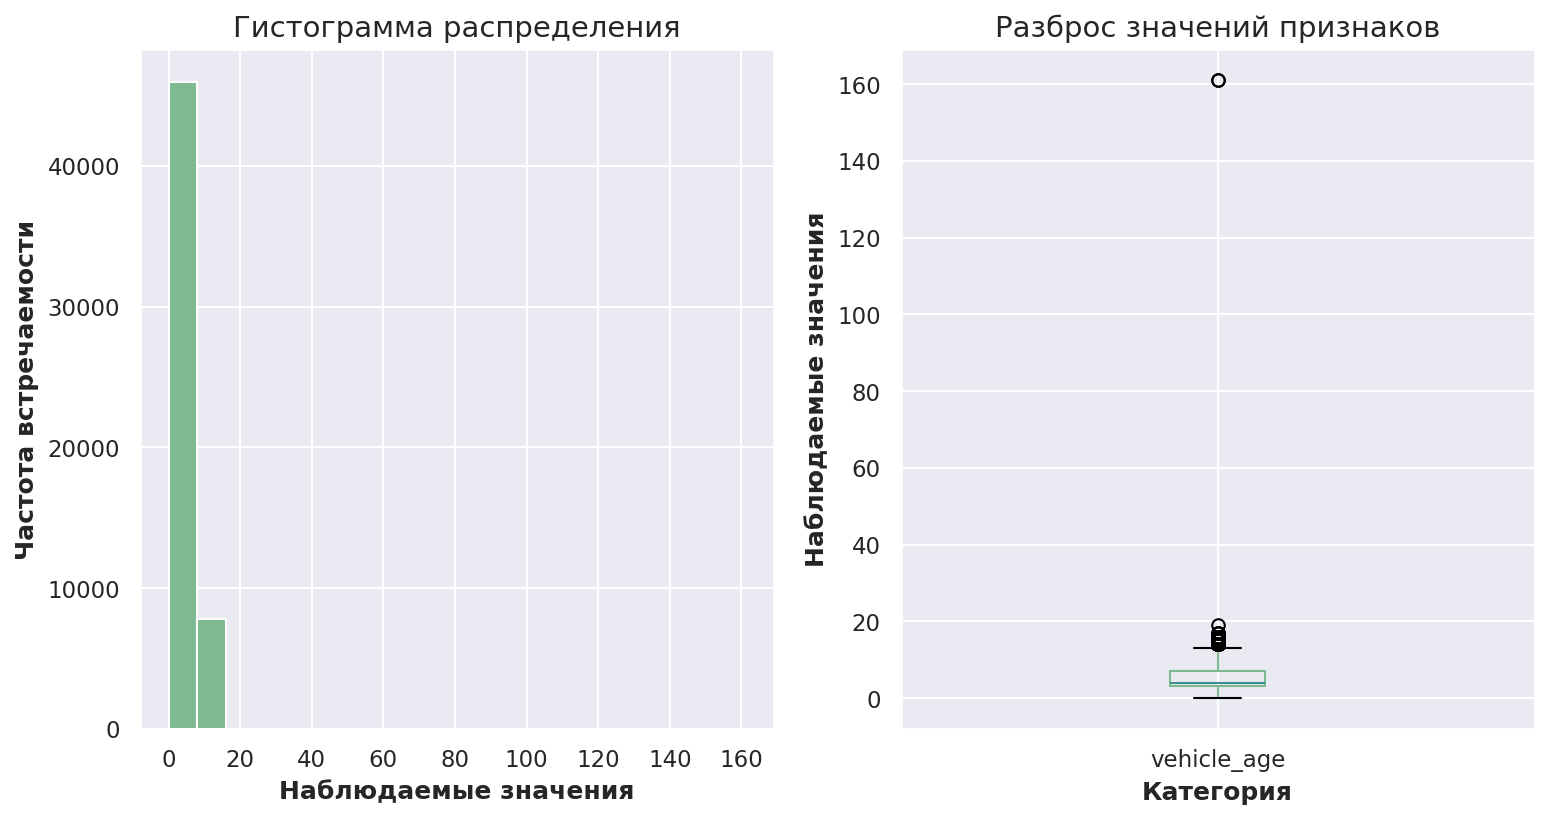

In [49]:
visuals(collisions, 'vehicle_age')

<font size="3"> На графике отмечаются выбросы в виде некорректного возраста автомобилей, изучим признак без учёта объектов в возрасте 161 года.

In [50]:
vehicle_age_filtered = collisions[(collisions['vehicle_age'] < 161)] 

<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

    
<b>На доработку❌:</b> С выбросами аналогично - удалять их следует после сплитования и только из `train`, чтобы модель была оценена на обычных данных, а не очень чистых - на пратике в любых данных бывают ошибки или выбросы.

<div class="alert alert-info">
<h2> Комментарий студента <a class="tocSkip"> </h2>

📝 Изучила признак без удаления данных, учту найденные выбросы в шаге подготовки данных
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера v.2 <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Учтено.

count   53,763.000
mean         4.861
std          3.098
min          0.000
25%          3.000
50%          4.000
75%          7.000
max         19.000
Name: vehicle_age, dtype: float64

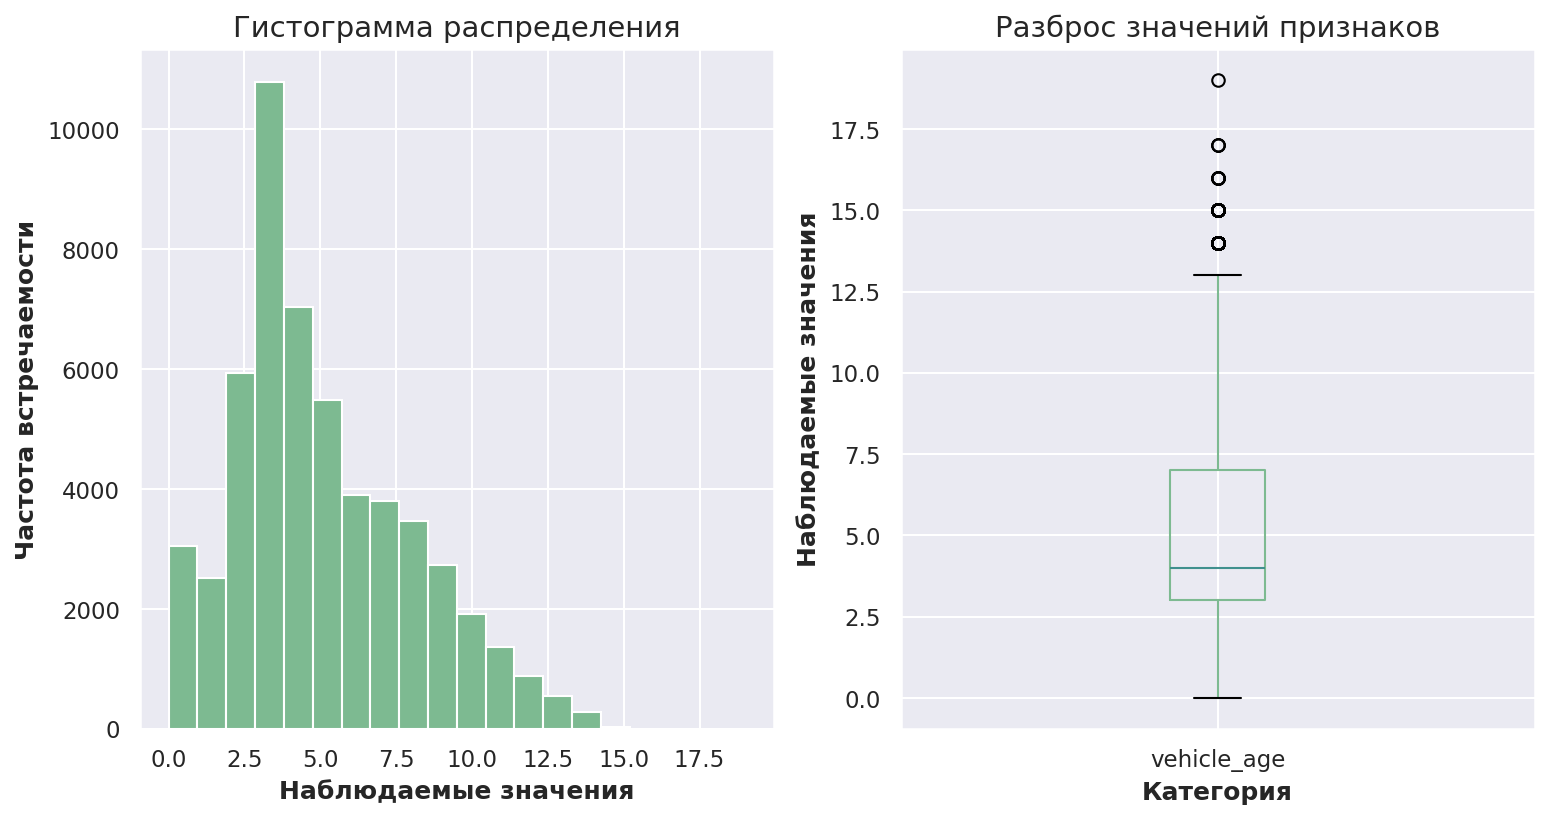

In [51]:
visuals(vehicle_age_filtered, 'vehicle_age')

<font size="3">

Признак `vehicle_age` - возраст автомобиля в годах.

Распределение признака асимметрично вправо, большинство значений располагается в промежутке от 3 до 7 лет с пиком в районе 3 лет.
    
Учтём найденные выбросы в шаге подготовки данных к обучению модели.

<font size="3"> 
    
> признак **distance**

count      53,765.000
mean          881.949
std         7,398.105
min             0.000
25%            10.000
50%           150.000
75%           593.000
max     1,584,000.000
Name: distance, dtype: float64

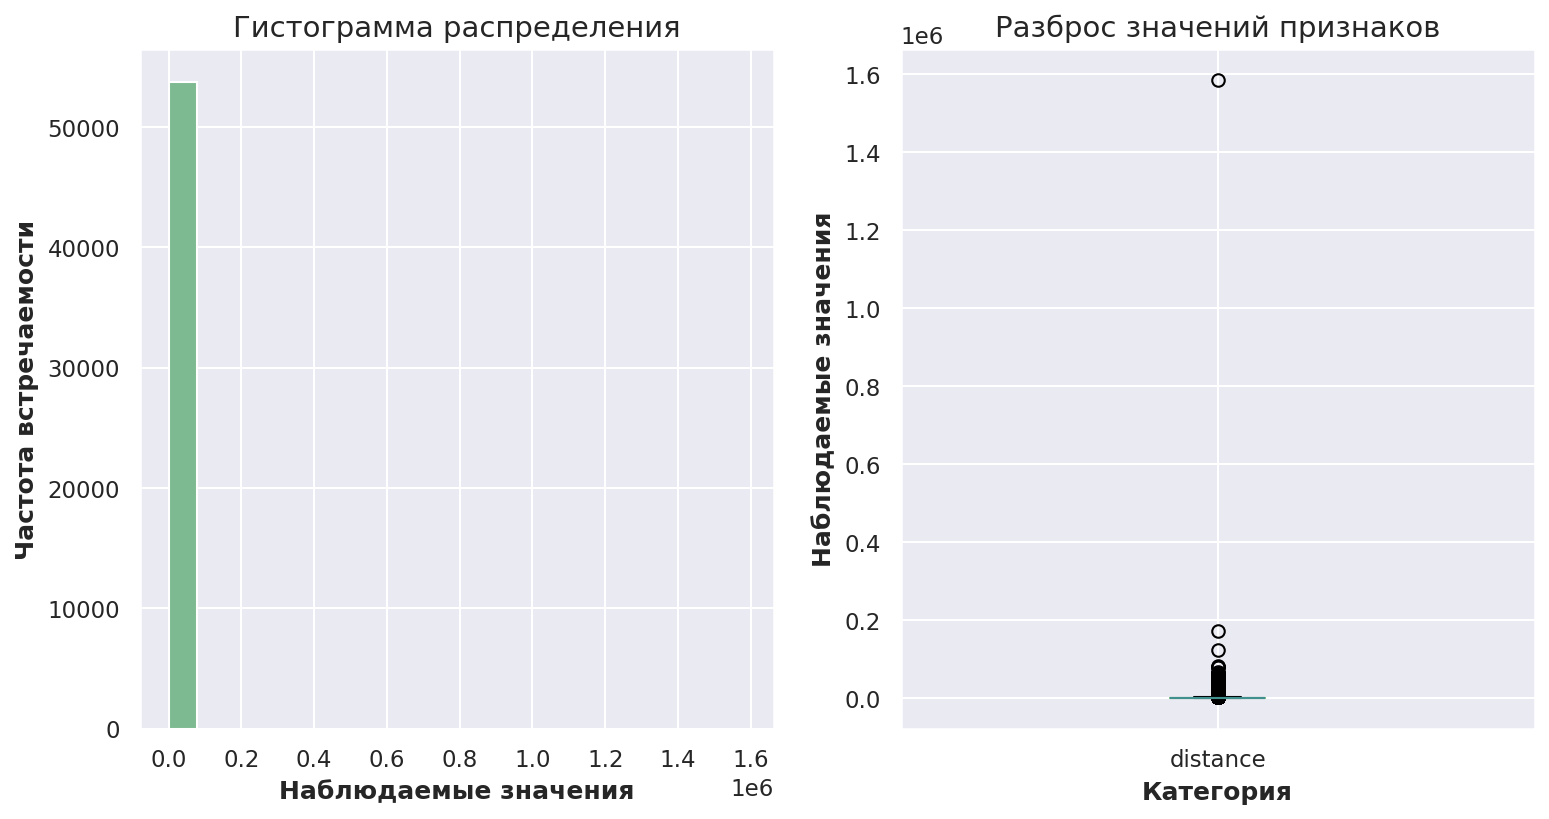

In [52]:
visuals(collisions, 'distance')

<font size="3"> На графике отмечаются выбросы в виде аномально большого расстояния до главной дороги. Изучим признак без учёта значений, превышающих 5 км.

In [53]:
distance_filtered = collisions[(collisions['distance'] <= 5000)]

count   51,858.000
mean       470.683
std        791.991
min          0.000
25%          7.000
50%        122.000
75%        528.000
max      5,000.000
Name: distance, dtype: float64

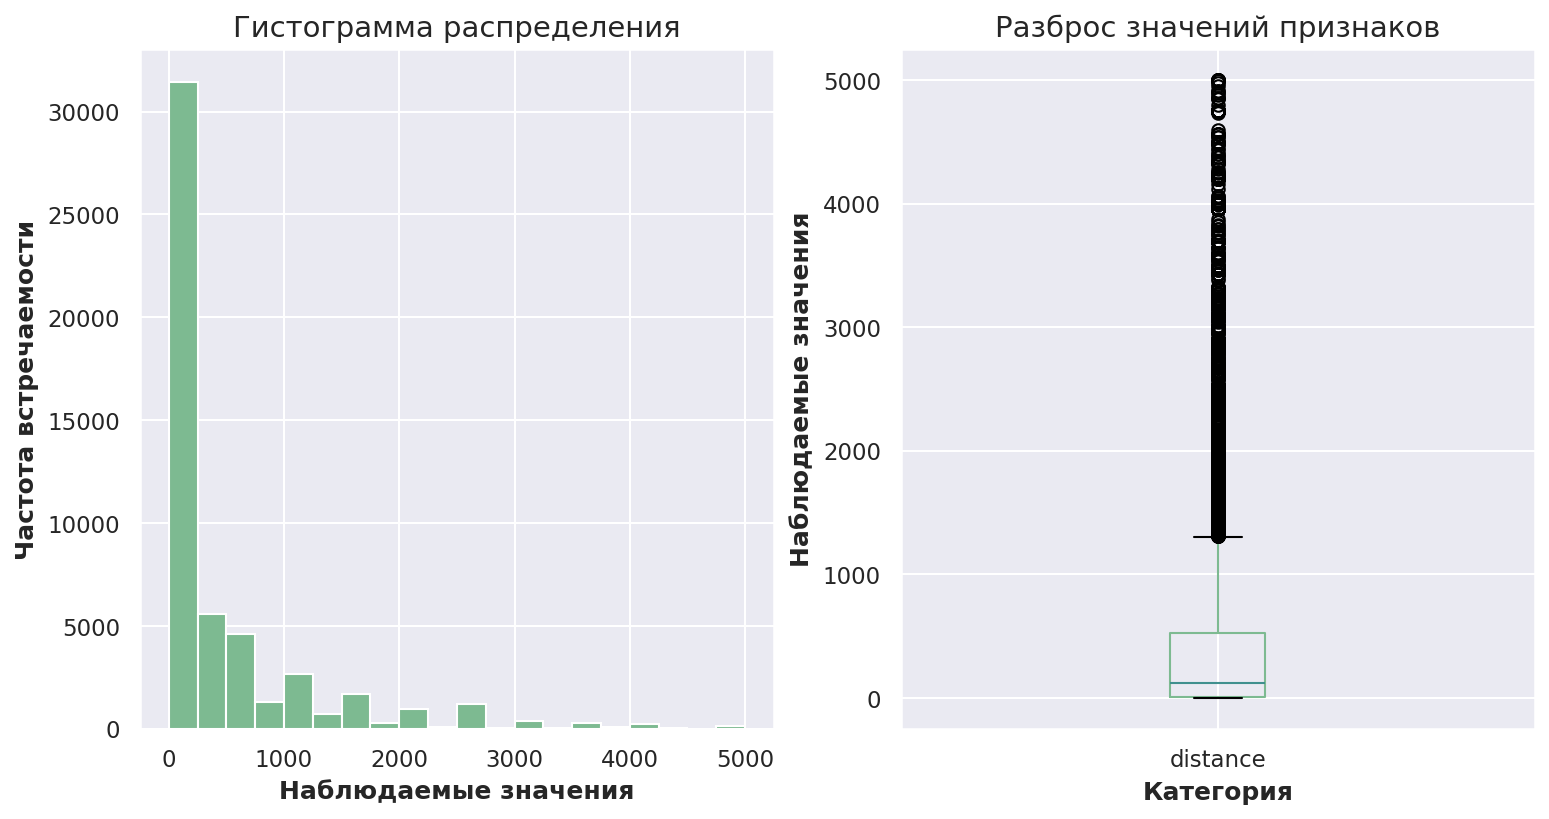

In [54]:
visuals(distance_filtered, 'distance')

<font size="3">
    
Признак `distance` - расстояние от главной дороги (метры). 
    
Распределение признака асимметрично вправо с длинным хвостом, большинство значений располагается в промежутке от 0 до 528 метров.

Учтём найденные выбросы в шаге подготовки данных к обучению модели.

### Категориальные признаки

<font size="3">
    
Изучим категориальные признаки датафрейма с помощью функции `cat_visuals`, которая визуализирует признак с помощью столбчатой гистограммы.

In [55]:
def cat_visuals(cat):
    plt.figure(dpi=PLOT_DPI)

    ax = sns.countplot(x=collisions[cat],
                   order=collisions[cat].value_counts(ascending=False).head(10).index);

    abs_values = collisions[cat].value_counts(ascending=False).head(10).values

    ax.bar_label(container=ax.containers[0], labels=abs_values, fontweight='bold')
    ax.set_title('Распределение категорий признака ' + cat, fontsize=14)
    ax.set_xlabel('Категории', fontweight='bold')
    ax.set_ylabel('Частота встречаемости', fontweight='bold')
    ax.figure.set_size_inches(12,6)

<font size="3"> 
    
> признак **at_fault**

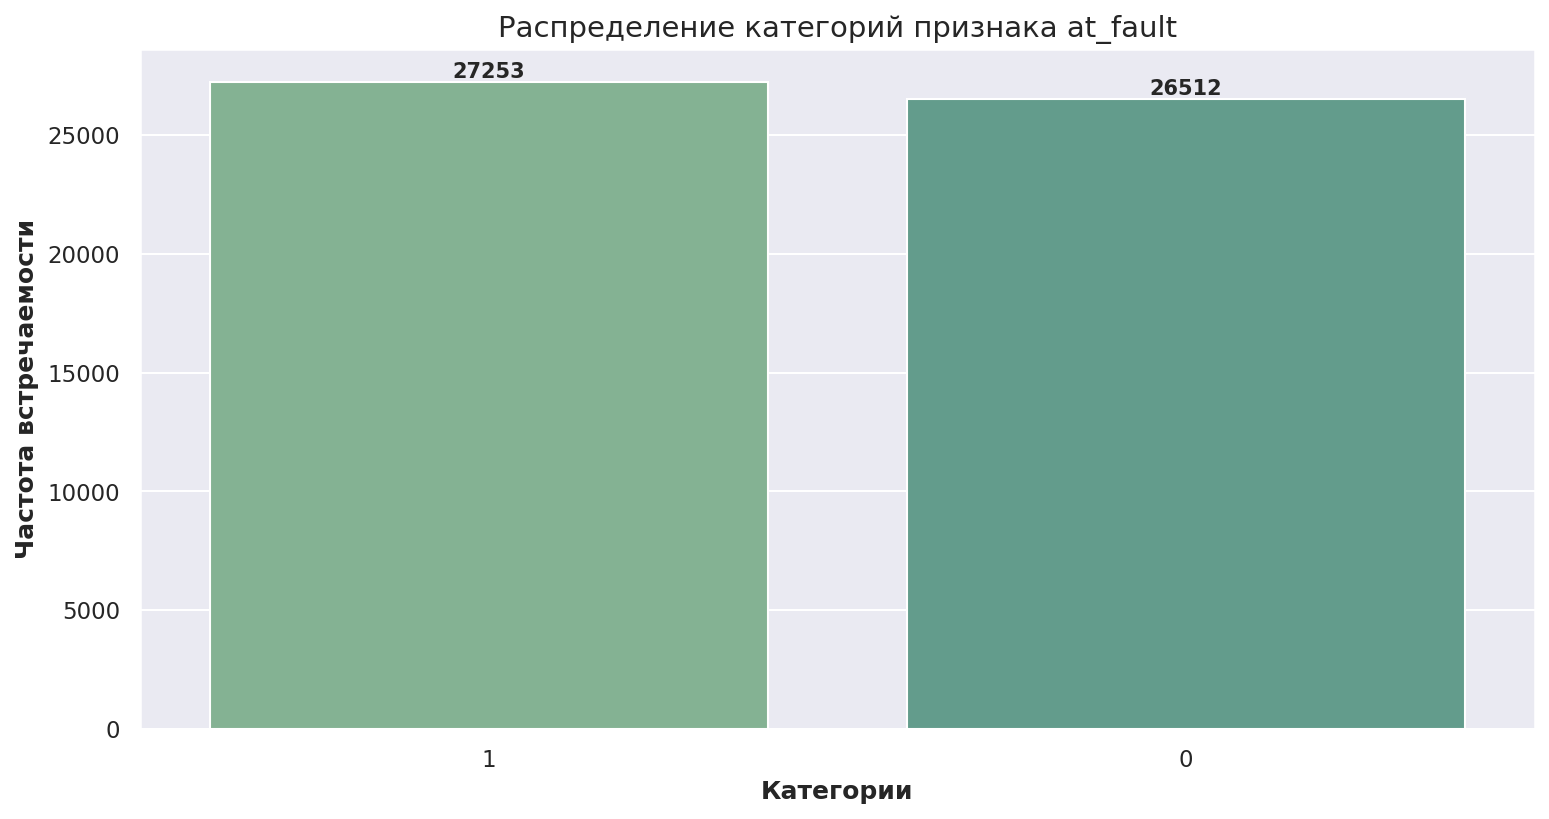

In [56]:
cat_visuals('at_fault')

In [57]:
collisions['at_fault'].value_counts(normalize=True)

1   0.507
0   0.493
Name: at_fault, dtype: float64

<font size="3">
    
Признак `at_fault` целевой, представлен категориями `0` и `1`.
    
Таргет достаточно сбалансированный: 50% на 50%.

<font size="3"> 
    
> признак **cellphone_in_use**

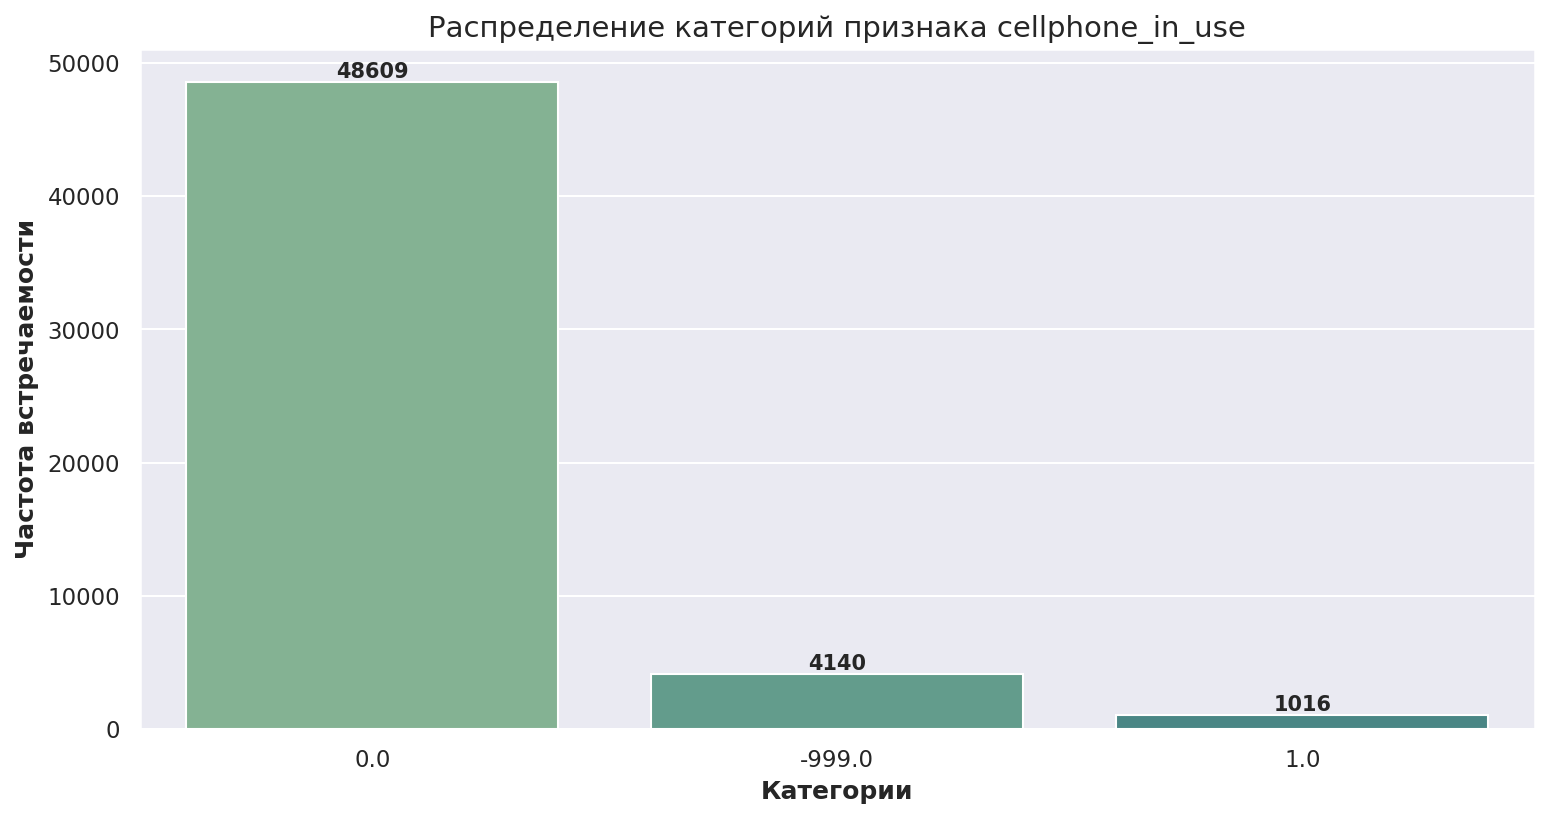

In [58]:
cat_visuals('cellphone_in_use')

<font size="3">
    
Признак `cellphone_in_use` представлен категориями: 
- нет         
- неизвестно       
- есть
    
В выборке значительно преобладает категория **нет**.

<font size="3"> 
    
> признак **vehicle_type**

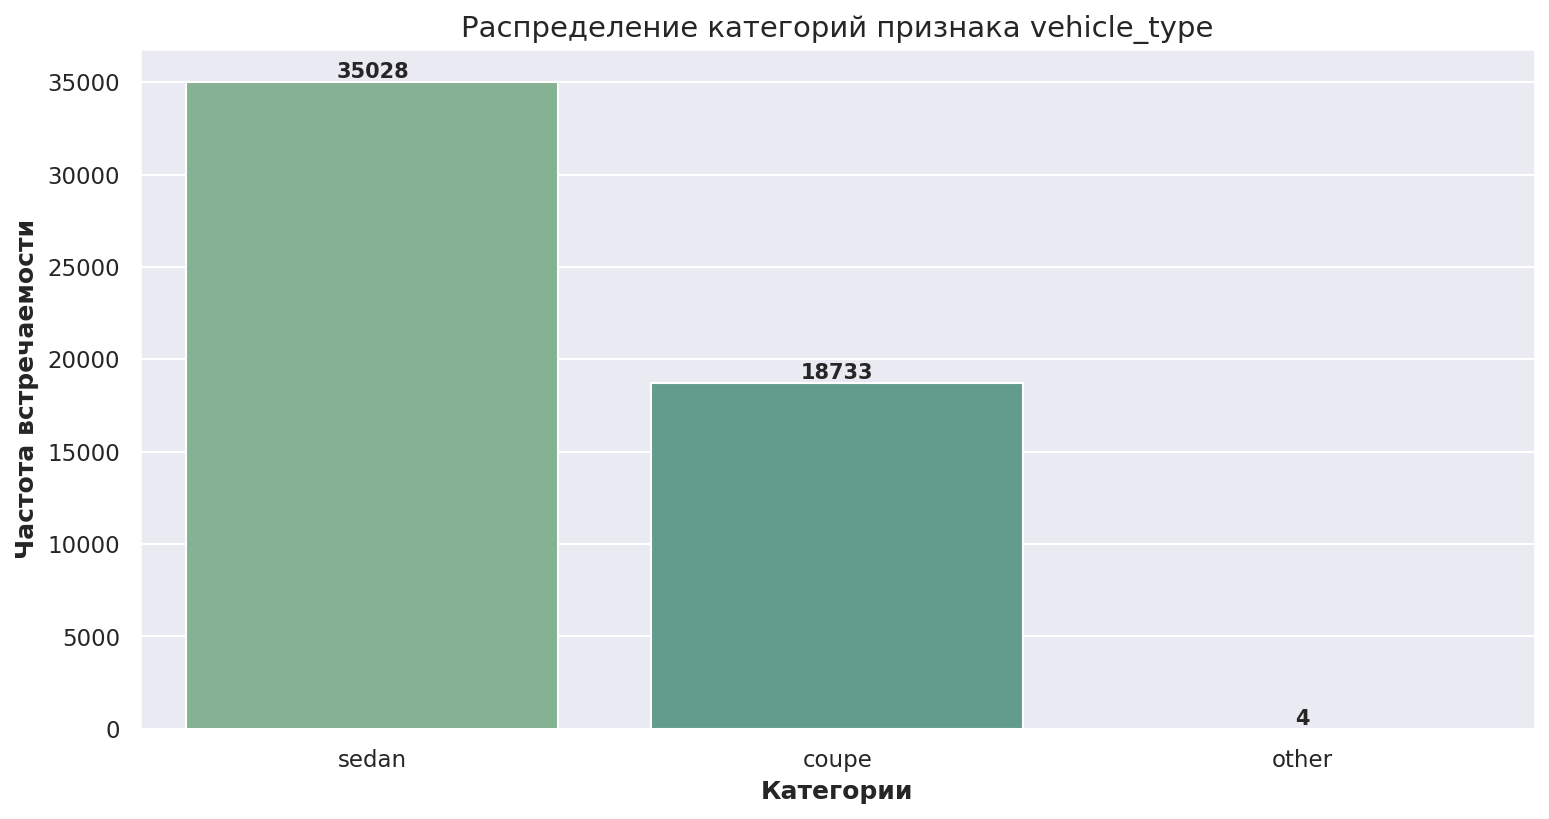

In [59]:
cat_visuals('vehicle_type')

<font size="3">
    
Признак `vehicle_type` представлен категориями: 
- coupe         
- sedan       
- other
    
Основные категории **coupe** и **sedan** представлены в выборке равномерно.

<font size="3"> 
    
> признак **county_location**

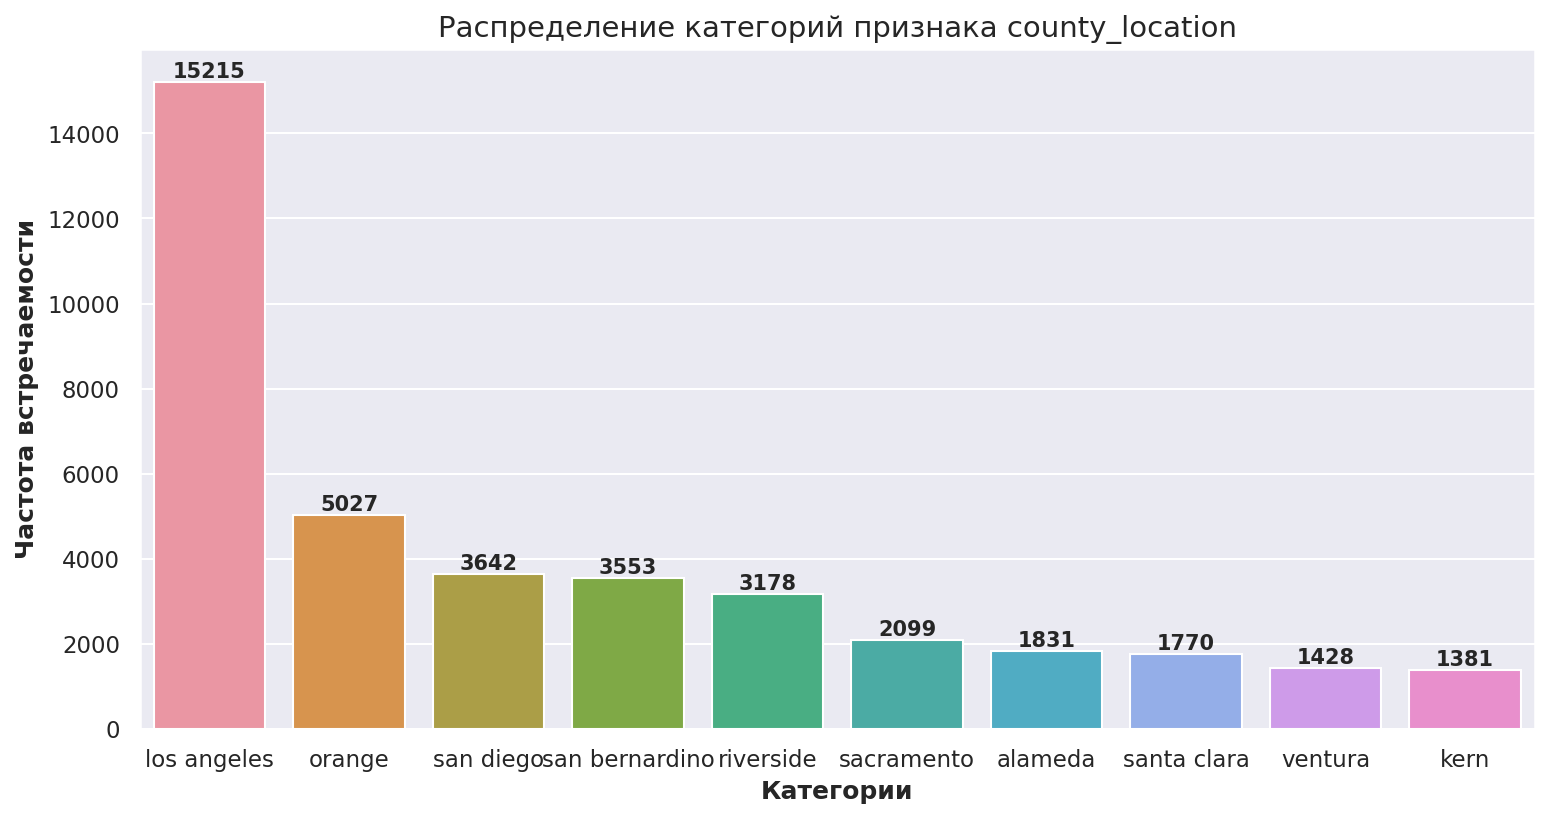

In [60]:
cat_visuals('county_location')

<font size="3">
    
Признак `cellphone_in_use` содержит названия географических районов, где произошло ДТП.
    
В выборке значительно преобладает **los angeles**.

<font size="3"> 
    
> признак **intersection**

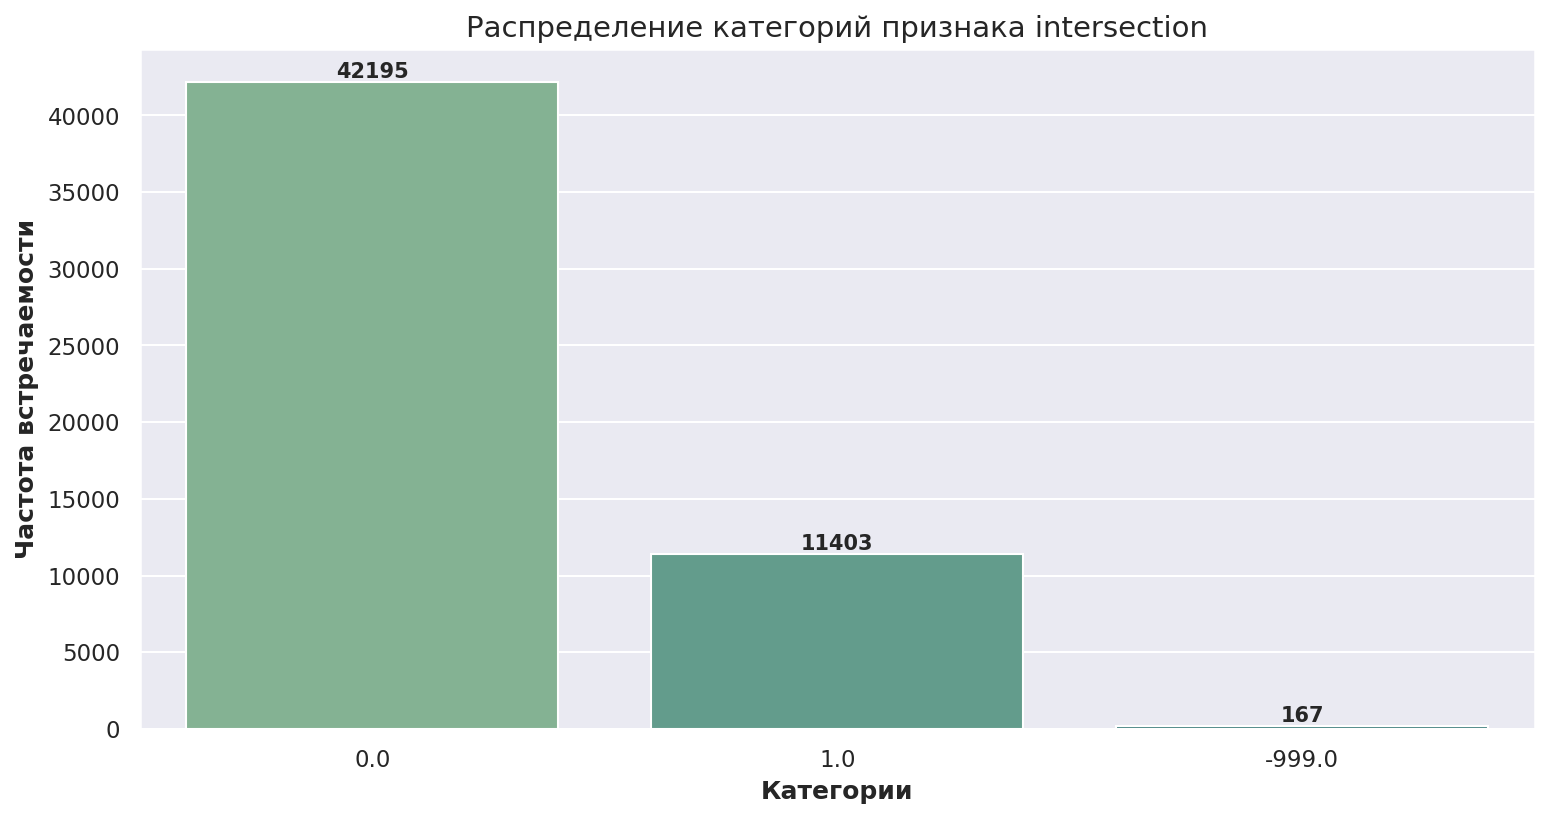

In [61]:
cat_visuals('intersection')

<font size="3">
    
Признак `intersection` представлен категориями: 
- нет         
- да       
- неизвестно
    
В выборке значительно преобладает категория **нет**.

<font size="3"> 
    
> признак **weather**

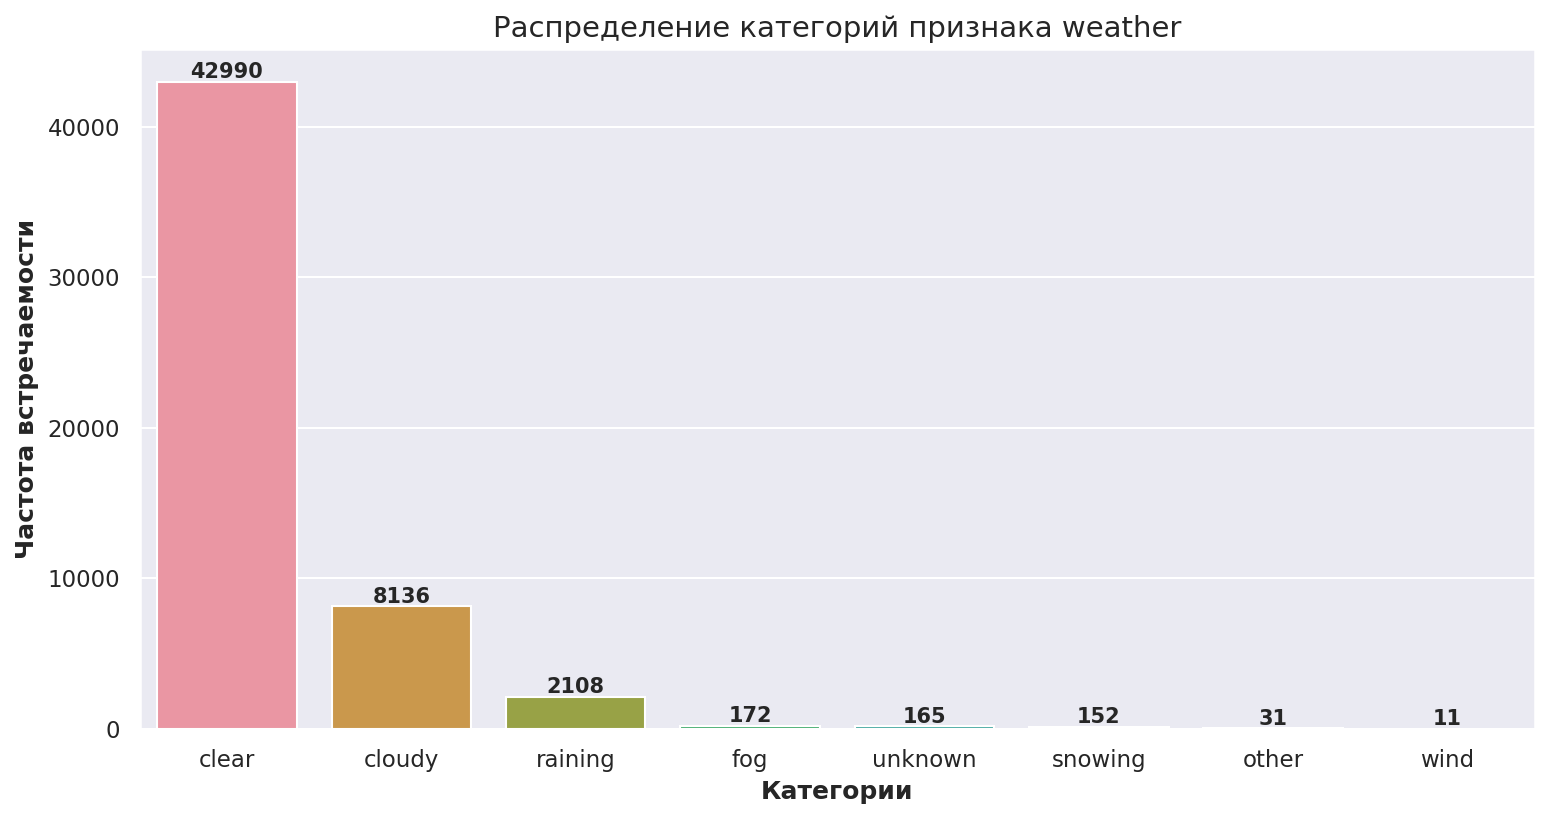

In [62]:
cat_visuals('weather')

<font size="3">
    
Признак `weather` содержит данные о погоде в момент ДТП.
    
В выборке значительно преобладает категория **clear**.

<font size="3"> 
    
> признак **location_type**

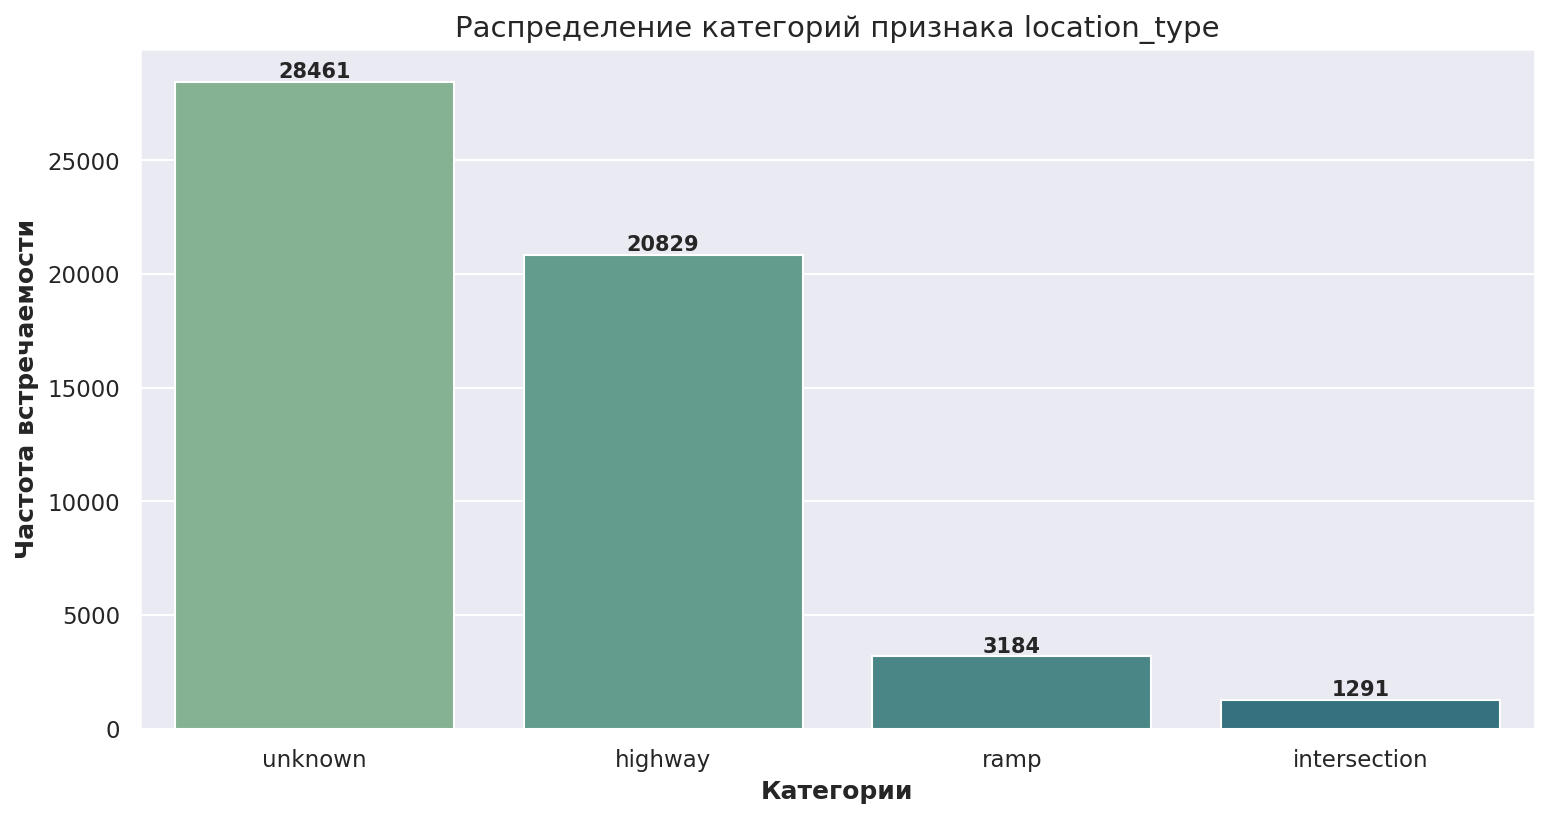

In [63]:
cat_visuals('location_type')

<font size="3">
    
Признак `location_type` содержит данные о типе дороги: 
- unknown         
- highway       
- ramp
- intersection
    
Признак содержал более 50% пропущенных значений, за исключением категории-заглушки в выборке преобладает категория **highway**.

<font size="3"> 
    
> признак **road_surface**

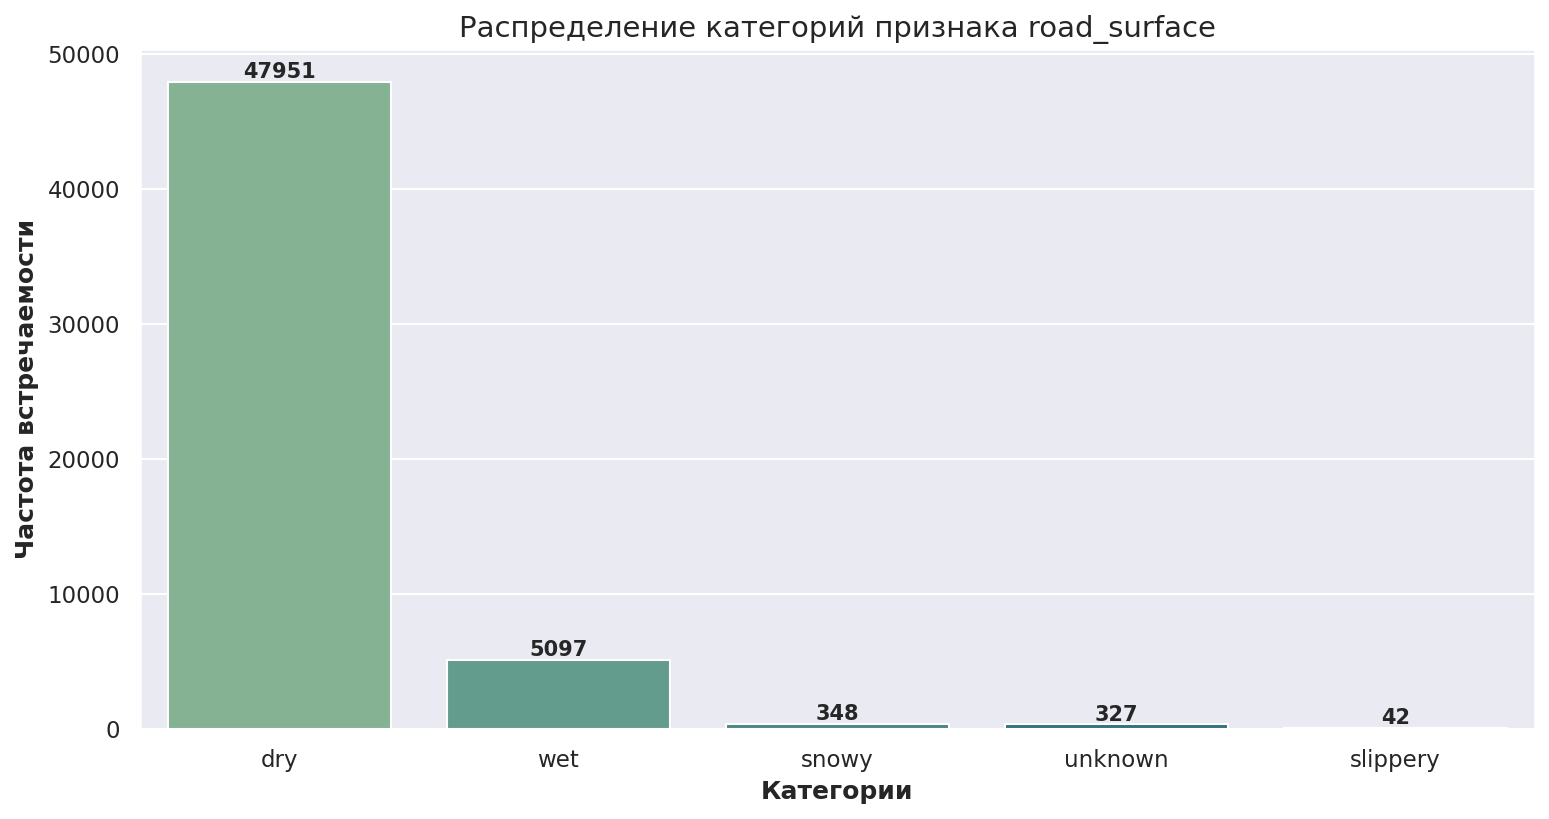

In [64]:
cat_visuals('road_surface')

<font size="3">
    
Признак `road_surface` содержит данные о состоянии дороги в зависимости от погодных условий: 
- dry         
- wet       
- unknown
- snowy
- slippery
    
В выборке преобладает категория **dry**.

<font size="3"> 
    
> признак **road_condition**

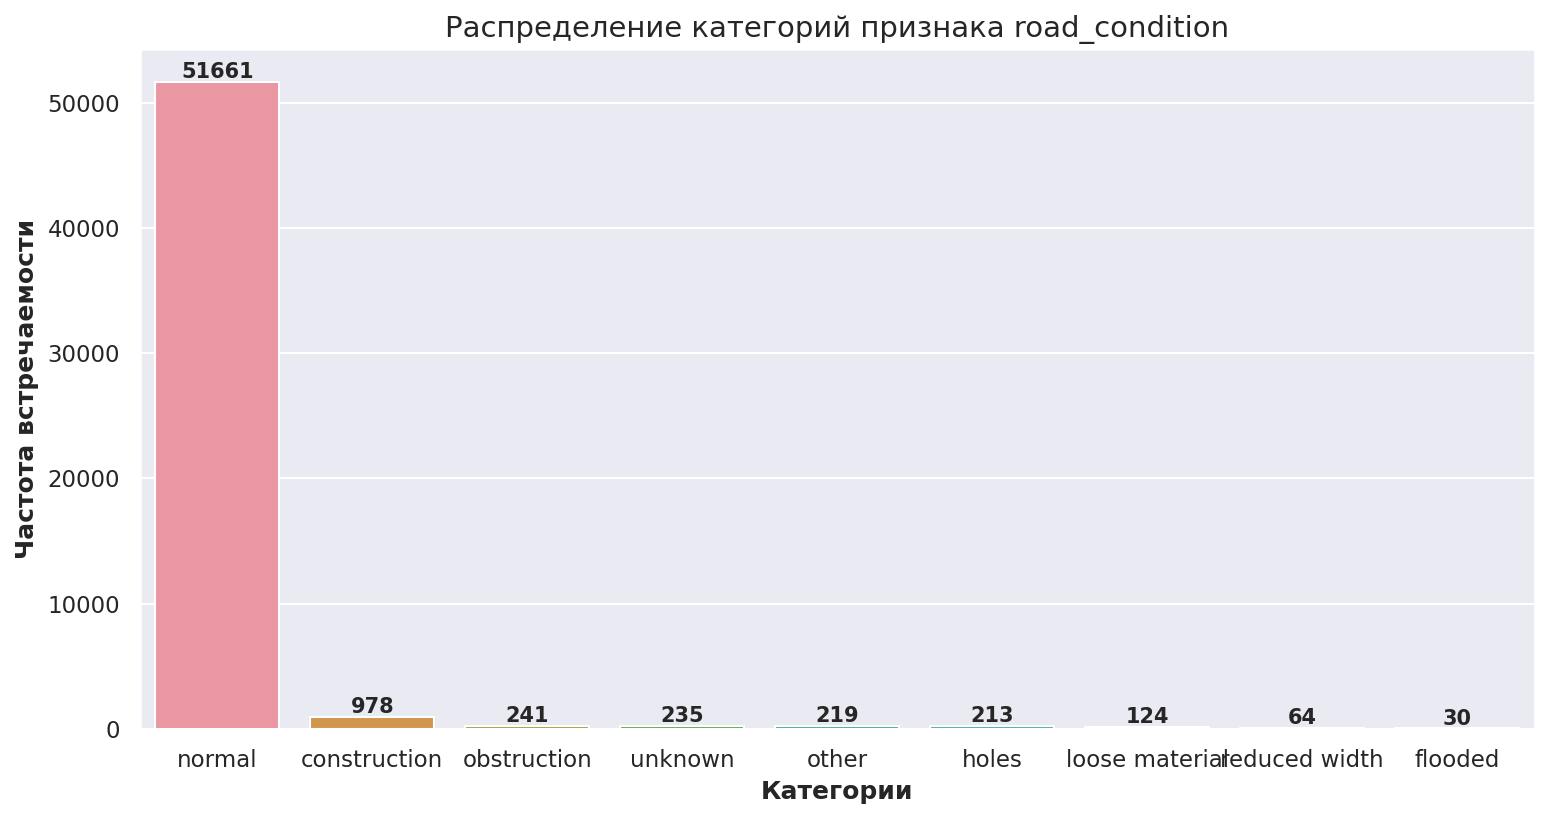

In [65]:
cat_visuals('road_condition')

<font size="3">
    
Признак `road_condition` содержит данные о состоянии дорожного покрытия и дороги: 
- normal         
- construction       
- unknown
- holes
- obstruction
- other
- loose material 
- reduced width
- flooded
    
В выборке преобладает категория **normal**.

<font size="3"> 
    
> признак **lighting**

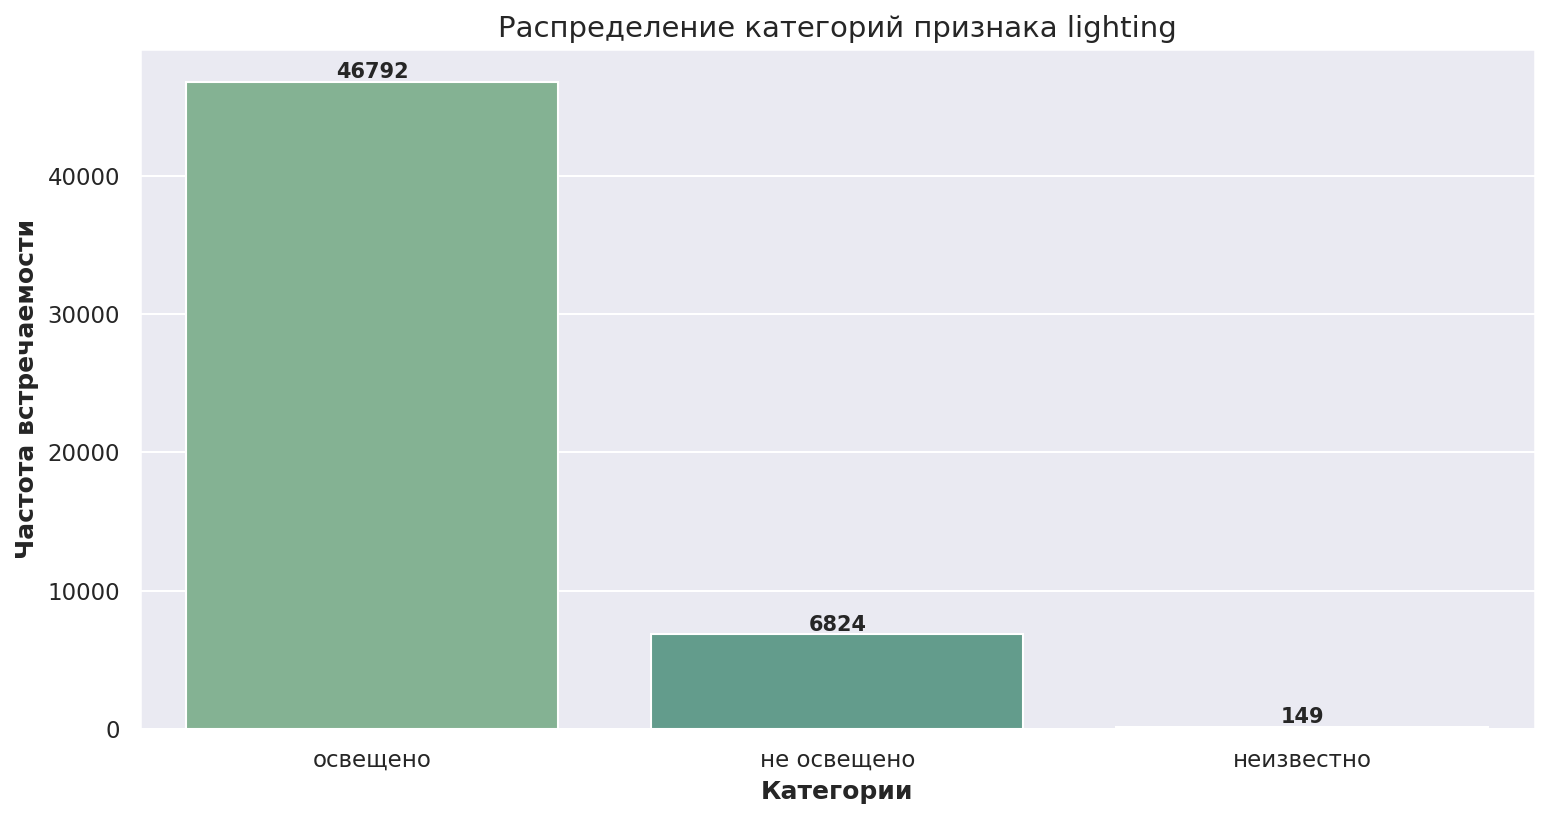

In [66]:
cat_visuals('lighting')

<font size="3">
    
Признак `lighting` содержит данные об освещённости дороги в момент ДТП: 
- освещено     
- не освещено      
- неизвестно
    
В выборке значительно преобладает категория **освещено**.

<font size="3"> 
    
> признак **collision_month**

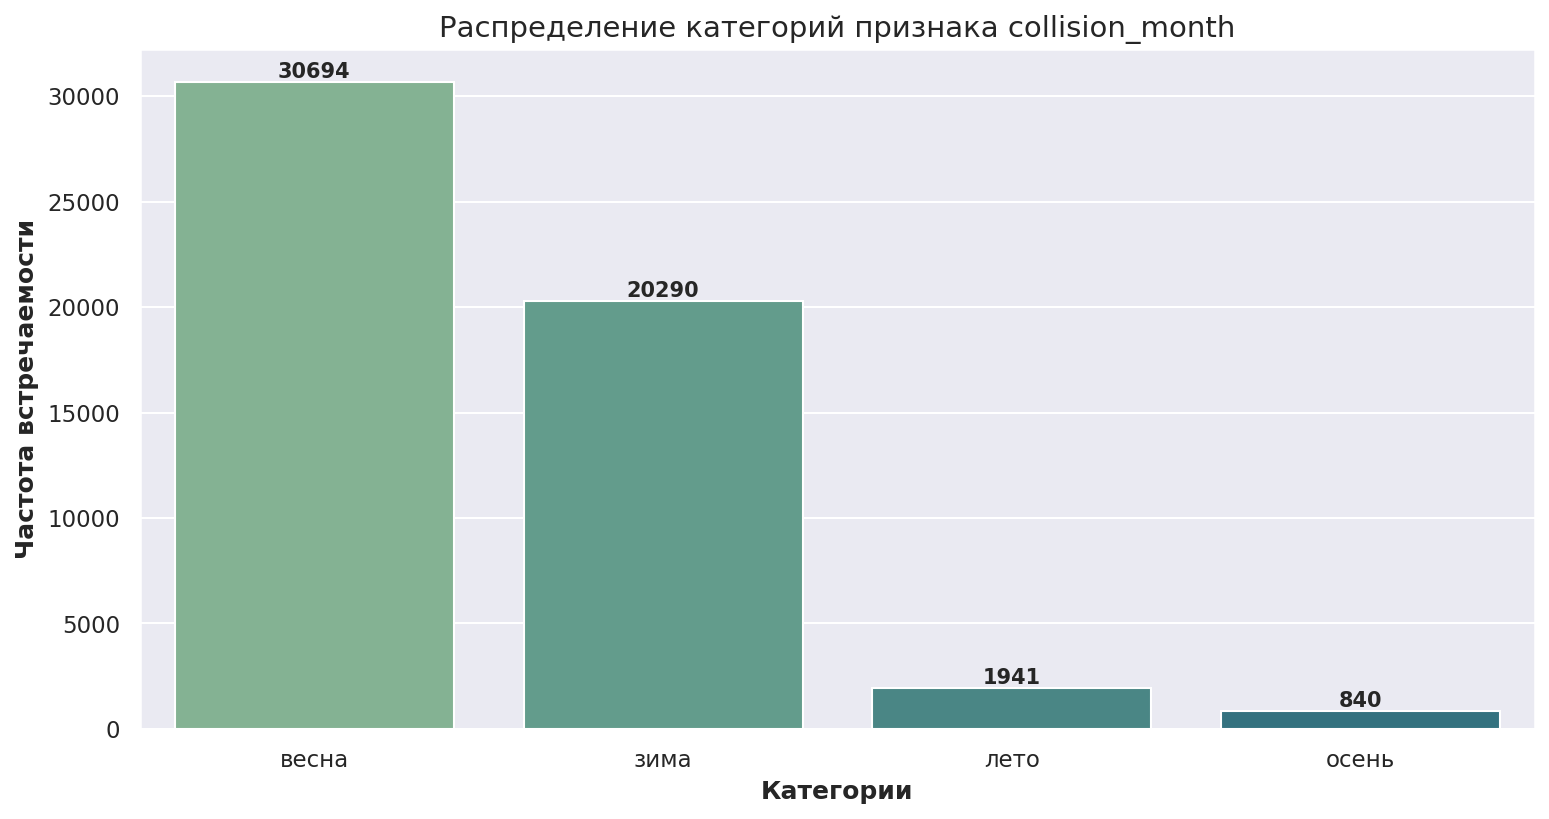

In [67]:
cat_visuals('collision_month')

<font size="3">
    
Признак `collision_month` содержит данные о времени года в момент ДТП: 
- весна     
- зима  
- лето
- осень
    
В выборке преобладает категория **весна**.

<font size="3"> 
    
> признак **collision_hour**

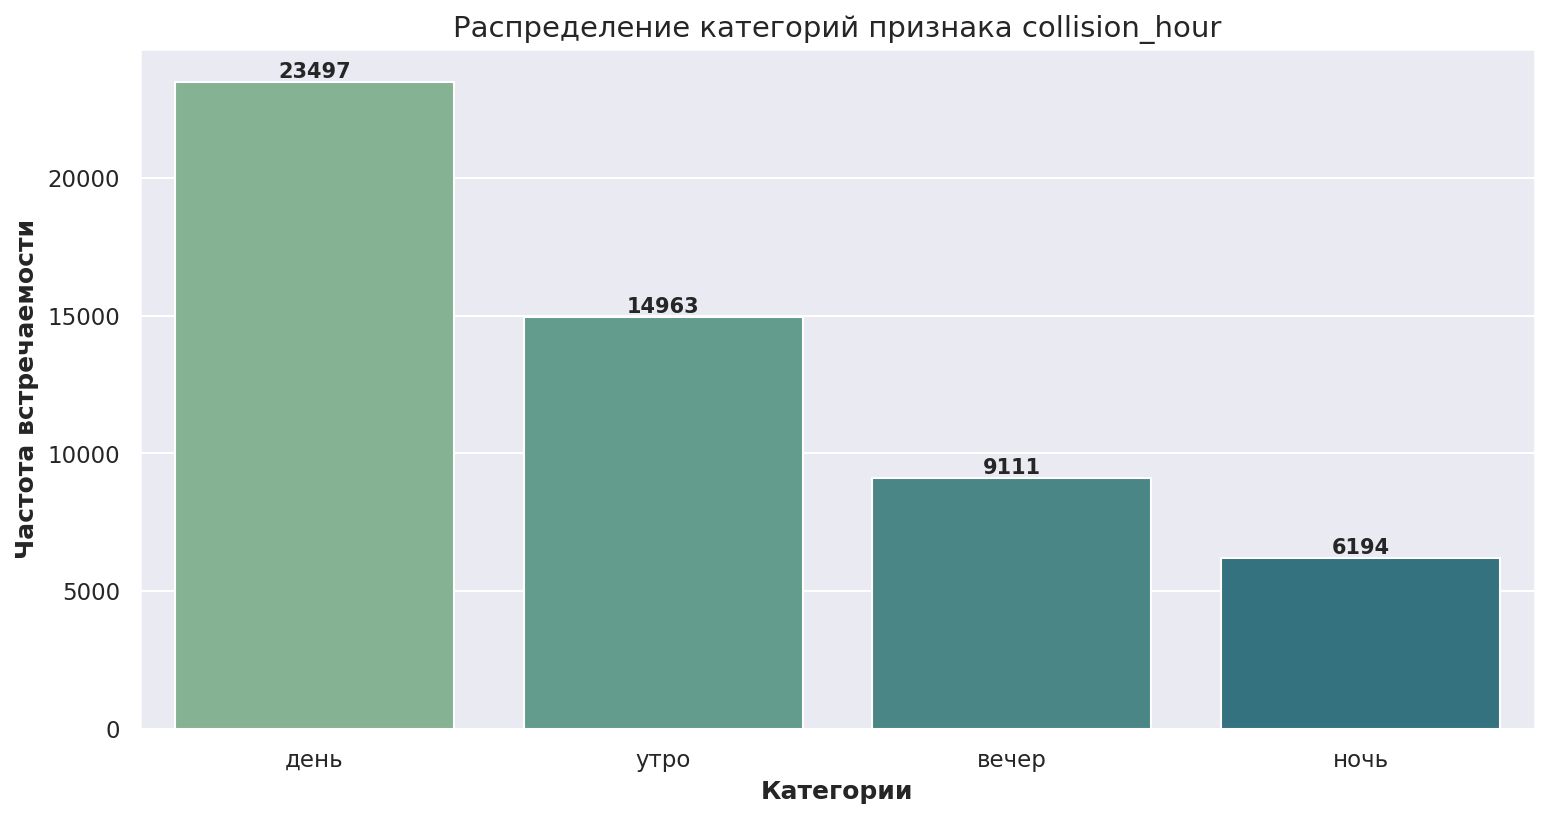

In [68]:
cat_visuals('collision_hour')

<font size="3">
    
Признак `collision_hour` содержит данные о времени суток в момент ДТП: 
- день     
- утро  
- вечер
- ночь
    
В выборке преобладает категория **день**.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

<font size="3">
    
**Вывод раздела:**

В датафрейме `collisions` 3 количественных и 15 категориальных признаков, включая целевой. 
    
Выбросы и аномалии в данных изучены и обработаны.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> EDA выборки выполнен.

## Корреляционный анализ

<font size="3">  Корреляцию признаков рассмотрим с помощью матрицы корреляций `phik_matrix()`.

In [69]:
# функция построения матрицы корреляций phik
def phik_matrix(df):
    # список интервальных признаков
    interval_cols = ['insurance_premium', 'vehicle_age', 'distance']
    
    # вычисление коэффициентов корреляции phi для датафрейма
    phik_overview = df.phik_matrix(interval_cols=interval_cols)

    # визуализация тепловой карты коэффициентов корреляции
    plot_correlation_matrix(
        phik_overview.values,
        x_labels=phik_overview.columns,
        y_labels=phik_overview.index,
        title=r"Матрица корреляции $\phi_K$",
        fontsize_factor=1.5,
        figsize=(30, 15)
    )

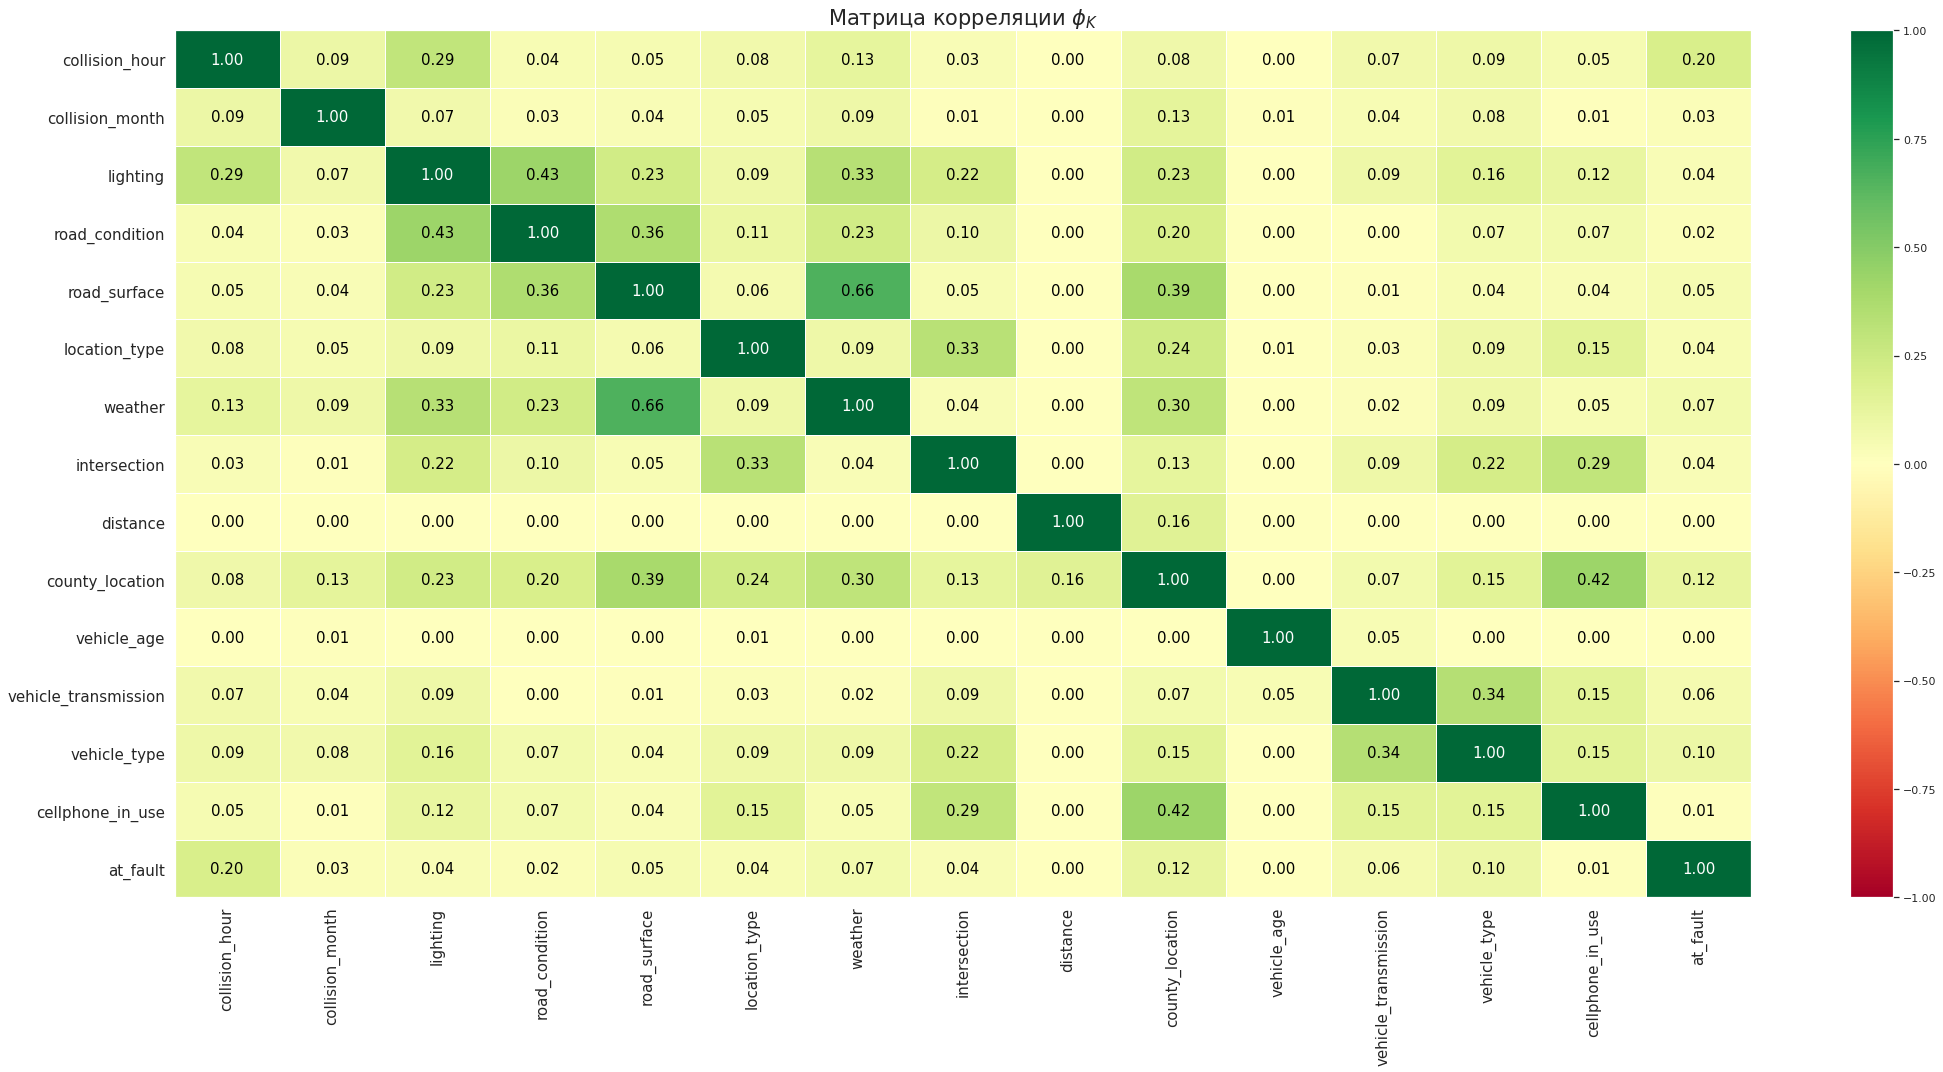

In [70]:
phik_matrix(collisions)

<font size="3">
    
Ощутимая зависимость с целевым признаком `at_fault` выявлена у признаков: 
- `vehicle_age`
- `collision_hour`
    
У остальных входных признаков слабая зависимость с целевым.

Мультиколлинеарность входных признаков отсутствует.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b>
    
Есть анализ корреляции - молодец, что используешь `phik` для анализа и нелинейных зависимостей, а также настраиваешь `interval_cols` для корректной оценки корреляции для переменных разного типа.

## Разработка моделей

<font size="3"> В данном шаге исследования проведем сравнительный анализ трёх моделей, обученных на следующих алгоритмах:

- `LogisticRegression()`
- `RandomForestClassifier()`
- `CatBoostClassifier()`

Качество модели оценим с помощью метрики `weighted_f1`, что поможет найти баланс между точностью классификации и полнотой обнаружения риска.
 
При оценке риска ДТП важно учесть `recall`, чтобы выявлять как можно больше случаев с потенциальным риском происшествия, при этом нельзя пренебречь `precision`, так как большое количество ложных оповещений может утомлять водителей и привести к снижению доверия к системе.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Есть обоснование для выбора метрик.

<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

    
<b>На доработку❌:</b> Нужно тем не менее выбрать главную метрику, по которой будет выбираться лучшая модель.

<div class="alert alert-info">
<h2> Комментарий студента <a class="tocSkip"> </h2>

📝 Выбрала основную метрику
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера v.2 <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Учтено.

### Формирование выборок

<font size="3"> Подготовим данные к обучению.

In [71]:
# обозначим входные и целевой признаки
X = collisions.drop('at_fault', axis=1)
y = collisions['at_fault']

# разделим данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

# проверка баланса классов в выборках
print(f'''Баланс классов целевого признака:
y_train:
{round(y_train.value_counts()/len(y_train)*100)}
y_test:
{round(y_test.value_counts()/len(y_test)*100)}
''')

Баланс классов целевого признака:
y_train:
1   51.000
0   49.000
Name: at_fault, dtype: float64
y_test:
1   51.000
0   49.000
Name: at_fault, dtype: float64



<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Сплитование выполнено корректно. Молодец, что делаешь стратификацю целевого признака - в выборках будет равное соотношение классов, что может привести к росту качества твоего решения.

<font size="3"> Обработаем найденные выбросы: удалим из выборки объекты `vehicle_age` в возрасте 161 года и значения `distance`, превышающие 5 км.

In [72]:
# удялаем выбросы 
X_train = X_train.loc[(X_train['vehicle_age'] < 161) & (X_train['distance'] <= 5000)]
y_train = y_train.loc[X_train.index]

# проверяем результат
display(X_train.describe())
print("Обучающая выборка:")
print(X_train.shape)
print("\nТестовая выборка:")
print(y_train.shape)

,cellphone_in_use,vehicle_age,distance,intersection
count,"38,896.000","38,896.000","38,896.000","38,896.000"
mean,-79.755,4.836,471.570,-2.966
std,270.805,3.095,792.160,56.330
min,-999.000,0.000,0.000,-999.000
25%,0.000,3.000,8.000,0.000
50%,0.000,4.000,121.000,0.000
75%,0.000,7.000,528.000,0.000
max,1.000,17.000,"5,000.000",1.000


Обучающая выборка:
(38896, 14)

Тестовая выборка:
(38896,)


In [73]:
# создадим списки с названиями признаков
num_columns = X_train.select_dtypes(include='number').columns.tolist()
ohe_columns = X_train.select_dtypes(exclude='number').columns.tolist()
ord_columns = X_train.select_dtypes(exclude='number').columns.tolist()
cat_features = X_train.select_dtypes(exclude='number').columns.tolist()

<font size="3">
    
Данные подготовлены: убраны аномалии, заполнены пропущенные значения, сформированы обучающая и тестовая выборки.

Можно переходить к работе с моделями машинного обучения.

### `LogisticRegression()`

<font size="3"> Напишем модель логистической регрессии с подбором гиперпараметров.

In [74]:
# создаём пайплайн для подготовки признаков из списка ohe_columns: заполнение пропусков + OHE-кодирование
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Unknown')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
)

# создаём общий пайплайн для подготовки данных
data_preprocessor_log = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('num', StandardScaler(), num_columns)
    ], 
    remainder='passthrough'
)

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Здорово, что используешь сочетание `ColumnTransformer` и `Pipeline` для соединения разных инструментов в единый модельный объект и настраиваешь бесперебойную работу энкодера в случае появления в данных новых, неизвестных на момент обучения значений признаков - так твоё решение будет более гибким и масштабируемым. 

In [75]:
# трансформируем признаки для обучения с помощью data_preprocessor_log()
X_train_log = pd.DataFrame(data_preprocessor_log.fit_transform(X_train))
X_test_log = pd.DataFrame(data_preprocessor_log.transform(X_test))

def objective_log(trial):
    
    # укажем гиперпараметры для перебора
    params_log = {
        'C': trial.suggest_loguniform('C', 0.01, 10.0),
        'solver': trial.suggest_categorical('solver', ['liblinear', 'newton-cg', 'lbfgs', 'sag', 'saga']),
        'max_iter': trial.suggest_int('max_iter', 100, 1000),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        "random_state": RANDOM_STATE
    }
    
    # создадим модель LogisticRegression() с предлагаемыми параметрами
    model_log = LogisticRegression(**params_log)

    # используем кросс-валидацию для оценки модели
    f1_scores = cross_val_score(model_log, X_train_log, y_train, cv=5, scoring='f1_weighted')

    # возвращаем среднее значение F1-метрики
    return np.mean(f1_scores)

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Здорово, что используешь `Optuna` для оптимизации моделей.

<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

    
<b>На доработку❌:</b> Оценку моделей в ходе оптимизации нужно выполнять на кросс-валидации, а не `test`.

<div class="alert alert-info">
<h2> Комментарий студента <a class="tocSkip"> </h2>

📝  Исправила функцию Optuna
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера v.2 <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Учтено.

In [76]:
# создадим объект study
study_log = optuna.create_study(direction="maximize", pruner=MedianPruner()) 

# запустим процесс оптимизации
study_log.optimize(objective_log, n_trials=30)

[I 2025-05-16 19:41:25,709] A new study created in memory with name: no-name-a35c7066-891f-40c9-aaf2-176cd449693b
[I 2025-05-16 19:42:23,054] Trial 0 finished with value: 0.5940762606870096 and parameters: {'C': 1.012916140760532, 'solver': 'lbfgs', 'max_iter': 240, 'class_weight': None}. Best is trial 0 with value: 0.5940762606870096.
[I 2025-05-16 19:42:43,443] Trial 1 finished with value: 0.5952936580585069 and parameters: {'C': 0.047131557684553356, 'solver': 'lbfgs', 'max_iter': 426, 'class_weight': None}. Best is trial 1 with value: 0.5952936580585069.
[I 2025-05-16 19:44:02,660] Trial 2 finished with value: 0.5939591918835322 and parameters: {'C': 2.988665622660185, 'solver': 'newton-cg', 'max_iter': 477, 'class_weight': None}. Best is trial 1 with value: 0.5952936580585069.
[I 2025-05-16 19:44:14,152] Trial 3 finished with value: 0.5946987368114988 and parameters: {'C': 0.12067548535791311, 'solver': 'sag', 'max_iter': 404, 'class_weight': None}. Best is trial 1 with value: 0.5

In [77]:
scores_log_f1 = study_log.best_value

# выведем метрику лучшей модели
print('Лучшая метрика F1 на кросс-валидационной выборке:')
scores_log_f1

Лучшая метрика F1 на кросс-валидационной выборке:


0.5957547795907765

<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

    
<b>На доработку❌:</b> Этот блок соответственно не нужен, так как кросс-валидация будет выполнена в `Optuna`.

<div class="alert alert-info">
<h2> Комментарий студента <a class="tocSkip"> </h2>

📝 Убрала отдельный блок кросс-валидации
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера v.2 <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Учтено.

<font size="3">

На данном этапе исследования написана модель `LogisticRegression()` с подбором гиперпараметров, который определил лучшие параметры модели с помощью метрики `weighted_f1`:
    
- лучшая метрика **F1** на кросс-валидационной выборке: **0.63**

### `RandomForestClassifier()`

<font size="3"> Напишем модель случайного леса классификации с подбором гиперпараметров.

In [78]:
# создадим пайплайн для подготовки признаков из списка ord_columns: заполнение пропусков + Ordinal-кодирование
ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Unknown')),
     ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value=-999))
    ]
)

# создадим общий пайплайн для подготовки данных
data_preprocessor_forest = ColumnTransformer(
    [('ord', ord_pipe, ord_columns),
     ('num', RobustScaler(), num_columns)
    ],
    remainder='passthrough'
)

# трансформируем признаки для обучения с помощью data_preprocessor_forest()
X_train_forest = pd.DataFrame(data_preprocessor_forest.fit_transform(X_train))
X_test_forest = pd.DataFrame(data_preprocessor_forest.transform(X_test))

# напишем функцию для подбора гиперпараметров с помощью Optuna
def objective_forest(trial):

    # укажем гиперпараметры для перебора
    params_forest = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int("min_samples_split", 2, 10),
        'min_samples_leaf': trial.suggest_int("min_samples_leaf", 1, 5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        "n_jobs": -1,
        "random_state": RANDOM_STATE
    }

    # создадим модель RandomForestClassifier() с предлагаемыми параметрами
    model_forest = RandomForestClassifier(**params_forest)

    # используем кросс-валидацию для оценки модели
    f1_scores = cross_val_score(model_forest, X_train_forest, y_train, cv=5, scoring='f1_weighted')

    # возвращаем среднее значение F1-метрики
    return np.mean(f1_scores)

In [79]:
# создадим объект study
study_forest = optuna.create_study(direction="maximize", pruner=MedianPruner()) 

# запустим процесс оптимизации
study_forest.optimize(objective_forest, n_trials=30)

[I 2025-05-16 19:52:30,655] A new study created in memory with name: no-name-3103ef0a-4a33-4bfd-bd00-b39d6483e682
[I 2025-05-16 19:53:41,496] Trial 0 finished with value: 0.5884749959378813 and parameters: {'n_estimators': 415, 'max_depth': 29, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 0.5884749959378813.
[I 2025-05-16 19:53:54,504] Trial 1 finished with value: 0.6121703503084253 and parameters: {'n_estimators': 182, 'max_depth': 7, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 1 with value: 0.6121703503084253.
[I 2025-05-16 19:54:35,495] Trial 2 finished with value: 0.6092302876728283 and parameters: {'n_estimators': 401, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 1 with value: 0.6121703503084253.
[I 2025-05-16 19:55:15,262] Trial 3 finished with value: 0.607095463240841

In [80]:
scores_forest_f1 = study_forest.best_value

# выведем метрику лучшей модели
print('Лучшая метрика F1 на кросс-валидационной выборке:')
scores_forest_f1

Лучшая метрика F1 на кросс-валидационной выборке:


0.6125843606457461

<font size="3">

На данном этапе исследования написана модель `RandomForestClassifier()` с подбором гиперпараметров, который определил лучшие параметры модели с помощью метрики `weighted_f1`:
    
- лучшая метрика **F1** на кросс-валидационной выборке: **0.66**

### `CatBoostClassifier()`

<font size="3"> Напишем модель `CatBoostClassifier()` с подбором гиперпараметров.

In [81]:
# настроим тренировочную и валидационную выборки
train_dataset = Pool(X_train, y_train, cat_features=cat_features)
eval_dataset = Pool(X_test, y_test, cat_features=cat_features)

# напишем функцию для подбора гиперпараметров с помощью Optuna
def objective_cat(trial):
    # укажем гиперпараметры для перебора
    params_cat = {
        'iterations':trial.suggest_int("iterations", 100, 1000),
        'learning_rate':trial.suggest_float("learning_rate", 0.001, 0.3, log=True),
        'depth':trial.suggest_int("depth", 4, 10),
        'l2_leaf_reg':trial.suggest_float("l2_leaf_reg", 1e-8, 100.0, log=True),
        'random_strength':trial.suggest_float("random_strength", 1e-8, 10.0, log=True),
        "random_state": RANDOM_STATE,
        "eval_metric":"TotalF1",
        "loss_function":"Logloss",
        "early_stopping_rounds":20,
        "logging_level":'Silent'
    }
    
    # выполним кросс-валидацию
    cv_results = cv(
        params=params_cat,
        pool=train_dataset,
        fold_count=5,
        shuffle=True,
        stratified=True,
        plot=False
    )

    # Возвращаем максимальное значение F1-метрики
    return np.max(cv_results['train-TotalF1-mean'])

<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

    
<b>На доработку❌:</b> У модели не настроен `random_state`.

<div class="alert alert-info">
<h2> Комментарий студента <a class="tocSkip"> </h2>

Исправилась 🤝🏼
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера v.2 <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Учтено.

In [82]:
# создадим объект study
study_cat = optuna.create_study(direction='maximize')

# запустим процесс оптимизации
study_cat.optimize(objective_cat, n_trials=30)

[I 2025-05-16 20:04:49,529] A new study created in memory with name: no-name-36a044f7-45d1-45f4-a20b-abadf609748e
[I 2025-05-16 20:05:32,492] Trial 0 finished with value: 0.6712561967027869 and parameters: {'iterations': 315, 'learning_rate': 0.13039713220260665, 'depth': 10, 'l2_leaf_reg': 2.5671054239265576, 'random_strength': 6.208246133928881e-07}. Best is trial 0 with value: 0.6712561967027869.
[I 2025-05-16 20:06:03,171] Trial 1 finished with value: 0.6266946950212154 and parameters: {'iterations': 563, 'learning_rate': 0.10413667914346987, 'depth': 5, 'l2_leaf_reg': 5.0857146270365026e-08, 'random_strength': 0.0017590616085270514}. Best is trial 0 with value: 0.6712561967027869.
[I 2025-05-16 20:06:30,679] Trial 2 finished with value: 0.6682992568975309 and parameters: {'iterations': 769, 'learning_rate': 0.28993251494905586, 'depth': 9, 'l2_leaf_reg': 0.006158303873570894, 'random_strength': 0.0008181407140591675}. Best is trial 0 with value: 0.6712561967027869.
[I 2025-05-16 2

In [83]:
scores_cat_f1 = study_cat.best_value

# выведем метрику лучшей модели
print('Лучшая метрика F1 на кросс-валидационной выборке:')
scores_cat_f1

Лучшая метрика F1 на кросс-валидационной выборке:


0.6960186332231512

<font size="3">

На данном этапе исследования написана модель `CatBoostClassifier()` с подбором гиперпараметров, который определил лучшие параметры модели с помощью метрики `weighted_f1`:
    
- лучшая метрика **F1** на кросс-валидационной выборке: **0.72**

### Выбор лучшей модели

<font size="3"> Для удобства соберём полученные метрики моделей в сравнительную таблицу:

In [84]:
results = pd.DataFrame(
    {'models': ['LogisticRegression', 'RandomForestClassifier', 'CatBoostClassifier'], 
     'F1_CV': [scores_log_f1, scores_forest_f1, scores_cat_f1],
    })

results

,models,F1_CV
0,LogisticRegression,0.596
1,RandomForestClassifier,0.613
2,CatBoostClassifier,0.696


<font size="3"> На основании полученных результатов лучшей моделью для предсказания риска ДТП является `CatBoostClassifier()`. 
    
Лучшая метрика `F1` модели на кросс-валидации составила **~0.72**.

<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

    
<b>На доработку❌:</b>
На `test` оцениваем только одну модель, лучшую по итогам кросс-валидации. Эта концепция находит своё отражение в условиях эксплуатации модели в реальной среде: в промышленной эксплуатации не работает несколько моделей одновременно - в промышленную эксплуатацию запускают только одну модель, которая была выбрана из нескольких в ходе промежуточной оценки. Так же и здесь - тестовая выборка имитирует поток реальных данных, и с этим потоком должна работать только одна модель.

<div class="alert alert-info">
<h2> Комментарий студента <a class="tocSkip"> </h2>

Выбираю модель по метрике на кросс-валидации и проверяю её дальше на тестовых данных
    
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера v.2 <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Учтено.

<font size="3"> **Анализ качества предсказания модели на тестовой выборке**

In [85]:
# напишем модель CatBoostClassifier() с лучшими параметрами
tuned_model_cat = CatBoostClassifier(
    iterations=study_cat.best_trial.params["iterations"],
    learning_rate=study_cat.best_trial.params["learning_rate"],
    depth=study_cat.best_trial.params["depth"],
    l2_leaf_reg=study_cat.best_trial.params["l2_leaf_reg"],
    random_strength=study_cat.best_trial.params["random_strength"],
    eval_metric="TotalF1",
    loss_function="Logloss",
    early_stopping_rounds=20,
    random_state=RANDOM_STATE,
    logging_level='Silent'
)

# обучим лучшую модель
tuned_model_cat.fit(train_dataset)

# получим предсказания на тестовом наборе
preds = tuned_model_cat.predict(X_test)

# получим метрики на тестовом наборе
cr_cat = classification_report(y_test, preds, output_dict=True, zero_division=0)

In [86]:
# выведем результат
pd.DataFrame(cr_cat).transpose()

,precision,recall,f1-score,support
0,0.549,0.582,0.565,"6,628.000"
1,0.568,0.536,0.552,"6,814.000"
accuracy,0.558,0.558,0.558,0.558
macro avg,0.559,0.559,0.558,"13,442.000"
weighted avg,0.559,0.558,0.558,"13,442.000"


<font size="3"> 
        
- качество лучшей модели по метрике `F1 weighted` на тестовой выборке - **0.618**;
- качество лучшей модели по метрике `Accuracy` на тестовой выборке - **0.618**;    
- полученная модель точнее предсказывает положительный (`1`) класс, чем отрицательный (`0`);
- полнота (`recall`) охвата положительного (`1`) класса лучшей моделью составляет всего **0.583**, что означает, что модель правильно определяет около 58% возможных ДТП.
    
Попробуем увеличить `recall` положительного класса и снизим порог отсечения.

In [87]:
# предсказание вероятности целевого класса на тестовой выборке
preds_proba = tuned_model_cat.predict_proba(X_test)[:,1]

In [88]:
def evaluate_threshold(threshold):
    predict_tresh_cat = (preds_proba > threshold).astype(int)
    cr_tresh_cat = classification_report(y_test, predict_tresh_cat, output_dict=True, zero_division=0)
    return pd.DataFrame(cr_tresh_cat).transpose()

thresholds = np.arange(0.3, 0.4, 0.01)

for threshold in thresholds:
    results = evaluate_threshold(threshold)
    print(f"Порог: {threshold:.2f}")
    display(results)
    print("-" * 40)

Порог: 0.30


,precision,recall,f1-score,support
0,0.557,0.478,0.514,"6,628.000"
1,0.554,0.630,0.589,"6,814.000"
accuracy,0.555,0.555,0.555,0.555
macro avg,0.555,0.554,0.552,"13,442.000"
weighted avg,0.555,0.555,0.552,"13,442.000"


----------------------------------------
Порог: 0.31


,precision,recall,f1-score,support
0,0.556,0.482,0.516,"6,628.000"
1,0.554,0.625,0.587,"6,814.000"
accuracy,0.555,0.555,0.555,0.555
macro avg,0.555,0.554,0.552,"13,442.000"
weighted avg,0.555,0.555,0.552,"13,442.000"


----------------------------------------
Порог: 0.32


...

----------------------------------------
Порог: 0.39


,precision,recall,f1-score,support
0,0.552,0.524,0.538,"6,628.000"
1,0.559,0.586,0.572,"6,814.000"
accuracy,0.555,0.555,0.555,0.555
macro avg,0.555,0.555,0.555,"13,442.000"
weighted avg,0.555,0.555,0.555,"13,442.000"


----------------------------------------
Порог: 0.40


,precision,recall,f1-score,support
0,0.551,0.529,0.540,"6,628.000"
1,0.559,0.581,0.570,"6,814.000"
accuracy,0.555,0.555,0.555,0.555
macro avg,0.555,0.555,0.555,"13,442.000"
weighted avg,0.555,0.555,0.555,"13,442.000"


----------------------------------------


<font size="3"> 
    
Установим минимально допустимое значение метрики `recall` для положительного класса в **0.7** и выберем соответствующий порог отсечения - **0.36**.

In [89]:
# получение предсказаний с выбранным порогом отсечения
predict_threshold = (preds_proba > 0.36).astype(int)

# оценка качества предсказания модели
cr_threshold = classification_report(y_test, predict_threshold, output_dict=True, zero_division=0)

# вывод метрик качества
pd.DataFrame(cr_threshold).transpose()

,precision,recall,f1-score,support
0,0.553,0.509,0.530,"6,628.000"
1,0.556,0.600,0.577,"6,814.000"
accuracy,0.555,0.555,0.555,0.555
macro avg,0.555,0.554,0.553,"13,442.000"
weighted avg,0.555,0.555,0.554,"13,442.000"


<font size="3">

- метрики качества модели на тестовых данных соответствуют метрикам, полученным на кросс-валидации, что говорит об отсутствии переобучения;
- метрика `Accuracy` составляет **0.603**: модель правильно классифицировала 60% тестовых данных;
- метрика `Precision` для положительного класса составляет **0.589**: из всех поездок, которые модель отнесла к “рискованным”, 59% действительно являются таковыми;
- метрика `Recall` для положительного класса составляет **0.705**: модель обнаружила 70% “рискованных” поездок из всех действительно опасных поездок.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Здорово, что оптимизируешь порог принятия решений.

<font size="3"> **Графический анализ полученных метрик**

<font size="3"> Визуализируем метрики полноты-точности и матрицу ошибок лучшей модели.

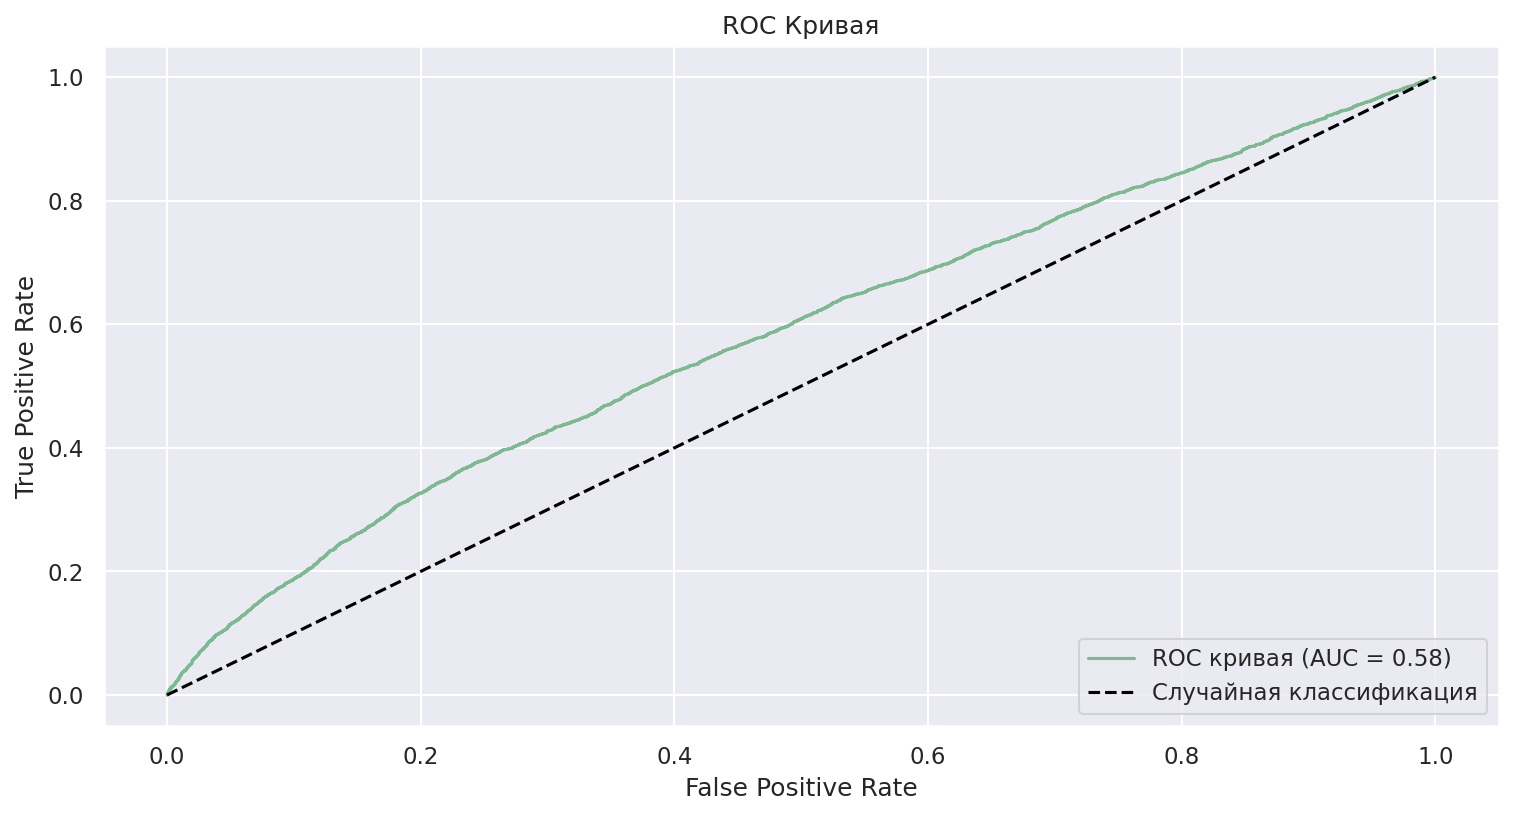

In [90]:
# вычисление значений для кривой ROC
fpr, tpr, thresholds = roc_curve(y_test, preds_proba)
auc = roc_auc_score(y_test, preds_proba)

# --- График ROC ---
plt.figure(figsize=(12, 6), dpi=PLOT_DPI)
plt.plot(fpr, tpr, label=f'ROC кривая (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случайная классификация')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Кривая')
plt.legend(loc='lower right')
plt.show()

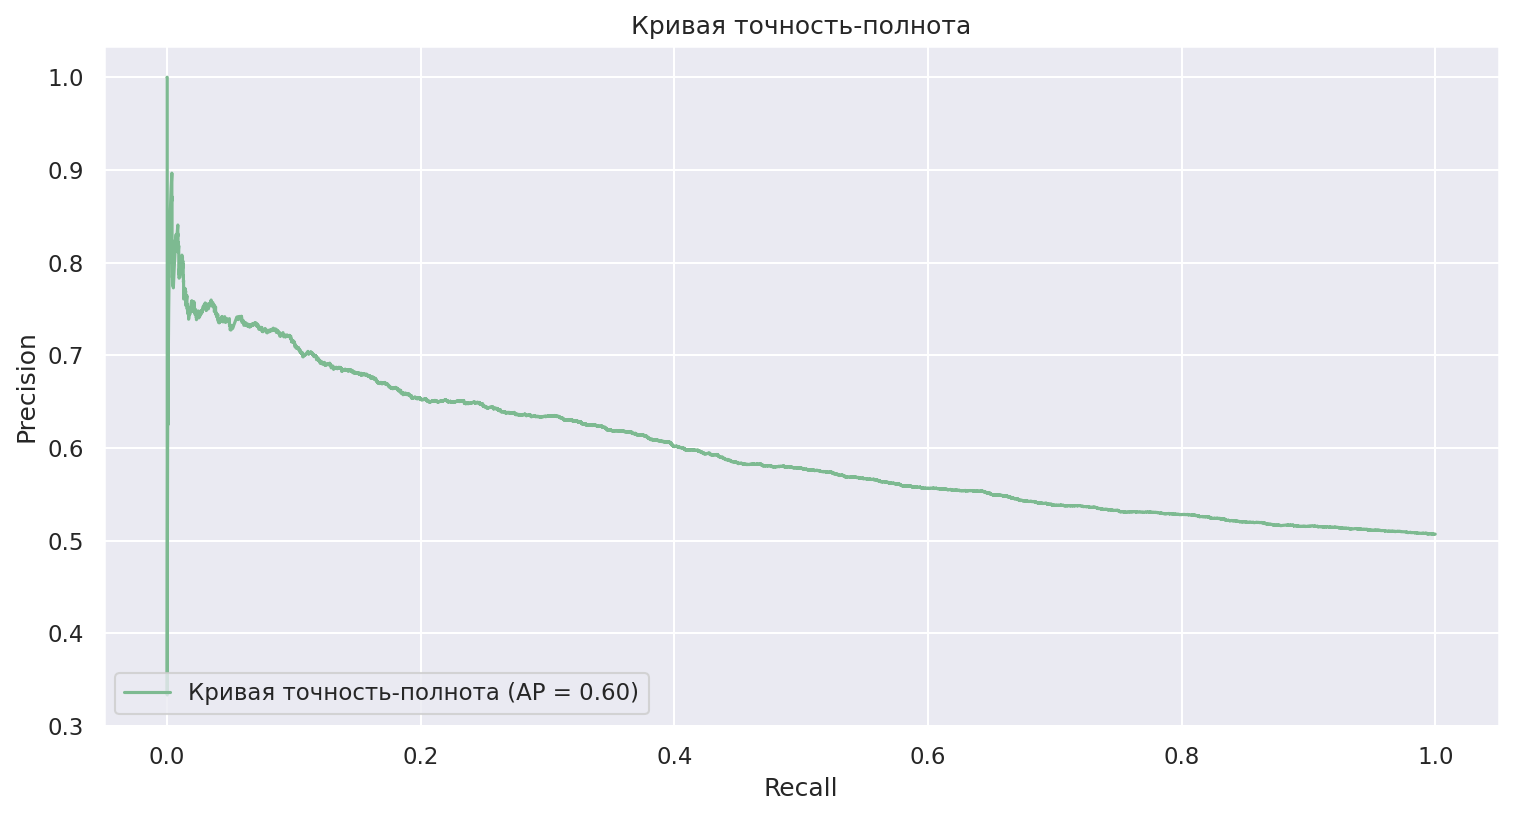

In [91]:
# вычисление значений для кривой точность-полнота
precision, recall, thresholds = precision_recall_curve(y_test, preds_proba)
ap = average_precision_score(y_test, preds_proba)

# --- График точность-полнота ---
plt.figure(figsize=(12, 6), dpi=PLOT_DPI)
plt.plot(recall, precision, label=f'Кривая точность-полнота (AP = {ap:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Кривая точность-полнота')
plt.legend(loc='lower left')
plt.show()

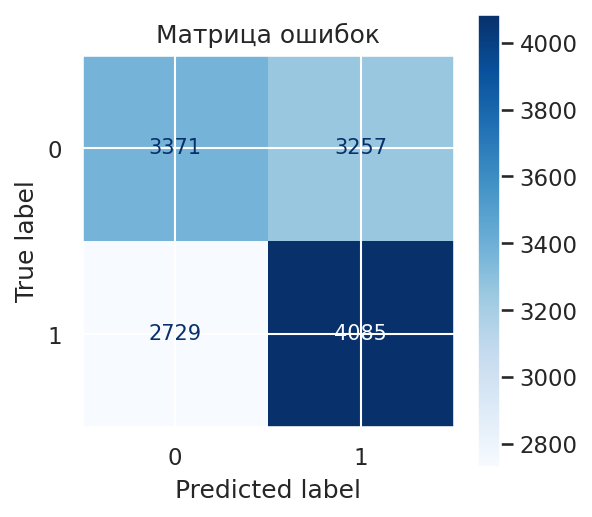

In [92]:
# матрица ошибок
cm = confusion_matrix(y_test, predict_threshold, labels=tuned_model_cat.classes_)

# --- График Матрица ошибок ---
fig, ax = plt.subplots(figsize=(4, 4), dpi=PLOT_DPI)
cmd = ConfusionMatrixDisplay(cm, display_labels=tuned_model_cat.classes_)
cmd.plot(ax=ax, cmap="Blues")
ax.set_title('Матрица ошибок')
plt.show()

<font size="3">
    
Можно отметить, что полученное значение **average_precision_score** в **0.69** означает, что модель довольно хорошо справляется с отличием рискованных поездок от безопасных.
    
При этом, в `confusion_matrix` отображается довольно высокое количество ложноположительных предсказаний: **FP = 3382**. Это говорит о том, что модель может слишком агрессивно классифицировать безопасные поездки как рискованные.
    
Модель правильно предсказала **3357** (TN) безопасных и **4840** (TP) рискованных поездок, но в **2023** (FN) случае модель ошиблась, приняв рискованную поездку за безопасную. 
    
В целом, сочетание `average_precision_score` = **0.69** и `roc_auc_score` = **0.66** - это приемлемый баланс, модель справляется с классификацией: достаточно точна в определении рискованных поездок и не пропускает много положительных случаев.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Матрица ошибок и метрики полноты-точности исследованы.

<div class="alert alert-block alert-danger">
<h2> Комментарий ментора <a class="tocSkip"></h2>

    
<b>На доработку❌:</b> Интерпретацию матрицы ошибок стоит расширить: каждую из четыёх метрик матрицы ошибок нужно описать, а значения интерпретировать на понятном бизнесу языке.

<div class="alert alert-info">
<h2> Комментарий студента <a class="tocSkip"> </h2>

📝 Дополнила вывод по матрице ошибок
    
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера v.2 <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Учтено.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

<font size="3">
    
**Вывод раздела:**

Исследование проводилось для каршеринговой компании с целью выбора модели МО, которая могла бы оценить риск ДТП по выбранному маршруту движения.

Под риском понимается вероятность ДТП с любым повреждением транспортного средства. Как только водитель забронировал автомобиль, сел за руль и выбрал маршрут, система должна оценить уровень риска. Если уровень риска высок, водитель увидит предупреждение и рекомендации по маршруту.
   
Оценивать качество работы моделей решено с помощью метрик `weighted_f1` и `accuracy`.
    
На основании вводных данных и полученных результатов исследования лучшей моделью для предсказания риска ДТП является `CatBoostClassifier()`. 
    
При уменьшении порога отсечения до 0.34 удалось достичь следующих значений метрик: 
- `Accuracy` в **0.614**;
- `Precision` для положительного класса в **0.581**;
- `Recall` для положительного класса в **0.806**.
    
Результат работы полученной модели можно считать удовлетворительным.

## Анализ важности факторов ДТП

<font size="3"> Для анализа важности признаков и визуализации данных используем библиотеку SHAP.

In [93]:
# создаём объясняющий объект explainer
explainer = shap.TreeExplainer(tuned_model_cat)

# получаем значения Шепли
shap_values = explainer(X_test)

<font size="3"> Для визуализации вклада признаков в предсказание модели построим `shap.summary_plot`:

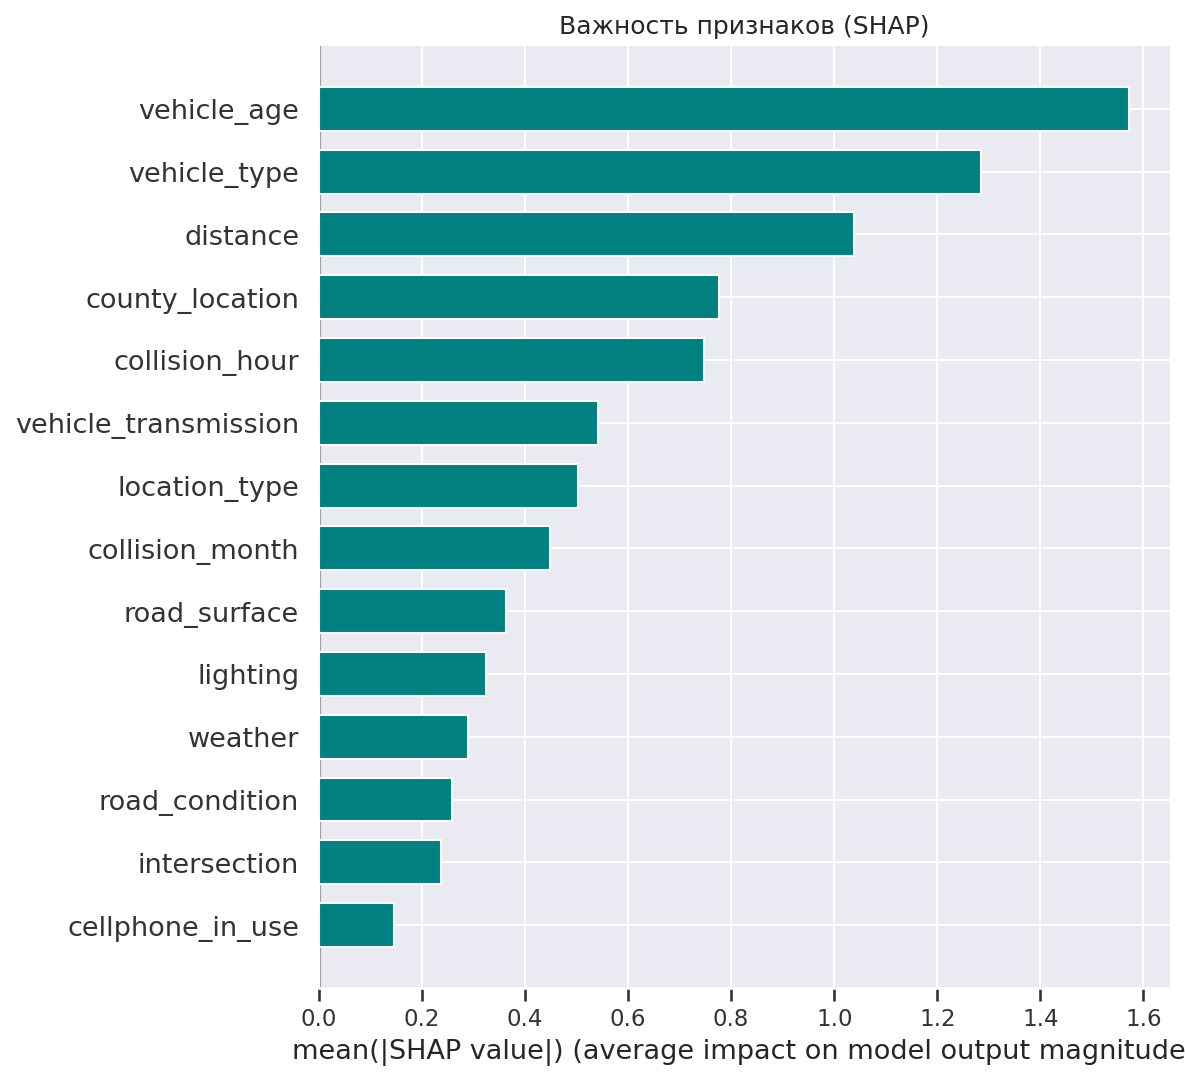

In [94]:
# визуализация значений Шепли
plt.figure(dpi=PLOT_DPI)
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, color='teal') 
plt.title('Важность признаков (SHAP)')
plt.show()

<font size="3">
    
Визуализация показывает, что наибольший вклад в предсказание положительного класса (1) целевого признака `at_fault` вносит признак `vehicle_age`.
    
Меньшее, но ощутимое влияние оказывают признаки `distance` и `vehicle_type`.
    
Остальные признаки также вносят свой вклад в предсказание, но их значимость оценивается моделью намного ниже.

Изучим зависимость вероятности стать виновником ДТП от возраста автомобиля:

at_fault,0,1
age_group,,
1) менее 3 лет,0.497,0.503
2) от 3 до 5 лет,0.416,0.584
3) от 5 до 10 лет,0.553,0.447
4) более 10 лет,0.526,0.474


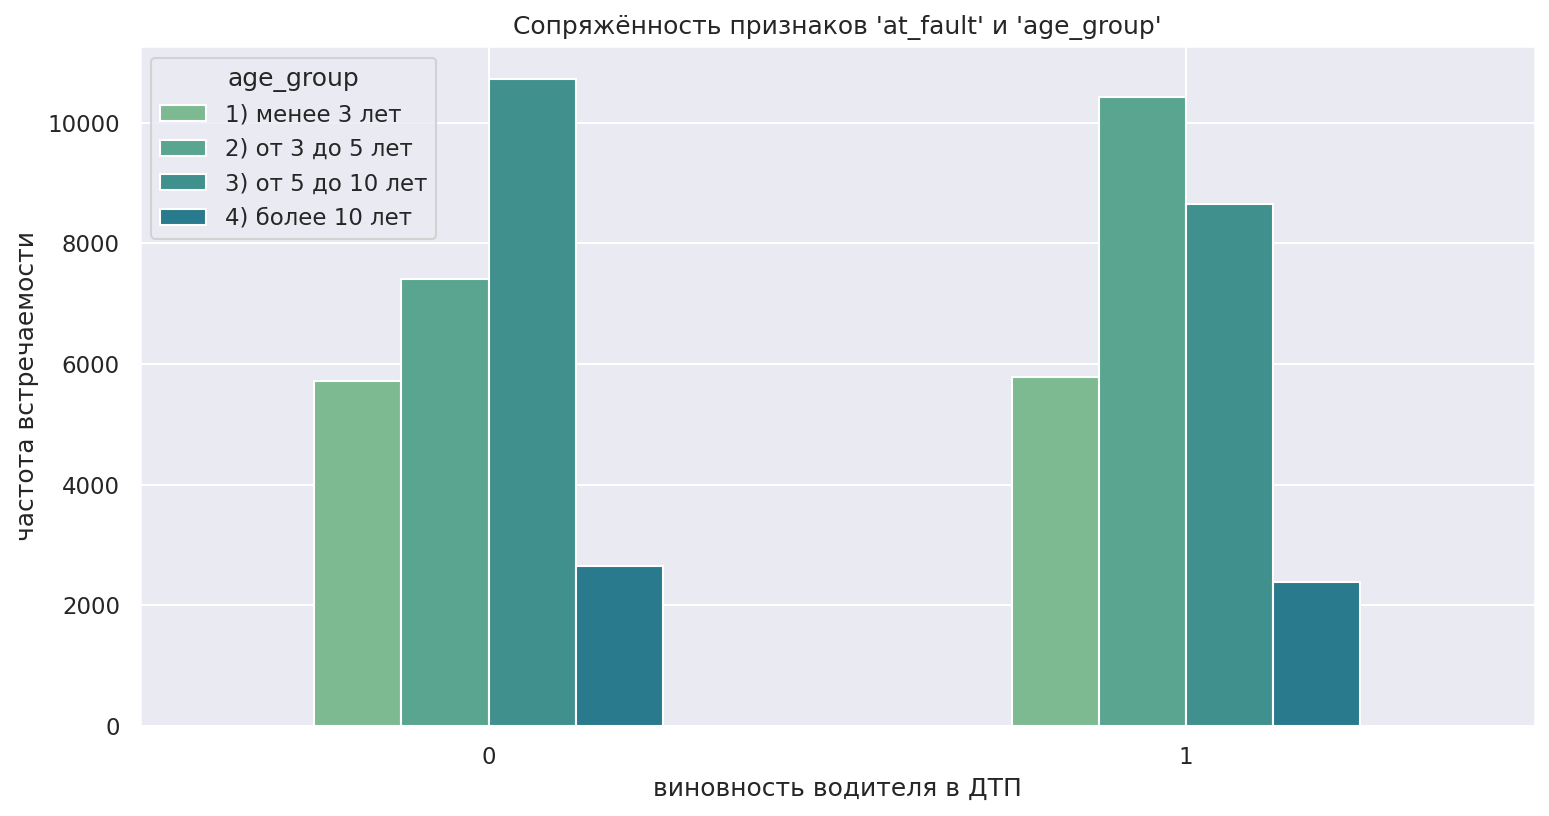

In [95]:
# функция для определения возрастной группы
def get_age_group(age):
    if age < 3:
        return '1) менее 3 лет'
    elif 3 <= age < 5:
        return '2) от 3 до 5 лет'
    elif 5 <= age < 10:
        return '3) от 5 до 10 лет'
    else:
        return '4) более 10 лет'

# применим функцию к столбцу 'vehicle_age' 
collisions['age_group'] = collisions['vehicle_age'].apply(get_age_group)

# сгруппируем данные по возрастной группе и посчитаем долю виновности для каждого класса
age_group_proportions = collisions.groupby('age_group')['at_fault'].value_counts(normalize=True)
age_group_proportions = age_group_proportions.unstack(fill_value=0)
display(age_group_proportions)

# построим график
fig, ax = plt.subplots(figsize=(12,6), dpi=PLOT_DPI)

pd.crosstab(
    collisions['at_fault'], 
    collisions['age_group']
).plot.bar(rot = 0, ax=ax)
    
plt.title("Сопряжённость признаков 'at_fault' и 'age_group'")
plt.xlabel("виновность водителя в ДТП")
plt.ylabel("частота встречаемости"); 

<div class="alert alert-success">
    
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Здорово, что используешь `SHAP` для анализа важности признаков.

<font size="3">

**Заключение:**

Визуализация показывает, что при употреблении водителем алкоголя вероятность наступления ДТП увеличивается. Чем выше уровень опьянения водителя, тем больше вероятность стать виновником происшествия.

**Рекомендации:**
    
Для снижения риска наступления ДТП по вине водителя стоит рассмотреть возможность внедрения следующих мер для распознования алкогольного опьянения пользователя каршеринговой компании:

- **Алкотестеры**: установка алкотестеров в автомобиле позволит проверить уровень опьянения водителя перед поездкой;
    
- **Блокировка ТС**: при выявлении превышения допустимой концентрации алкоголя необходимо предотвратить поездку через блокировку воможности движения автомобиля;

- **Видеонаблюдение**: установка камеры видеонаблюдения в салоне автомобиля поможет выявить признаки усталости или опьянения водителя.

Данный комплекс мер поможет снизить вероятность аварий арендованных автомобилей по вине опьянения водителей и повысить безопасность дорожного движения.

<div class="alert alert-success">
    
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Есть анализ важного признака и рекомендации по оснащению.

## Общий вывод

<font size="3">
    
Целью данного исследования являлась разработка модели МО, которая могла бы оценить риск ДТП по выбранному маршруту движения.
    
> **Отбор данных**

- исследована предоставленная заказчиком база данных ДТП;
- проведён статистический анализ факторов ДТП;
- подготовлен набор данных на основе первичного предположения заказчика;
- проведён отбор факторов, необходимых для модели 
  
    
> **Исследовательский анализ**
- выполнено статистическое исследование отобранных факторов;
- по итогам исследовательского анализа обработаны выбросы в данных;
- исследованы зависимости целевого признака от входных признаков
    
> **Подготовка данных для модели**
- подготвлены обучающая и тестовая выборки;
- определены списки с названиями признаков;
- данные были категоризированы и масштабированы
    
> **Выбор модели**

Написаны 3 типа моделей с перебором гиперпараметров:
  - LogisticRegression()
  - RandomForestClassifier()
  - CatBoostClassifier()

Для оценки качества модели выбраны метрики `weighted_f1` и `accuracy`. 
<br> Лучшие метрики на кросс-валидационных данных получены с помощью модели CatBoostClassifier():
- F1 ~ 0.68
- Accuracy ~ 0.68
<br> Решено использовать данную модель в дальнейшем исследовании.
    
> **Проверка качества модели на тестовых данных**  

Метрики качества модели на тестовых данных соответствуют метрикам, полученным на кросс-валидации, что говорит об отсутствии переобучения.
<br> Для увеличения `recall` положительного класса решено снизить порог отсечения до 0.34. 
<br> Удалось достичь следующих значений метрик:
- Accuracy в 0.602;
- Precision для положительного класса в 0.57;
- Recall для положительного класса в 0.812.
    
> **Анализ важности факторов ДТП** 
    
Визуализирован вклад признаков в предсказание модели, наибольший вклад в предсказание положительного класса (1) целевого признака `at_fault` вносит признак `vehicle_age`.

    
> **Рекомендации и риски**

Результат работы полученной в ходе исследования модели можно считать удовлетворительным. 
<br> Однако стоит отметить, что модель имеет свои недостатки: для повышения полноты охвата положительного класса был занижен порог отсечения, в результате чего модель совершает довольно много ложноположительных предсказаний. Ложные предупреждения могут раздражать пользователей сервиса и снижать доверие к системе, что со временем может привести к росту ДТП.
    
Для улучшения качества модели стоит обогатить имеющиеся данные: 
- получить характеристики водителя: учитывать возраст и стаж пользователя сервиса;
- добавить цель поездки и сделать обязательным ввод планируемого маршрута;
- собрать дополнительные данные: детали ДТП региона планируемых поездок, более свежие данные о ситуации на дорогах.

<div class="alert alert-success">
    
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Есть итоговый вывод - отлично!

<div style="border:solid Chocolate 2px; padding: 40px">

# Комментарий ревьюера: общий вывод по проекту.

Валерия, проект получился на довольно хорошем уровне - отличная работа над проектом, молодец!

Мне нравится твой аналитический подход к выполнению проекта, ты соблюдаешь структуру работы, выполняешь её последовательно - это очень хорошо! Шаги проекта выполнены по порядку согласно плану проекта, нет смысловых и структурных ям. Важно, что не забываешь про выводы.

Работа с моделями также выполнена отлично: исследовано несколько алгоритмов, проведён подбор гиперпараметров с помощью `Optuna`, выполнена промежуточная оценка моделей на кросс-валидации - молодец! Здорово, что используешь сочетание `ColumnTransformer` и `Pipeline` для соединения разных инструментов в единый модельный объект и настраиваешь бесперебойную работу энкодера в случае появления в данных новых, неизвестных на момент обучения значений признаков - так твоё решение будет более гибким и масштабируемым. 
    
Над проектом ещё стоит поработать - есть рекомендации по дополнению некоторых твоих шагов проекта. Такие рекомендации я отметил жёлтыми комментариями. Будет здорово, если ты учтёшь их - так проект станет структурно и содержательно более совершенным.
    
Также в работе есть критические замечания. К этим замечаниям я оставил пояснительные комментарии красного цвета, в которых перечислил возможные варианты дальнейших действий. Уверен, ты быстро с этим управишься:)
    
Если о том, что нужно сделать в рамках комментариев, будут возникать вопросы - оставь их, пожалуйста, в комментариях, и я отвечу на них во время следующего ревью.
    
Также буду рад ответить на любые твои вопросы по проекту или на какие-либо другие, если они у тебя имеются - оставь их в комментариях, и я постараюсь ответить:)
    
Жду твой проект на повторном ревью. До встречи:)

<div style="border:solid Chocolate 2px; padding: 40px">

# Комментарий ревьюера: итоговый вывод по проекту.

Валерия, все замечания учтены - проект принят!
    
Спасибо за хорошую работу над проектом, желаю успехов в дальнейшем обучении:)